<a href="https://colab.research.google.com/github/patriciasandagorda/AST/blob/main/AST_Script_TP2_Grupo2_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N° 2 — Análisis de Series Temporales

## Modelos de Machine Learning para el pronóstico de los ingresos diarios de taxis verdes y Uber en Williamsburg y Midtown Center, Nueva York

**Maestría en Ciencia de Datos — Universidad Austral**

Materia: Análisis de Series Temporales

— Docentes: Rodrigo Del Rosso, Sebastián Calcagno, Braian Drago

Integrantes del grupo:
- Cacabelos, Martín
- Maxwell, Julia
- Nuñez, Keiver
- Sandagorda, Patricia
- Tello, Carmen

---

## 1. Configuración del entorno

Esta sección detecta el entorno de ejecución (Colab o local), instala las dependencias que falten,
importa las librerías y define las rutas de trabajo.

In [3]:
# --- Detección de entorno y montaje de Google Drive ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    EN_COLAB = True
except Exception:
    EN_COLAB = False
    print('Entorno local detectado: se omite el montaje de Google Drive.')

Mounted at /content/drive


In [4]:
import sys
import subprocess
import importlib.util

PAQUETES = {
    'great_tables': 'great_tables',
    'pmdarima': 'pmdarima',
    'holidays': 'holidays',
    'arch': 'arch',
    'lightgbm': 'lightgbm',
    'xgboost': 'xgboost',
}

faltantes = [pip_name for pip_name, modulo in PAQUETES.items()
             if importlib.util.find_spec(modulo) is None]

if faltantes:
    print(f'Instalando: {", ".join(faltantes)}')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *faltantes], check=False)
else:
    print('Todas las dependencias ya están instaladas.')

Instalando: great_tables, pmdarima, arch


In [5]:
import hashlib
import itertools
import json
import pathlib
import pickle
import warnings
import urllib.request
import zipfile
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import holidays
from scipy.stats import boxcox
from great_tables import GT, style, loc, md

from statsmodels.tsa.stattools import adfuller, kpss, acovf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from arch.unitroot import PhillipsPerron
from pmdarima.arima.seasonality import OCSBTest, CHTest

from sklearn.metrics import mean_squared_error, mean_absolute_error

import lightgbm as lgb
import xgboost as xgb
import torch

warnings.filterwarnings('ignore', category=ConvergenceWarning)

PERIODO_ESTACIONAL = 7
VENTANA_MOVIL = 7

In [6]:

# --- Rutas de trabajo ---
COLAB_DIR = pathlib.Path('/content/drive/MyDrive/MCD/AST/Trabajo Final/Trabajo Final')
LOCAL_DIR = pathlib.Path('G:/Mi unidad/Maestría en Ciencia de Datos - Universidad Austral/Materias/15. Análisis de series temporales (jueves)/Trabajo Final')

DATA_DIR = (COLAB_DIR if EN_COLAB else LOCAL_DIR) / 'data'
RAW_DIR = DATA_DIR / 'raw'
CACHE_DIR = DATA_DIR / 'cache'

# Los directorios se crean ANTES de verificar los archivos que viven adentro.
for directorio in (DATA_DIR, RAW_DIR, CACHE_DIR):
    directorio.mkdir(parents=True, exist_ok=True)

ARCHIVOS = {
    'taxi_verde_williamsburg': [
        RAW_DIR / 'green_taxi_williamsburg_trips_24-25.csv',
        RAW_DIR / 'green_taxi_williamsburg_trips_25-26.csv',
    ],
    'uber_williamsburg': [
        RAW_DIR / 'uber_williamsburg_trips_24-25.csv',
        RAW_DIR / 'uber_williamsburg_trips_25-26.csv',
    ],
    'uber_midtown': [
        RAW_DIR / 'uber_midtown_center_trips_24-25.csv',
        RAW_DIR / 'uber_midtown_center_trips_25-26.csv',
    ],
}

print(f'Directorio de datos: {DATA_DIR}')
print('Archivos crudos:')
for nombre, rutas in ARCHIVOS.items():
    for ruta in rutas:
        estado = 'OK' if ruta.exists() else 'NO ENCONTRADO'
        print(f'  {nombre}: {ruta.name} [{estado}]')



Directorio de datos: /content/drive/MyDrive/MCD/AST/Trabajo Final/Trabajo Final/data
Archivos crudos:
  taxi_verde_williamsburg: green_taxi_williamsburg_trips_24-25.csv [OK]
  taxi_verde_williamsburg: green_taxi_williamsburg_trips_25-26.csv [OK]
  uber_williamsburg: uber_williamsburg_trips_24-25.csv [OK]
  uber_williamsburg: uber_williamsburg_trips_25-26.csv [OK]
  uber_midtown: uber_midtown_center_trips_24-25.csv [OK]
  uber_midtown: uber_midtown_center_trips_25-26.csv [OK]


In [69]:
"""
# Validación del entorno - Se fuerza el uso del almacenamiento local temporal
DATA_DIR = pathlib.Path('/content')
RAW_DIR = DATA_DIR
CACHE_DIR = DATA_DIR / 'cache'

# Asegurar existencia del directorio de caché local
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# URLs de GitHub (carpetas de raw y data)
GITHUB_RAW_BASE = "https://raw.githubusercontent.com/keivernunez/analisis_series_temporales_austral/main/TP2/raw/"
GITHUB_DATA_BASE = "https://raw.githubusercontent.com/keivernunez/analisis_series_temporales_austral/main/TP2/data/"

# Definir nombres de archivos esperados localmente (CSV)
NOMBRES_ARCHIVOS = {
    'taxi_verde_williamsburg': [
        'green_taxi_williamsburg_trips_24-25.csv',
        'green_taxi_williamsburg_trips_25-26.csv',
    ],
    'uber_williamsburg': [
        'uber_williamsburg_trips_24-25.csv',
        'uber_williamsburg_trips_25-26.csv',
    ],
    'uber_midtown': [
        'uber_midtown_center_trips_24-25.csv',
        'uber_midtown_center_trips_25-26.csv',
    ],
}

# Descarga y descompresión de archivos si no existen localmente
print('Verificando y descargando archivos desde GitHub:')
ARCHIVOS = {}
for nombre, archivos_lista in NOMBRES_ARCHIVOS.items():
    ARCHIVOS[nombre] = []
    for arch_nombre in archivos_lista:
        dest_path = RAW_DIR / arch_nombre
        ARCHIVOS[nombre].append(dest_path)

        if not dest_path.exists():
            # Intentar descargar directamente el .zip desde el repo
            zip_nombre = arch_nombre.replace('.csv', '.zip')
            url_zip = f"{GITHUB_RAW_BASE}{zip_nombre}"
            zip_dest_path = RAW_DIR / zip_nombre

            print(f'  Descargando y descomprimiendo {zip_nombre} desde GitHub...')
            try:
                urllib.request.urlretrieve(url_zip, zip_dest_path)
                with zipfile.ZipFile(zip_dest_path, 'r') as zip_ref:
                    zip_ref.extractall(RAW_DIR)
                print(f'    -> Extraído correctamente en {dest_path} [OK]')
                # Limpiar el archivo .zip descargado
                if zip_dest_path.exists():
                    os.remove(zip_dest_path)
            except Exception as e_zip:
                # Si falla el zip, intentar con el csv crudo directamente por si acaso
                print(f'    -> No se pudo procesar como .zip ({e_zip}). Intentando descargar .csv directo...')
                url_csv = f"{GITHUB_RAW_BASE}{arch_nombre}"
                try:
                    urllib.request.urlretrieve(url_csv, dest_path)
                    print(f'    -> Guardado directo {arch_nombre} [OK]')
                except Exception as e_csv:
                    print(f'    -> Error al descargar {arch_nombre}: {e_csv}')
        else:
            print(f'  {arch_nombre} ya existe localmente [OK]')

# Descarga de ingresos_diarios.csv de data si no existe localmente
RUTA_INGRESOS = DATA_DIR / 'ingresos_diarios.csv'
if not RUTA_INGRESOS.exists():
    url_ingresos = f"{GITHUB_DATA_BASE}ingresos_diarios.csv"
    print(f'\nDescargando ingresos_diarios.csv desde GitHub...')
    try:
        urllib.request.urlretrieve(url_ingresos, RUTA_INGRESOS)
        print(f'  -> Guardado en {RUTA_INGRESOS} [OK]')
    except Exception as e:
        print(f'  -> Error al descargar ingresos_diarios.csv: {e}')
else:
    print(f'\ningresos_diarios.csv ya existe localmente [OK]')

"""

'\n# Validación del entorno - Se fuerza el uso del almacenamiento local temporal\nDATA_DIR = pathlib.Path(\'/content\')\nRAW_DIR = DATA_DIR\nCACHE_DIR = DATA_DIR / \'cache\'\n\n# Asegurar existencia del directorio de caché local\nCACHE_DIR.mkdir(parents=True, exist_ok=True)\n\n# URLs de GitHub (carpetas de raw y data)\nGITHUB_RAW_BASE = "https://raw.githubusercontent.com/keivernunez/analisis_series_temporales_austral/main/TP2/raw/"\nGITHUB_DATA_BASE = "https://raw.githubusercontent.com/keivernunez/analisis_series_temporales_austral/main/TP2/data/"\n\n# Definir nombres de archivos esperados localmente (CSV)\nNOMBRES_ARCHIVOS = {\n    \'taxi_verde_williamsburg\': [\n        \'green_taxi_williamsburg_trips_24-25.csv\',\n        \'green_taxi_williamsburg_trips_25-26.csv\',\n    ],\n    \'uber_williamsburg\': [\n        \'uber_williamsburg_trips_24-25.csv\',\n        \'uber_williamsburg_trips_25-26.csv\',\n    ],\n    \'uber_midtown\': [\n        \'uber_midtown_center_trips_24-25.csv\',\n  

## 2. Construcción de la serie diaria de ingresos (01/06/2024 – 31/05/2026)

In [7]:
FECHA_INICIO = '2024-06-01'
FECHA_FIN = '2026-05-31'
RANGO_FECHAS = pd.date_range(FECHA_INICIO, FECHA_FIN, freq='D')

RUTA_INGRESOS = DATA_DIR / 'ingresos_diarios.csv'
FORZAR_RECALCULO = False  # cambiar a True si se modifican los CSV originales


def ingreso_diario(rutas_csv, columna_valor, columna_fecha='pickup_date', chunksize=250_000):
    """Agrega por día, en bloques, la columna monetaria indicada.

    Admite una ruta única o una lista de rutas (distintos vintages del mismo
    recorte geográfico), que se concatenan antes de reindexar contra el
    rango de fechas completo.
    """
    if isinstance(rutas_csv, (str, pathlib.Path)):
        rutas_csv = [rutas_csv]

    acumulado = pd.Series(0.0, index=RANGO_FECHAS)
    for ruta_csv in rutas_csv:
        lector = pd.read_csv(
            ruta_csv,
            usecols=[columna_fecha, columna_valor],
            parse_dates=[columna_fecha],
            chunksize=chunksize,
        )
        for bloque in lector:
            suma_bloque = bloque.groupby(columna_fecha)[columna_valor].sum()
            acumulado = acumulado.add(suma_bloque, fill_value=0.0)
    return acumulado.reindex(RANGO_FECHAS, fill_value=0.0)


if RUTA_INGRESOS.exists() and not FORZAR_RECALCULO:
    ingresos = pd.read_csv(RUTA_INGRESOS, index_col=0, parse_dates=True)
    print(f'Serie leída desde caché: {RUTA_INGRESOS.name}')
else:
    ingresos = pd.DataFrame({
        'taxi_verde_williamsburg': ingreso_diario(ARCHIVOS['taxi_verde_williamsburg'], 'total_amount'),
        'uber_williamsburg': ingreso_diario(ARCHIVOS['uber_williamsburg'], 'costo_total'),
        'uber_midtown': ingreso_diario(ARCHIVOS['uber_midtown'], 'costo_total'),
    })
    ingresos.index.name = 'fecha'
    ingresos.to_csv(RUTA_INGRESOS)
    print(f'Serie construida desde los CSV crudos y guardada en: {RUTA_INGRESOS.name}')

ingresos.index.name = 'fecha'

# `df` es la serie diaria en su escala original, con frecuencia diaria explícita.
df = ingresos.asfreq('D')

assert df.index.min() == pd.Timestamp(FECHA_INICIO) and df.index.max() == pd.Timestamp(FECHA_FIN), \
    'El rango de fechas cargado no coincide con el esperado (2024-06-01 a 2026-05-31).'

print(f'Serie diaria: {df.shape[0]} días, {df.shape[1]} series')
df.head()

Serie leída desde caché: ingresos_diarios.csv
Serie diaria: 730 días, 3 series


,taxi_verde_williamsburg,uber_williamsburg,uber_midtown
fecha,,,
2024-06-01,291.40,339938.85,162255.10
2024-06-02,480.02,254645.27,113694.65
2024-06-03,0.00,106596.77,280473.49
2024-06-04,72.30,105553.50,408520.92
2024-06-05,88.96,124873.13,477617.80


## 3. Configuración de las series

Todo el notebook se apoya en un único diccionario `SERIES`. Ahí se define, para cada serie, su
etiqueta para gráficos y tablas y la transformación de estabilización de varianza que se le aplica.
Los diccionarios auxiliares (`COLUMNAS_ORIGINALES`, `COLUMNAS_MODELO`) se derivan de él, de modo que
**las claves de las series nunca cambian a lo largo del notebook** y las celdas se pueden volver a
ejecutar en cualquier orden.

In [8]:
SERIES = {
    'taxi_verde_williamsburg': {
        'etiqueta': 'Taxi verde — Williamsburg',
        'transformacion': 'ninguna',
    },
    'uber_williamsburg': {
        'etiqueta': 'Uber — Williamsburg',
        'transformacion': 'ninguna',
    },
    'uber_midtown': {
        'etiqueta': 'Uber — Midtown Center',
        'transformacion': 'log1p',
    },
}

TRANSFORMACIONES = {
    'ninguna': (lambda x: x, lambda x: x),
    'log1p': (np.log1p, np.expm1),
    'sqrt': (np.sqrt, np.square),
}

SUFIJOS = {'ninguna': '', 'log1p': '_log1p', 'sqrt': '_sqrt'}


def columna_modelo(serie):
    """Nombre de la columna sobre la que efectivamente se modela la serie."""
    return f'{serie}{SUFIJOS[SERIES[serie]["transformacion"]]}'


def transformar(serie, valores):
    return TRANSFORMACIONES[SERIES[serie]['transformacion']][0](valores)


def destransformar(serie, valores):
    """Devuelve los valores a la escala original (ingresos en dólares)."""
    return TRANSFORMACIONES[SERIES[serie]['transformacion']][1](valores)


# Diccionarios derivados: {columna: etiqueta}
COLUMNAS_ORIGINALES = {serie: cfg['etiqueta'] for serie, cfg in SERIES.items()}
COLUMNAS_MODELO = {
    columna_modelo(serie): (cfg['etiqueta'] if cfg['transformacion'] == 'ninguna'
                            else f'{cfg["etiqueta"]} ({cfg["transformacion"]})')
    for serie, cfg in SERIES.items()
}

for serie, cfg in SERIES.items():
    print(f'{serie:28s} -> columna de modelado: {columna_modelo(serie):36s} '
          f'transformación: {cfg["transformacion"]}')

taxi_verde_williamsburg      -> columna de modelado: taxi_verde_williamsburg              transformación: ninguna
uber_williamsburg            -> columna de modelado: uber_williamsburg                    transformación: ninguna
uber_midtown                 -> columna de modelado: uber_midtown_log1p                   transformación: log1p


#### Gráfico 1. Evolución temporal, media móvil y varianza móvil (ventana de 7 días) de los ingresos diarios, 06/2024–05/2026

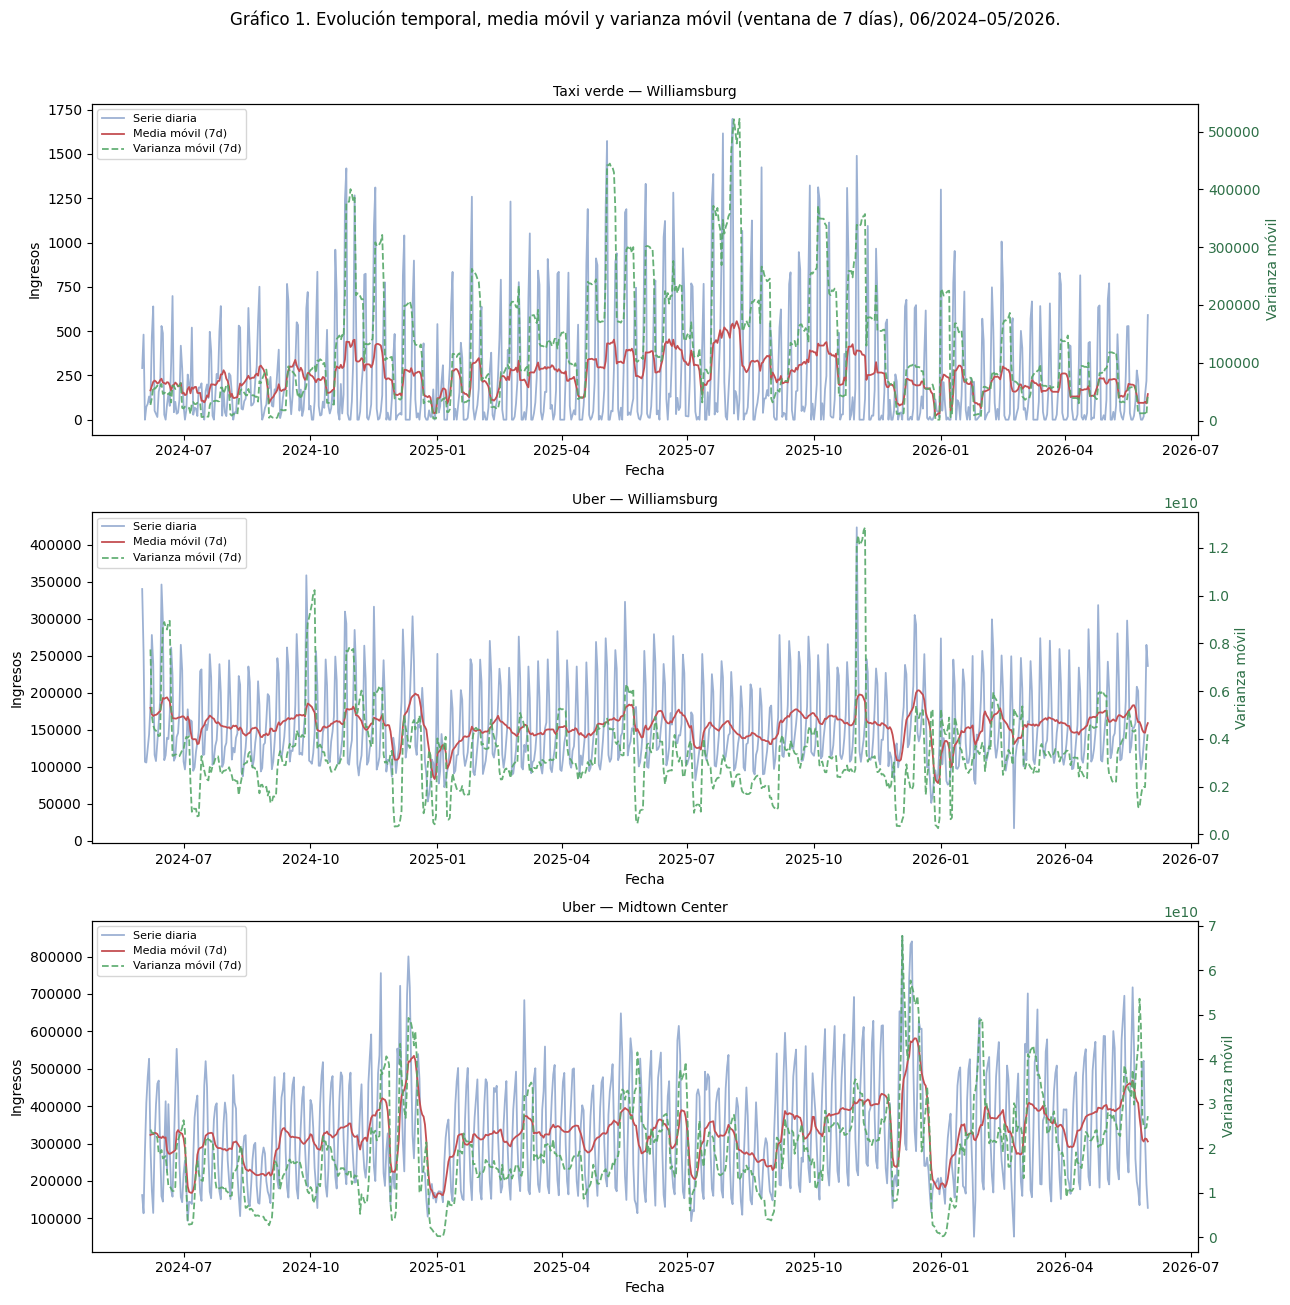

In [9]:
fig, axes = plt.subplots(nrows=len(COLUMNAS_ORIGINALES), ncols=1, figsize=(13, 13))

for ax1, (col, titulo) in zip(axes, COLUMNAS_ORIGINALES.items()):
    serie = df[col]
    media_movil = serie.rolling(VENTANA_MOVIL).mean()
    var_movil = serie.rolling(VENTANA_MOVIL).var()

    ax1.plot(serie.index, serie.values, lw=1.3, alpha=0.55, color='#4C72B0', label='Serie diaria')
    ax1.plot(serie.index, media_movil, lw=1.3, color='#C44E52', label=f'Media móvil ({VENTANA_MOVIL}d)')
    ax1.set_ylabel('Ingresos')
    ax1.set_xlabel('Fecha')

    ax2 = ax1.twinx()
    ax2.plot(serie.index, var_movil, lw=1.3, color='#55A868', alpha=0.9,
             linestyle='--', label=f'Varianza móvil ({VENTANA_MOVIL}d)')
    ax2.set_ylabel('Varianza móvil', color='#2E7047')
    ax2.tick_params(axis='y', labelcolor='#2E7047')

    lineas1, etiquetas1 = ax1.get_legend_handles_labels()
    lineas2, etiquetas2 = ax2.get_legend_handles_labels()
    ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc='upper left', fontsize=8)

    ax1.set_title(titulo, fontsize=10)

fig.suptitle('Gráfico 1. Evolución temporal, media móvil y varianza móvil (ventana de 7 días), 06/2024–05/2026.',
             fontsize=12, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## 4. Estabilización de la varianza

Se combinan dos diagnósticos sobre las series en su escala original: el método Rango-Mediana
(regresión de ln(Rango) sobre ln(Mediana), donde λ ≈ 1 − pendiente) y la estimación de λ por máxima
verosimilitud de Box-Cox con su intervalo de confianza al 95%.

In [10]:
def analyze_rango_mediana(series, window_size=VENTANA_MOVIL):
    """Divide la serie en subgrupos, calcula rango y mediana,
    y ajusta: ln(Rango) = a + b * ln(Mediana).

    Descarta los subgrupos con mediana o rango <= 0, que no admiten logaritmo.
    """
    n = len(series)
    num_groups = n // window_size
    medianas, rangos = [], []

    for i in range(num_groups):
        subgroup = series[i * window_size:(i + 1) * window_size]
        medianas.append(np.median(subgroup))
        rangos.append(np.max(subgroup) - np.min(subgroup))

    medianas, rangos = np.array(medianas), np.array(rangos)

    mask = (medianas > 0) & (rangos > 0)
    n_descartados = int((~mask).sum())
    if n_descartados > 0:
        print(f'  [aviso] se descartaron {n_descartados} de {len(medianas)} subgrupos por mediana o rango <= 0')
    medianas, rangos = medianas[mask], rangos[mask]

    log_medianas, log_rangos = np.log(medianas), np.log(rangos)
    slope, intercept = np.polyfit(log_medianas, log_rangos, 1)

    y_pred = slope * log_medianas + intercept
    r_squared = 1 - (np.sum((log_rangos - y_pred) ** 2) / np.sum((log_rangos - np.mean(log_rangos)) ** 2))

    return {
        'medianas': medianas, 'rangos': rangos, 'intercept': intercept,
        'slope': slope, 'r_squared': r_squared, 'lambda_empirico': 1 - slope,
    }


def calcular_shift(series, margen=1.0):
    """Corrimiento fijo y explícito para series con valores <= 0 (Box-Cox lo requiere)."""
    minimo = np.min(series)
    return (-minimo + margen) if minimo <= 0 else 0.0


def get_boxcox_ci(series, alpha=0.05):
    """Lambda óptimo por MLE y su IC al (1-alpha) usando scipy.stats.boxcox.

    Aplica el corrimiento automáticamente si la serie tiene valores <= 0. Ese
    corrimiento afecta el λ estimado, así que el resultado es orientativo para
    las series con ceros (taxi verde).
    """
    shift = calcular_shift(series)
    series_shifted = np.asarray(series, dtype=float) + shift

    _, l_opt, ci = boxcox(series_shifted, alpha=alpha)
    ci_lower, ci_upper = ci

    return l_opt, ci_lower, ci_upper, shift


filas = []
for col, titulo in COLUMNAS_ORIGINALES.items():
    serie_valores = df[col].dropna().values

    rm = analyze_rango_mediana(serie_valores)
    l_opt, ci_inf, ci_sup, shift = get_boxcox_ci(serie_valores)

    filas.append({
        'Serie': titulo,
        'Pendiente (b)': rm['slope'],
        'R² (Ajuste empírico)': rm['r_squared'],
        'Lambda Empírico (1-b)': rm['lambda_empirico'],
        'Lambda Óptimo (MLE)': l_opt,
        'IC 95% Inferior': ci_inf,
        'IC 95% Superior': ci_sup,
    })

tabla_varianza = pd.DataFrame(filas)

(
    GT(tabla_varianza)
    .tab_header(
        title=f'Tabla 1. Estabilización de varianza: Rango-Mediana (ventana={VENTANA_MOVIL}) vs. Box-Cox MLE'
    )
    .fmt_number(
        columns=['Pendiente (b)', 'R² (Ajuste empírico)', 'Lambda Empírico (1-b)',
                 'Lambda Óptimo (MLE)', 'IC 95% Inferior', 'IC 95% Superior'],
        decimals=3
    )
    .cols_label(**{
        'Pendiente (b)': md('Pendiente<br>(b)'),
        'R² (Ajuste empírico)': md('R²<br>(ajuste empírico)'),
        'Lambda Empírico (1-b)': md('λ empírico<br>(1-b)'),
        'Lambda Óptimo (MLE)': md('λ óptimo<br>(MLE)'),
        'IC 95% Inferior': md('IC 95%<br>inferior'),
        'IC 95% Superior': md('IC 95%<br>superior'),
    })
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
)

  [aviso] se descartaron 4 de 104 subgrupos por mediana o rango <= 0


GT(_tbl_data=                       Serie  Pendiente (b)  R² (Ajuste empírico)  \
0  Taxi verde — Williamsburg       0.091088              0.020613   
1        Uber — Williamsburg       0.356069              0.031158   
2      Uber — Midtown Center       1.399196              0.587331   

   Lambda Empírico (1-b)  Lambda Óptimo (MLE)  IC 95% Inferior  \
0               0.908912             0.159155         0.124715   
1               0.643931            -0.018086        -0.152673   
2              -0.399196             0.233993         0.084535   

   IC 95% Superior  
0         0.193847  
1         0.124927  
2         0.385616  , _body=<great_tables._gt_data.Body object at 0x7ac754055fd0>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Pendiente (b)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='Pendiente<br>(b)'), column_align='right', column_width=None), ColInfo(var='R² (Ajuste empírico)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='R²<br>(ajuste empírico)'), column_align='right', column_width=None), ColInfo(var='Lambda Empírico (1-b)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='λ empírico<br>(1-b)'), column_align='right', column_width=None), ColInfo(var='Lambda Óptimo (MLE)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='λ óptimo<br>(MLE)'), column_align='right', column_width=None), ColInfo(var='IC 95% Inferior', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='IC 95%<br>inferior'), column_align='right', column_width=None), ColInfo(var='IC 95% Superior', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='IC 95%<br>superior'), column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7ac754055940>, _spanners=Spanners([]), _heading=Heading(title='Tabla 1. Estabilización de varianza: Rango-Mediana (ventana=7) vs. Box-Cox MLE', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7ac7540563c0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7ac75688ec10>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=2, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7ac754056510>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7ac754056270>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInf

### Transformación aplicada

In [11]:
df_modelo = df.copy()

for serie, cfg in SERIES.items():
    if cfg['transformacion'] == 'ninguna':
        continue
    assert (df[serie].dropna() >= 0).all(), \
        f'Hay valores negativos en {serie}: no se puede aplicar {cfg["transformacion"]}'
    df_modelo[columna_modelo(serie)] = transformar(serie, df[serie])

# Verificación de que la inversa reconstruye la serie original
for serie in SERIES:
    reconstruida = destransformar(serie, df_modelo[columna_modelo(serie)])
    assert np.allclose(reconstruida.dropna(), df[serie].dropna()), \
        f'La transformación inversa de {serie} no reconstruye la serie original'

print('Columnas de modelado:', list(COLUMNAS_MODELO))
df_modelo[[columna_modelo(s) for s in SERIES]].head()

Columnas de modelado: ['taxi_verde_williamsburg', 'uber_williamsburg', 'uber_midtown_log1p']


,taxi_verde_williamsburg,uber_williamsburg,uber_midtown_log1p
fecha,,,
2024-06-01,291.40,339938.85,11.996931
2024-06-02,480.02,254645.27,11.641280
2024-06-03,0.00,106596.77,12.544238
2024-06-04,72.30,105553.50,12.920301
2024-06-05,88.96,124873.13,13.076568


## 5. Diagnóstico de estacionariedad

#### Tabla 2. Tests de raíz unitaria estacional (OCSB vs. Canova-Hansen)

In [12]:
filas = []
for col, titulo in COLUMNAS_MODELO.items():
    valores = df_modelo[col].dropna().values

    D_ocsb = OCSBTest(m=PERIODO_ESTACIONAL).estimate_seasonal_differencing_term(valores)
    D_ch = CHTest(m=PERIODO_ESTACIONAL).estimate_seasonal_differencing_term(valores)

    filas.append({'Serie': titulo, 'D (OCSB)': D_ocsb, 'D (Canova-Hansen)': D_ch})

tabla_estacional = pd.DataFrame(filas)

(
    GT(tabla_estacional)
    .tab_header(
        title='Tabla 2. Tests de raíz unitaria estacional (OCSB vs. Canova-Hansen)',
        subtitle=f'Orden de diferenciación estacional recomendado (m={PERIODO_ESTACIONAL})'
    )
    .cols_label(**{
        'D (OCSB)': md('D<br>(OCSB)'),
        'D (Canova-Hansen)': md('D<br>(Canova-Hansen)'),
    })
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
)

GT(_tbl_data=                           Serie  D (OCSB)  D (Canova-Hansen)
0      Taxi verde — Williamsburg         0                  0
1            Uber — Williamsburg         0                  0
2  Uber — Midtown Center (log1p)         0                  0, _body=<great_tables._gt_data.Body object at 0x7ac7ef336c40>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='D (OCSB)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='D<br>(OCSB)'), column_align='right', column_width=None), ColInfo(var='D (Canova-Hansen)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='D<br>(Canova-Hansen)'), column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7ac75688f750>, _spanners=Spanners([]), _heading=Heading(title='Tabla 2. Tests de raíz unitaria estacional (OCSB vs. Canova-Hansen)', subtitle='Orden de diferenciación estacional recomendado (m=7)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7ac75688fb10>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7ac753956fd0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=2, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7ac75688f610>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A

#### Tabla 3. Pruebas de raíz unitaria sobre las series en nivel (ADF vs. Phillips-Perron vs. KPSS)

Las tres pruebas se aplican sobre las series **en nivel** (sin diferenciar), con especificación `'c'`
(constante, sin tendencia). El objetivo es confirmar el orden de diferenciación regular *d*.

In [13]:
def pruebas_raiz_unitaria(serie, nombre, especificacion='c'):
    """Aplica las pruebas ADF, Phillips-Perron y KPSS a una serie.

    especificacion:
    - 'c': incluye constante.
    - 'ct': incluye constante y tendencia.
    """
    serie = serie.dropna()

    # statsmodels >= 0.15 avisa que va a cambiar el tipo de retorno de adfuller y kpss.
    # Se silencia solo ese aviso; las advertencias de interpolación del KPSS se conservan
    # porque informan que el p-valor está fuera de la tabla.
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', FutureWarning)
        adf = adfuller(serie, regression=especificacion, autolag='AIC')
        pp = PhillipsPerron(serie, trend=especificacion)
        kpss_resultado = kpss(serie, regression=especificacion, nlags='auto')

    return pd.DataFrame({
        'Serie': [nombre] * 3,
        'Prueba': ['ADF', 'Phillips-Perron', 'KPSS'],
        'Estadístico': [adf[0], pp.stat, kpss_resultado[0]],
        'p-valor': [adf[1], pp.pvalue, kpss_resultado[1]],
        'Rezagos': [adf[2], pp.lags, kpss_resultado[2]],
    })


tabla_raiz_unitaria = pd.concat(
    [pruebas_raiz_unitaria(df_modelo[col], titulo, especificacion='c')
     for col, titulo in COLUMNAS_MODELO.items()],
    ignore_index=True
)

(
    GT(tabla_raiz_unitaria)
    .tab_header(title='Tabla 3. Pruebas de raíz unitaria sobre las series en nivel (ADF vs. Phillips-Perron vs. KPSS)')
    .fmt_number(columns=['Estadístico', 'p-valor'], decimals=4)
    .tab_options(table_font_names='Arial')
)

/tmp/ipykernel_4231/1304824805.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_resultado = kpss(serie, regression=especificacion, nlags='auto')
/tmp/ipykernel_4231/1304824805.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_resultado = kpss(serie, regression=especificacion, nlags='auto')


GT(_tbl_data=                           Serie           Prueba  Estadístico       p-valor  \
0      Taxi verde — Williamsburg              ADF    -3.140587  2.369174e-02   
1      Taxi verde — Williamsburg  Phillips-Perron   -17.181302  6.644116e-30   
2      Taxi verde — Williamsburg             KPSS     0.145879  1.000000e-01   
3            Uber — Williamsburg              ADF    -4.712843  7.960016e-05   
4            Uber — Williamsburg  Phillips-Perron   -14.845177  1.811889e-27   
5            Uber — Williamsburg             KPSS     0.321584  1.000000e-01   
6  Uber — Midtown Center (log1p)              ADF    -4.557168  1.548024e-04   
7  Uber — Midtown Center (log1p)  Phillips-Perron   -10.875379  1.335824e-19   
8  Uber — Midtown Center (log1p)             KPSS     0.587412  2.378076e-02   

   Rezagos  
0       20  
1       20  
2      129  
3       20  
4       20  
5      574  
6       20  
7       20  
8       36  , _body=<great_tables._gt_data.Body object at 0x7ac7566dc160>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Prueba', type=<ColInfoTypeEnum.default: 1>, column_label='Prueba', column_align='left', column_width=None), ColInfo(var='Estadístico', type=<ColInfoTypeEnum.default: 1>, column_label='Estadístico', column_align='right', column_width=None), ColInfo(var='p-valor', type=<ColInfoTypeEnum.default: 1>, column_label='p-valor', column_align='right', column_width=None), ColInfo(var='Rezagos', type=<ColInfoTypeEnum.default: 1>, column_label='Rezagos', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7ac7566ec050>, _spanners=Spanners([]), _heading=Heading(title='Tabla 3. Pruebas de raíz unitaria sobre las series en nivel (ADF vs. Phillips-Perron vs. KPSS)', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7ac7539575c0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7ac7566e1eb0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7ac7566ec410>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7ac7566ec7d0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['Arial']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), tab

#### Gráfico 2. FAS, FAC y FACP de las series de modelado

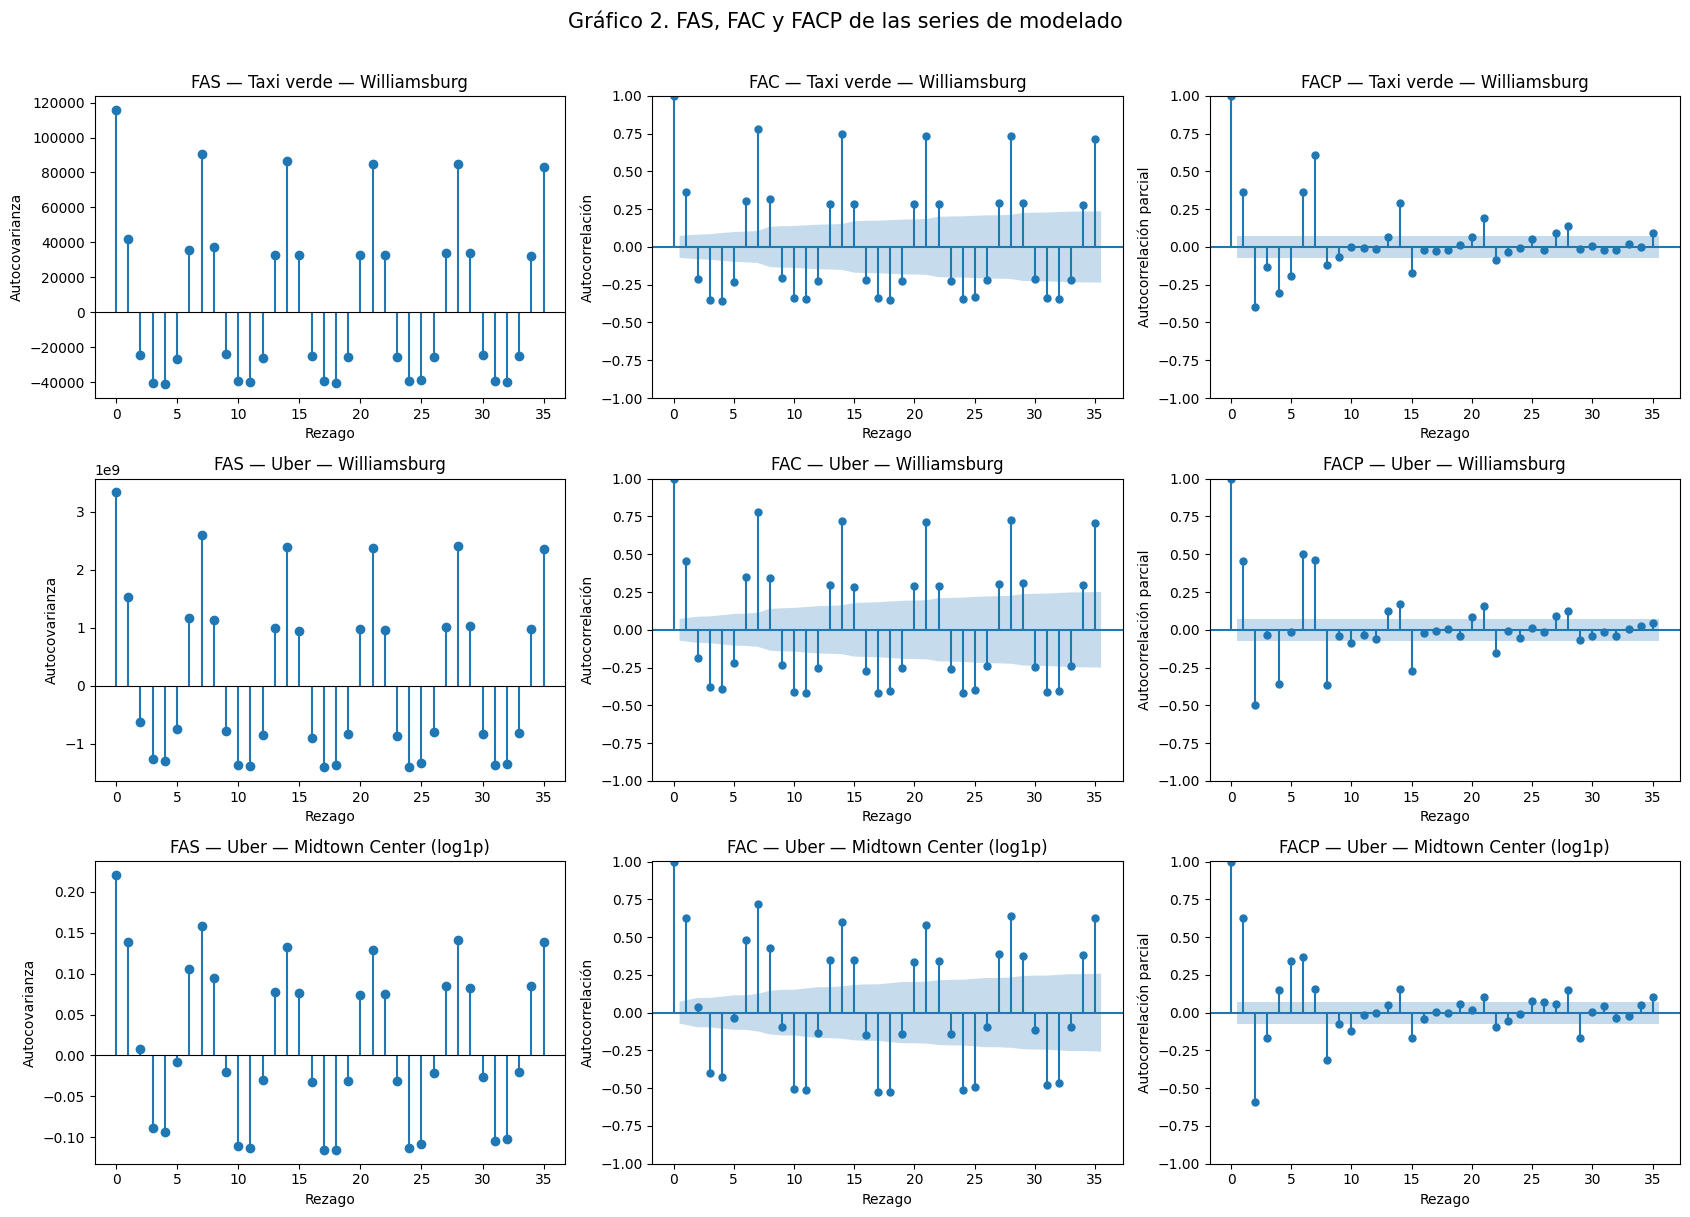

In [14]:
MAX_LAGS = 35


def graficar_dependencia_temporal(datos, columnas, titulo_general, max_lags=MAX_LAGS):
    """Grafica FAS, FAC y FACP (una fila por serie) para las columnas indicadas."""
    fig, axes = plt.subplots(nrows=len(columnas), ncols=3, figsize=(17, 4 * len(columnas)))

    for fila, (columna, titulo) in enumerate(columnas.items()):
        serie = datos[columna].dropna()

        # FAS (función de autocovarianza muestral)
        autocovarianzas = acovf(serie, adjusted=False, demean=True, fft=True, nlag=max_lags)
        axes[fila, 0].stem(range(len(autocovarianzas)), autocovarianzas, basefmt=' ')
        axes[fila, 0].axhline(0, color='black', linewidth=0.8)
        axes[fila, 0].set_title(f'FAS — {titulo}')
        axes[fila, 0].set_xlabel('Rezago')
        axes[fila, 0].set_ylabel('Autocovarianza')

        # FAC
        plot_acf(serie, lags=max_lags, alpha=0.05, zero=True, ax=axes[fila, 1])
        axes[fila, 1].set_title(f'FAC — {titulo}')
        axes[fila, 1].set_xlabel('Rezago')
        axes[fila, 1].set_ylabel('Autocorrelación')

        # FACP
        plot_pacf(serie, lags=max_lags, alpha=0.05, zero=True, method='ywm', ax=axes[fila, 2])
        axes[fila, 2].set_title(f'FACP — {titulo}')
        axes[fila, 2].set_xlabel('Rezago')
        axes[fila, 2].set_ylabel('Autocorrelación parcial')

    fig.suptitle(titulo_general, fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()


graficar_dependencia_temporal(
    datos=df_modelo,
    columnas=COLUMNAS_MODELO,
    titulo_general='Gráfico 2. FAS, FAC y FACP de las series de modelado',
)

## 6. Variables exógenas de calendario

Se construyen dos conjuntos de variables a partir del índice de fechas:

- **`exog_calendario`**: variables de calendario completas (día del mes, día de la semana, semana del
  año, mes, trimestre, año, feriado). Se usan como *features* para los modelos de Machine Learning,
  que pueden manejar relaciones no lineales entre esas variables y el target.
- **Bloques exógenos para SARIMAX**: solo el indicador de feriados y las dummies de año. El resto de
  las variables de calendario no se pasan a SARIMAX porque como enteros impondrían una relación
  lineal sin sentido (diciembre no es "doce veces" enero) y porque mes / trimestre / semana se
  solapan con la estacionalidad semanal que ya capturan los términos (P, D, Q, s=7).

Las dummies de año se construyen con `drop_first=True` para evitar colinealidad perfecta con la
constante del modelo: el año 2024 queda como categoría base.

In [15]:
ANIOS = range(df_modelo.index.year.min(), df_modelo.index.year.max() + 1)
feriados_us_ny = holidays.country_holidays('US', subdiv='NY', years=list(ANIOS))

exog_calendario = pd.DataFrame(index=df_modelo.index)
exog_calendario['dayofmonth'] = df_modelo.index.day
exog_calendario['dayofweek'] = df_modelo.index.dayofweek
exog_calendario['weekofyear'] = df_modelo.index.isocalendar().week.astype(int).values
exog_calendario['month'] = df_modelo.index.month
exog_calendario['quarter'] = df_modelo.index.quarter
exog_calendario['year'] = df_modelo.index.year
exog_calendario['holiday'] = [int(fecha in feriados_us_ny) for fecha in df_modelo.index.date]

# Dummies de año (2024 = categoría base)
dummies_anio = pd.get_dummies(df_modelo.index.year.astype(str), prefix='anio', drop_first=True).astype(int)
dummies_anio.index = df_modelo.index
COLS_ANIO = list(dummies_anio.columns)

# Tabla de exógenas disponible para SARIMAX
exog_sarimax = pd.concat([exog_calendario[['holiday']], dummies_anio], axis=1)

# Variantes que se comparan en el grid search
EXOG_VARIANTES = {
    'sin_exogenas': [],
    'feriados': ['holiday'],
    'anio': COLS_ANIO,
    'feriados_anio': ['holiday'] + COLS_ANIO,
}

print(f'Feriados US/NY en el período ({FECHA_INICIO} a {FECHA_FIN}): {exog_calendario["holiday"].sum()} días')
print(f'Dummies de año: {COLS_ANIO} (base: {min(ANIOS)})')
print(f'Variantes exógenas a comparar: {list(EXOG_VARIANTES)}')
exog_sarimax.head()

Feriados US/NY en el período (2024-06-01 a 2026-05-31): 28 días
Dummies de año: ['anio_2025', 'anio_2026'] (base: 2024)
Variantes exógenas a comparar: ['sin_exogenas', 'feriados', 'anio', 'feriados_anio']


,holiday,anio_2025,anio_2026
fecha,,,
2024-06-01,0,0,0
2024-06-02,0,0,0
2024-06-03,0,0,0
2024-06-04,0,0,0
2024-06-05,0,0,0


## 7. Variables autorregresivas (rezagos y estadísticos móviles)

Este bloque prepara la matriz de *features* para los modelos de Machine Learning. Los estadísticos
móviles se calculan sobre la serie desplazada un día, de modo que en *t* solo resuman información
hasta *t−1* (sin *leakage*).

In [16]:
LAGS = [1, 2, 7, 14, 21, 28, 30, 35]
VENTANAS_ROLLING = [7, 14, 28, 35]


def agregar_features_autorregresivas(serie, lags=LAGS, ventanas=VENTANAS_ROLLING):
    """Construye rezagos y estadísticos móviles (media, desvío) de `serie`."""
    feats = pd.DataFrame(index=serie.index)

    for lag in lags:
        feats[f'lag_{lag}'] = serie.shift(lag)

    serie_desplazada = serie.shift(1)
    for ventana in ventanas:
        rolling = serie_desplazada.rolling(ventana)
        feats[f'rolling_mean_{ventana}'] = rolling.mean()
        feats[f'rolling_std_{ventana}'] = rolling.std()

    return feats


features_por_serie = {}

for serie in SERIES:
    col = columna_modelo(serie)
    feats_autorregresivas = agregar_features_autorregresivas(df_modelo[col])
    features_completas = exog_calendario.join(feats_autorregresivas)
    features_completas['target'] = df_modelo[col]
    features_por_serie[serie] = features_completas

    n_features = features_completas.shape[1] - 1
    n_nan = features_completas.drop(columns='target').isna().any(axis=1).sum()
    print(f'{serie:28s}: {features_completas.shape[0]} filas, {n_features} features '
          f'(+ target) | filas con algún NaN: {n_nan}')

features_por_serie['uber_midtown'].dropna().head()

taxi_verde_williamsburg     : 730 filas, 23 features (+ target) | filas con algún NaN: 35
uber_williamsburg           : 730 filas, 23 features (+ target) | filas con algún NaN: 35
uber_midtown                : 730 filas, 23 features (+ target) | filas con algún NaN: 35


,dayofmonth,dayofweek,weekofyear,month,quarter,year,holiday,lag_1,lag_2,lag_7,...,lag_35,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_28,rolling_std_28,rolling_mean_35,rolling_std_35,target
fecha,,,,,,,,,,,,,,,,,,,,,
2024-07-06,6,5,27,7,3,2024,0,11.880252,11.447113,11.963767,...,11.996931,12.004201,0.326048,12.308611,0.507195,12.406047,0.485056,12.437309,0.497784,11.871217
2024-07-07,7,6,27,7,3,2024,0,11.871217,11.880252,11.872747,...,11.641280,11.990979,0.329815,12.293747,0.517379,12.398744,0.491707,12.433717,0.501495,11.838551
2024-07-08,8,0,28,7,3,2024,0,11.838551,11.871217,12.290677,...,12.544238,11.986094,0.332104,12.284399,0.524818,12.405530,0.482190,12.439353,0.493369,12.475636
2024-07-09,9,1,28,7,3,2024,0,12.475636,11.838551,12.446668,...,12.920301,12.012517,0.366003,12.274829,0.519628,12.400040,0.480419,12.437393,0.493076,12.819589
2024-07-10,10,2,28,7,3,2024,0,12.819589,12.475636,12.128184,...,13.076568,12.065791,0.455844,12.263699,0.504929,12.396863,0.477216,12.434516,0.490462,12.912920


## 8. Benchmark estadístico: SARIMAX

### 8.1. Partición train / test

La partición usa meses calendario completos: el test es el último mes de la serie (mayo de 2026) y el
train es todo lo anterior. La selección de hiperparámetros se hace **exclusivamente sobre train**
(por AIC / BIC); el test no interviene en ningún momento de esta etapa.

In [80]:
def dividir_train_test(serie):
    """Divide la serie en train / test usando meses calendario completos:
    - test: último mes calendario presente en la serie (mayo de 2026)
    - train: todo lo anterior a ese mes
    """
    serie = serie.dropna()
    periodos = serie.index.to_period('M')
    ultimo_mes = periodos.max()

    test = serie[periodos == ultimo_mes]
    train = serie[periodos < ultimo_mes]

    return train, test


splits = {}
for serie in SERIES:
    train, test = dividir_train_test(df_modelo[columna_modelo(serie)])
    splits[serie] = (train, test)
    print(f'{serie:28s}: train {train.index.min().date()} a {train.index.max().date()} '
          f'({len(train)} días) | test {test.index.min().date()} a {test.index.max().date()} '
          f'({len(test)} días)')

taxi_verde_williamsburg     : train 2024-06-01 a 2026-04-30 (699 días) | test 2026-05-01 a 2026-05-31 (31 días)
uber_williamsburg           : train 2024-06-01 a 2026-04-30 (699 días) | test 2026-05-01 a 2026-05-31 (31 días)
uber_midtown                : train 2024-06-01 a 2026-04-30 (699 días) | test 2026-05-01 a 2026-05-31 (31 días)


### 8.2. Espacio de búsqueda

Los rangos por serie salen del análisis del TP1 (FAC / FACP y resultados del grid search previo).
Se comparan dos familias:

- **SARIMAX**: usa los rangos estacionales (P, D, Q) de cada serie.
- **ARIMAX**: caso particular sin componente estacional (P = D = Q = 0).

Una aclaración importante sobre la comparabilidad del AIC: el criterio solo se puede comparar entre
modelos ajustados sobre **la misma variable dependiente y la misma muestra**. Por eso *d* y *D* se
fijan en 0 en todas las familias, incluida ARIMAX (en la versión anterior del script ARIMAX tenía
`d=(0, 1)`, lo que habría mezclado en un mismo ranking modelos sobre la serie en nivel y sobre la
serie diferenciada). Con d = D = 0, en cambio, el AIC **sí** es comparable entre variantes con y sin
exógenas, que es justamente lo que permite responder si conviene incorporarlas.

In [81]:
configuracion_series = {
    'taxi_verde_williamsburg': dict(p=(0, 3), d=(0, 0), q=(0, 2), P=(0, 2), D=(0, 0), Q=(0, 2)),
    'uber_williamsburg':       dict(p=(0, 3), d=(0, 0), q=(0, 2), P=(0, 2), D=(0, 0), Q=(0, 2)),
    'uber_midtown':            dict(p=(0, 3), d=(0, 0), q=(0, 2), P=(0, 2), D=(0, 0), Q=(0, 2)),
}

# SARIMAX toma los rangos estacionales de configuracion_series.
# ARIMAX los anula (P = D = Q = 0) y amplía p y q.
FAMILIAS = {
    'SARIMAX': None,
    'ARIMAX': dict(p=(0, 3), d=(0, 0), q=(0, 3), P=(0, 0), D=(0, 0), Q=(0, 0)),
}


def rangos_de(serie, familia):
    """Devuelve los rangos (p, d, q, P, D, Q) para una serie y una familia."""
    base = dict(configuracion_series[serie])
    override = FAMILIAS[familia]
    if override is not None:
        base.update(override)
    return base


for serie in SERIES:
    for familia in FAMILIAS:
        r = rangos_de(serie, familia)
        n_comb = int(np.prod([r[k][1] - r[k][0] + 1 for k in ('p', 'd', 'q', 'P', 'D', 'Q')]))
        print(f'{serie:28s} {familia:8s}: {n_comb:4d} combinaciones x {len(EXOG_VARIANTES)} variantes '
              f'exógenas = {n_comb * len(EXOG_VARIANTES):5d} ajustes')

taxi_verde_williamsburg      SARIMAX :  108 combinaciones x 4 variantes exógenas =   432 ajustes
taxi_verde_williamsburg      ARIMAX  :   16 combinaciones x 4 variantes exógenas =    64 ajustes
uber_williamsburg            SARIMAX :  108 combinaciones x 4 variantes exógenas =   432 ajustes
uber_williamsburg            ARIMAX  :   16 combinaciones x 4 variantes exógenas =    64 ajustes
uber_midtown                 SARIMAX :  108 combinaciones x 4 variantes exógenas =   432 ajustes
uber_midtown                 ARIMAX  :   16 combinaciones x 4 variantes exógenas =    64 ajustes


### 8.3. Grid search con caché

La búsqueda es exhaustiva sobre el producto cartesiano de los rangos. Para no tener que rehacer el
trabajo, los resultados se cachean en disco (Google Drive) con estas características:

- **Un archivo por combinación de (serie, familia, variante exógena)**, con un hash en el nombre que
  resume los rangos, el período estacional, las columnas exógenas y las fechas del train. Si cambiás
  cualquiera de esas cosas, el hash cambia y esa búsqueda se recalcula; el resto queda intacto.
- **Guardado incremental**: el caché se persiste cada `guardar_cada` modelos ajustados, no al final.
  Si se corta Colab a mitad de camino, al volver a ejecutar la celda se retoma exactamente donde
  quedó, ajustando solo las combinaciones pendientes.
- **Las combinaciones que fallan también se cachean**, con su estado de error, para no reintentarlas
  en cada corrida.
- `FORZAR_RECALCULO_GRID = True` ignora el caché y vuelve a ajustar todo desde cero.

In [82]:
CACHE_GRID_DIR = CACHE_DIR / 'gridsearch'
CACHE_GRID_DIR.mkdir(parents=True, exist_ok=True)

FORZAR_RECALCULO_GRID = False
VERSION_GRID = 'v1'  # cambiar si se modifica la lógica de ajuste (invalida todo el caché)


def _firma_busqueda(serie, familia, variante, rangos, s, y_train, cols_exog):
    """Diccionario que identifica unívocamente una búsqueda."""
    return {
        'version': VERSION_GRID,
        'serie': serie,
        'familia': familia,
        'variante': variante,
        'rangos': {k: list(v) for k, v in sorted(rangos.items())},
        's': s,
        'cols_exog': sorted(cols_exog),
        'n_train': int(len(y_train)),
        'train_inicio': str(y_train.index.min().date()),
        'train_fin': str(y_train.index.max().date()),
        'transformacion': SERIES[serie]['transformacion'],
    }


def _ruta_cache(firma):
    texto = json.dumps(firma, sort_keys=True, ensure_ascii=False)
    hash_corto = hashlib.md5(texto.encode('utf-8')).hexdigest()[:10]
    nombre = f'{firma["serie"]}__{firma["familia"]}__{firma["variante"]}__{hash_corto}.pkl'
    return CACHE_GRID_DIR / nombre


def _guardar_cache(ruta, contenido):
    """Escritura en archivo temporal + reemplazo, para no dejar un pickle a medio escribir
    si el entorno se corta justo durante el guardado."""
    ruta_tmp = ruta.with_suffix('.tmp')
    with open(ruta_tmp, 'wb') as f:
        pickle.dump(contenido, f)
    ruta_tmp.replace(ruta)


def grid_search_sarimax(serie, familia, variante, y_train, exog_train=None,
                        s=PERIODO_ESTACIONAL, criterio='AIC',
                        forzar=FORZAR_RECALCULO_GRID, guardar_cada=10, verbose=True):
    """Búsqueda exhaustiva de hiperparámetros SARIMAX por grid search, con caché en disco.

    Ajusta un modelo por cada combinación (p,d,q)(P,D,Q,s) de los rangos definidos para
    esa serie y familia, y lo evalúa por AIC / BIC sobre train. El test no interviene.

    Devuelve un DataFrame con los modelos que ajustaron correctamente, ordenado por `criterio`.
    """
    rangos = rangos_de(serie, familia)
    cols_exog = list(exog_train.columns) if exog_train is not None else []

    firma = _firma_busqueda(serie, familia, variante, rangos, s, y_train, cols_exog)
    ruta = _ruta_cache(firma)

    # --- Lectura del caché ---
    evaluados = {}
    if ruta.exists() and not forzar:
        with open(ruta, 'rb') as f:
            cache = pickle.load(f)
        if cache.get('firma') == firma:
            evaluados = cache['resultados']

    combinaciones = list(itertools.product(*[
        range(rangos[k][0], rangos[k][1] + 1) for k in ('p', 'd', 'q', 'P', 'D', 'Q')
    ]))
    pendientes = [c for c in combinaciones if c not in evaluados]

    if verbose:
        print(f'  {serie} | {familia} | {variante}: {len(combinaciones)} combinaciones '
              f'({len(evaluados)} en caché, {len(pendientes)} pendientes)')

    # --- Ajuste de las combinaciones pendientes ---
    for i, combo in enumerate(pendientes, start=1):
        pp, dd, qq, PP, DD, QQ = combo
        order = (pp, dd, qq)
        seasonal_order = (PP, DD, QQ, s)

        try:
            modelo = SARIMAX(
                y_train, exog=exog_train, order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False,
            )
            ajuste = modelo.fit(disp=False)
            evaluados[combo] = {
                'estado': 'ok',
                'order': order,
                'seasonal_order': seasonal_order,
                'AIC': float(ajuste.aic),
                'BIC': float(ajuste.bic),
                'LLF': float(ajuste.llf),
                'convergio': bool(ajuste.mle_retvals.get('converged', True)),
                'n_params': int(len(ajuste.params)),
            }
        except Exception as error:
            evaluados[combo] = {
                'estado': 'error',
                'order': order,
                'seasonal_order': seasonal_order,
                'mensaje': f'{type(error).__name__}: {error}',
            }

        if i % guardar_cada == 0 or i == len(pendientes):
            _guardar_cache(ruta, {'firma': firma, 'resultados': evaluados})
            if verbose:
                print(f'    {i}/{len(pendientes)} ajustadas (caché guardado)')

    # --- Armado del DataFrame de salida ---
    validos = [r for r in evaluados.values() if r['estado'] == 'ok']
    n_errores = len(evaluados) - len(validos)

    if verbose:
        print(f'    Completado: {len(validos)} modelos válidos, {n_errores} con error.')

    if not validos:
        return pd.DataFrame(columns=['order', 'seasonal_order', 'AIC', 'BIC', 'LLF',
                                     'convergio', 'n_params'])

    return (
        pd.DataFrame(validos)
        .drop(columns='estado')
        .sort_values(by=criterio)
        .reset_index(drop=True)
    )

### 8.4. Ejecución de la búsqueda

Se recorren las tres series, las dos familias y las cuatro variantes exógenas
(`sin_exogenas`, `feriados`, `anio`, `feriados_anio`). La primera corrida completa es larga; las
siguientes se resuelven casi por completo desde el caché.

In [83]:
# ── Diagnóstico del caché del grid search ────────────────────────────────────
import os

print('EN_COLAB          :', EN_COLAB)
print('DATA_DIR          :', DATA_DIR.resolve())
print('CACHE_GRID_DIR    :', CACHE_GRID_DIR.resolve())
print('¿existe?          :', CACHE_GRID_DIR.exists())
print('¿está en Drive?   :', str(CACHE_GRID_DIR.resolve()).startswith('/content/drive'))

archivos = sorted(CACHE_GRID_DIR.glob('*'))
print(f'\nArchivos en el caché ({len(archivos)}):')
for p in archivos[:10]:
    print(f'   {p.name}  ({p.stat().st_size:,} bytes)')

# Prueba de escritura, renombrado y lectura en ese directorio
prueba = CACHE_GRID_DIR / '_prueba.pkl'
prueba_tmp = prueba.with_suffix('.tmp')
try:
    with open(prueba_tmp, 'wb') as f:
        pickle.dump({'ok': True}, f)
        f.flush()
        os.fsync(f.fileno())
    print('\n✓ Escritura de archivo temporal: OK')
    try:
        prueba_tmp.replace(prueba)
        print('✓ Renombrado (os.replace): OK')
        with open(prueba, 'rb') as f:
            pickle.load(f)
        print('✓ Lectura posterior: OK')
        prueba.unlink()
    except Exception as e:
        print(f'✗ Renombrado FALLA: {type(e).__name__}: {e}')
        print('  → es la causa: el montaje de Drive no soporta os.replace()')
        prueba_tmp.unlink(missing_ok=True)
except Exception as e:
    print(f'✗ Escritura FALLA: {type(e).__name__}: {e}')

EN_COLAB          : True
DATA_DIR          : /content/drive/.shortcut-targets-by-id/1CRY726v1GfPqFHWfafeU9fVPw4mhyb38/Trabajo Final/data
CACHE_GRID_DIR    : /content/drive/.shortcut-targets-by-id/1CRY726v1GfPqFHWfafeU9fVPw4mhyb38/Trabajo Final/data/cache/gridsearch
¿existe?          : True
¿está en Drive?   : True

Archivos en el caché (24):
   taxi_verde_williamsburg__ARIMAX__anio__2dc3a1c433.pkl  (1,793 bytes)
   taxi_verde_williamsburg__ARIMAX__feriados__71b49edfcf.pkl  (1,782 bytes)
   taxi_verde_williamsburg__ARIMAX__feriados_anio__acbb2c5c5b.pkl  (1,812 bytes)
   taxi_verde_williamsburg__ARIMAX__sin_exogenas__6c97d4f0b1.pkl  (1,775 bytes)
   taxi_verde_williamsburg__SARIMAX__anio__6adbbd6bd5.pkl  (9,706 bytes)
   taxi_verde_williamsburg__SARIMAX__feriados__6f84812e8a.pkl  (9,695 bytes)
   taxi_verde_williamsburg__SARIMAX__feriados_anio__7034870990.pkl  (9,725 bytes)
   taxi_verde_williamsburg__SARIMAX__sin_exogenas__5b41db6fb6.pkl  (9,688 bytes)
   uber_midtown__ARIMAX__anio__9a6

In [84]:
resultados_grid = {}   # (serie, familia, variante) -> DataFrame completo, ordenado por AIC
mejores = []           # una fila por combinación, con el mejor modelo de cada búsqueda

for serie in SERIES:
    y_train, _ = splits[serie]

    for familia in FAMILIAS:
        for variante, cols in EXOG_VARIANTES.items():
            exog_train = (exog_sarimax.loc[y_train.index, cols].astype(float)
                          if cols else None)

            res = grid_search_sarimax(
                serie=serie, familia=familia, variante=variante,
                y_train=y_train, exog_train=exog_train,
            )
            resultados_grid[(serie, familia, variante)] = res

            if not res.empty:
                mejor = res.iloc[0]
                mejores.append({
                    'serie': serie,
                    'Serie': SERIES[serie]['etiqueta'],
                    'Familia': familia,
                    'Variante exógena': variante,
                    'k exógenas': len(cols),
                    'order': str(mejor['order']),
                    'seasonal_order': str(mejor['seasonal_order']),
                    'AIC': mejor['AIC'],
                    'BIC': mejor['BIC'],
                    # se conservan las tuplas para poder reconstruir el modelo más adelante
                    'order_t': mejor['order'],
                    'seasonal_order_t': mejor['seasonal_order'],
                })

tabla_mejores = pd.DataFrame(mejores)
print(f'\nBúsquedas completadas: {len(resultados_grid)}')
tabla_mejores.drop(columns=['serie', 'order_t', 'seasonal_order_t'])

  taxi_verde_williamsburg | SARIMAX | sin_exogenas: 108 combinaciones (108 en caché, 0 pendientes)
    Completado: 108 modelos válidos, 0 con error.
  taxi_verde_williamsburg | SARIMAX | feriados: 108 combinaciones (108 en caché, 0 pendientes)
    Completado: 108 modelos válidos, 0 con error.
  taxi_verde_williamsburg | SARIMAX | anio: 108 combinaciones (108 en caché, 0 pendientes)
    Completado: 108 modelos válidos, 0 con error.
  taxi_verde_williamsburg | SARIMAX | feriados_anio: 108 combinaciones (108 en caché, 0 pendientes)
    Completado: 108 modelos válidos, 0 con error.
  taxi_verde_williamsburg | ARIMAX | sin_exogenas: 16 combinaciones (16 en caché, 0 pendientes)
    Completado: 16 modelos válidos, 0 con error.
  taxi_verde_williamsburg | ARIMAX | feriados: 16 combinaciones (16 en caché, 0 pendientes)
    Completado: 16 modelos válidos, 0 con error.
  taxi_verde_williamsburg | ARIMAX | anio: 16 combinaciones (16 en caché, 0 pendientes)
    Completado: 16 modelos válidos, 0 con

,Serie,Familia,Variante exógena,k exógenas,order,seasonal_order,AIC,BIC
0,Taxi verde — Williamsburg,SARIMAX,sin_exogenas,0,"(0, 0, 2)","(1, 0, 2, 7)",9015.316390,9042.466568
1,Taxi verde — Williamsburg,SARIMAX,feriados,1,"(0, 0, 2)","(1, 0, 2, 7)",9012.292093,9043.967300
2,Taxi verde — Williamsburg,SARIMAX,anio,2,"(1, 0, 2)","(1, 0, 2, 7)",9039.203053,9079.928320
3,Taxi verde — Williamsburg,SARIMAX,feriados_anio,3,"(0, 0, 1)","(1, 0, 2, 7)",9025.757658,9061.969617
4,Taxi verde — Williamsburg,ARIMAX,sin_exogenas,0,"(3, 0, 3)","(0, 0, 0, 7)",9630.515892,9662.323275
5,Taxi verde — Williamsburg,ARIMAX,feriados,1,"(3, 0, 3)","(0, 0, 0, 7)",9788.382052,9824.733346
6,Taxi verde — Williamsburg,ARIMAX,anio,2,"(3, 0, 3)","(0, 0, 0, 7)",9712.847731,9753.742938
7,Taxi verde — Williamsburg,ARIMAX,feriados_anio,3,"(3, 0, 3)","(0, 0, 0, 7)",9714.346557,9759.785676
8,Uber — Williamsburg,SARIMAX,sin_exogenas,0,"(3, 0, 2)","(2, 0, 2, 7)",16133.597835,16178.848131
9,Uber — Williamsburg,SARIMAX,feriados,1,"(3, 0, 2)","(2, 0, 2, 7)",16486.127129,16535.902456


### 8.5. ¿Conviene incorporar las variables exógenas?

La comparación se hace dentro de cada par (serie, familia): se toma el mejor modelo sin exógenas
como referencia y se calcula el ΔAIC de cada variante contra él. Un ΔAIC **negativo** indica que
la variante con exógenas mejora el ajuste.

Como criterio de lectura habitual, una diferencia de menos de 2 puntos de AIC se considera evidencia
débil (los modelos son prácticamente equivalentes y conviene quedarse con el más parsimonioso, o sea
el que no incorpora exógenas); entre 2 y 10 puntos, evidencia moderada; más de 10 puntos, evidencia
fuerte a favor del modelo con menor AIC.

In [85]:
tabla_comparacion = tabla_mejores.copy()

# Referencia: el mejor modelo sin exógenas de cada par (serie, familia)
referencia = (
    tabla_comparacion[tabla_comparacion['Variante exógena'] == 'sin_exogenas']
    .set_index(['serie', 'Familia'])[['AIC', 'BIC']]
    .rename(columns={'AIC': 'AIC_ref', 'BIC': 'BIC_ref'})
)

tabla_comparacion = tabla_comparacion.join(referencia, on=['serie', 'Familia'])
tabla_comparacion['Δ AIC'] = tabla_comparacion['AIC'] - tabla_comparacion['AIC_ref']
tabla_comparacion['Δ BIC'] = tabla_comparacion['BIC'] - tabla_comparacion['BIC_ref']


def leer_delta(delta):
    """Lectura del ΔAIC respecto del mejor modelo sin exógenas."""
    if delta <= -10:
        return 'Mejora fuerte'
    if delta <= -2:
        return 'Mejora moderada'
    if delta < 2:
        return 'Equivalente (elegir el más parsimonioso)'
    if delta < 10:
        return 'Empeora levemente'
    return 'Empeora'


tabla_comparacion['Evidencia'] = tabla_comparacion['Δ AIC'].apply(leer_delta)
tabla_comparacion.loc[tabla_comparacion['Variante exógena'] == 'sin_exogenas', 'Evidencia'] = '— (referencia)'

tabla_comparacion = (
    tabla_comparacion
    .sort_values(['Serie', 'Familia', 'AIC'])
    .drop(columns=['serie', 'AIC_ref', 'BIC_ref', 'order_t', 'seasonal_order_t'])
    .reset_index(drop=True)
)

(
    GT(tabla_comparacion, groupname_col='Serie')
    .tab_header(
        title='Tabla 4. Grid search SARIMAX / ARIMAX: comparación de variantes exógenas',
        subtitle='Mejor modelo por variante (AIC sobre train). Δ calculado contra el mejor modelo sin exógenas de cada familia.'
    )
    .fmt_number(columns=['AIC', 'BIC', 'Δ AIC', 'Δ BIC'], decimals=2)
    .cols_label(**{
        'Variante exógena': md('Variante<br>exógena'),
        'k exógenas': md('k<br>exógenas'),
        'order': md('(p,d,q)'),
        'seasonal_order': md('(P,D,Q,s)'),
    })
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Familia'))
)

GT(_tbl_data=                        Serie  Familia Variante exógena  k exógenas  \
0   Taxi verde — Williamsburg   ARIMAX     sin_exogenas           0   
1   Taxi verde — Williamsburg   ARIMAX             anio           2   
2   Taxi verde — Williamsburg   ARIMAX    feriados_anio           3   
3   Taxi verde — Williamsburg   ARIMAX         feriados           1   
4   Taxi verde — Williamsburg  SARIMAX         feriados           1   
5   Taxi verde — Williamsburg  SARIMAX     sin_exogenas           0   
6   Taxi verde — Williamsburg  SARIMAX    feriados_anio           3   
7   Taxi verde — Williamsburg  SARIMAX             anio           2   
8       Uber — Midtown Center   ARIMAX     sin_exogenas           0   
9       Uber — Midtown Center   ARIMAX             anio           2   
10      Uber — Midtown Center   ARIMAX         feriados           1   
11      Uber — Midtown Center   ARIMAX    feriados_anio           3   
12      Uber — Midtown Center  SARIMAX         feriados           1   
13      Uber — Midtown Center  SARIMAX     sin_exogenas           0   
14      Uber — Midtown Center  SARIMAX    feriados_anio           3   
15      Uber — Midtown Center  SARIMAX             anio           2   
16        Uber — Williamsburg   ARIMAX     sin_exogenas           0   
17        Uber — Williamsburg   ARIMAX             anio           2   
18        Uber — Williamsburg   ARIMAX    feriados_anio           3   
19        Uber — Williamsburg   ARIMAX         feriados           1   
20        Uber — Williamsburg  SARIMAX     sin_exogenas           0   
21        Uber — Williamsburg  SARIMAX             anio           2   
22        Uber — Williamsburg  SARIMAX    feriados_anio           3   
23        Uber — Williamsburg  SARIMAX         feriados           1   

        order seasonal_order           AIC           BIC       Δ AIC  \
0   (3, 0, 3)   (0, 0, 0, 7)   9630.515892   9662.323275    0.000000   
1   (3, 0, 3)   (0, 0, 0, 7)   9712.847731   9753.742938   82.331839   
2   (3, 0, 3)   (0, 0, 0, 7)   9714.346557   9759.785676   83.830665   
3   (3, 0, 3)   (0, 0, 0, 7)   9788.382052   9824.733346  157.866159   
4   (0, 0, 2)   (1, 0, 2, 7)   9012.292093   9043.967300   -3.024297   
5   (0, 0, 2)   (1, 0, 2, 7)   9015.316390   9042.466568    0.000000   
6   (0, 0, 1)   (1, 0, 2, 7)   9025.757658   9061.969617   10.441268   
7   (1, 0, 2)   (1, 0, 2, 7)   9039.203053   9079.928320   23.886663   
8   (3, 0, 3)   (0, 0, 0, 7)     20.970056     52.777439    0.000000   
9   (1, 0, 3)   (0, 0, 0, 7)    390.910185    422.717568  369.940129   
10  (3, 0, 1)   (0, 0, 0, 7)    443.631794    470.903892  422.661739   
11  (1, 0, 2)   (0, 0, 0, 7)    597.103848    628.921295  576.133792   
12  (1, 0, 0)   (2, 0, 2, 7)   -288.711439   -257.015734  -80.583753   
13  (3, 0, 2)   (1, 0, 2, 7)   -208.127686   -167.402419    0.000000   
14  (0, 0, 2)   (2, 0, 2, 7)   -191.463977   -146.213681   16.663709   
15  (1, 0, 0)   (1, 0, 1, 7)   -118.808199    -91.579360   89.319487   
16  (3, 0, 3)   (0, 0, 0, 7)  16764.656861  16796.464244    0.000000   
17  (3, 0, 3)   (0, 0, 0, 7)  16792.710420  16833.605627   28.053559   
18  (3, 0, 3)   (0, 0, 0, 7)  16810.711714  16856.150832   46.054853   
19  (3, 0, 3)   (0, 0, 0, 7)  17046.737122  17083.088416  282.080261   
20  (3, 0, 2)   (2, 0, 2, 7)  16133.597835  16178.848131    0.000000   
21  (3, 0, 2)   (2, 0, 2, 7)  16155.085318  16209.385674   21.487484   
22  (3, 0, 2)   (2, 0, 2, 7)  16170.232394  16229.057779   36.634559   
23  (3, 0, 2)   (2, 0, 2, 7)  16486.127129  16535.902456  352.529295   

         Δ BIC        Evidencia  
0     0.000000   — (referencia)  
1    91.419663          Empeora  
2    97.462401          Empeora  
3   162.410071          Empeora  
4     1.500733  Mejora moderada  
5     0.000000   — (referencia)  
6    19.503049          Empeora  
7    37.461752          Empeora  
8     0.000000   — (referencia)  
9   369.940129          Empeora  
10  418.126454          Empeora  
11

### 8.6. Modelo elegido por serie

Se selecciona, para cada serie, el modelo con menor AIC entre todas las familias y variantes. Como
todos los modelos comparten la misma variable dependiente y la misma muestra de train
(d = D = 0 en todas las familias), el AIC es directamente comparable entre ellos.

In [86]:
seleccion = tabla_mejores.loc[tabla_mejores.groupby('serie')['AIC'].idxmin()].reset_index(drop=True)

MODELOS_ELEGIDOS = {}
for _, fila in seleccion.iterrows():
    serie = fila['serie']
    MODELOS_ELEGIDOS[serie] = {
        'familia': fila['Familia'],
        'variante': fila['Variante exógena'],
        'cols_exog': EXOG_VARIANTES[fila['Variante exógena']],
        'order': fila['order_t'],
        'seasonal_order': fila['seasonal_order_t'],
        'AIC': fila['AIC'],
        'BIC': fila['BIC'],
    }
    print(f'{serie:28s}: {fila["Familia"]} {fila["order"]}{fila["seasonal_order"]} '
          f'| exógenas: {fila["Variante exógena"]} | AIC = {fila["AIC"]:.2f}')

seleccion.drop(columns=['order_t', 'seasonal_order_t'])

taxi_verde_williamsburg     : SARIMAX (0, 0, 2)(1, 0, 2, 7) | exógenas: feriados | AIC = 9012.29
uber_midtown                : SARIMAX (1, 0, 0)(2, 0, 2, 7) | exógenas: feriados | AIC = -288.71
uber_williamsburg           : SARIMAX (3, 0, 2)(2, 0, 2, 7) | exógenas: sin_exogenas | AIC = 16133.60


,serie,Serie,Familia,Variante exógena,k exógenas,order,seasonal_order,AIC,BIC
0,taxi_verde_williamsburg,Taxi verde — Williamsburg,SARIMAX,feriados,1,"(0, 0, 2)","(1, 0, 2, 7)",9012.292093,9043.967300
1,uber_midtown,Uber — Midtown Center,SARIMAX,feriados,1,"(1, 0, 0)","(2, 0, 2, 7)",-288.711439,-257.015734
2,uber_williamsburg,Uber — Williamsburg,SARIMAX,sin_exogenas,0,"(3, 0, 2)","(2, 0, 2, 7)",16133.597835,16178.848131


In [87]:
# ---------------------------------------------------------------------------
# Especificación elegida a mano para cada serie
# ---------------------------------------------------------------------------
# Claves obligatorias de cada entrada:
#   'order'          : (p, d, q)
#   'seasonal_order' : (P, D, Q, s)  -> s debe ser PERIODO_ESTACIONAL (7)
#   'variante'       : clave de EXOG_VARIANTES
#                      ('sin_exogenas', 'feriados', 'anio', 'feriados_anio')
#   'comentario'     : justificación breve (queda documentada en la tabla comparativa)
#
# >>> EDITAR ACÁ los órdenes definitivos de cada serie. <<<
PARAMETROS_MANUALES = {
    'taxi_verde_williamsburg': {
        'order': (0, 0, 2),
        'seasonal_order': (1, 0, 2, PERIODO_ESTACIONAL),
        'variante': 'feriados',
    },
    'uber_williamsburg': {
        'order': (3, 0, 2),
        'seasonal_order': (2, 0, 2, PERIODO_ESTACIONAL),
        'variante': 'sin_exogenas',
    },
    'uber_midtown': {
        'order': (1, 0, 0),
        'seasonal_order': (2, 0, 3, PERIODO_ESTACIONAL),
        'variante': 'feriados',
    },
}

# True  -> se usan los órdenes de PARAMETROS_MANUALES
# False -> se usan los que eligió el grid search (MODELOS_ELEGIDOS, sección 8.6)
USAR_PARAMETROS_MANUALES = True


def _validar_parametros_manuales(parametros=PARAMETROS_MANUALES):
    """Chequea las claves del diccionario antes de ajustar nada.

    Evita el error típico de escribir mal el nombre de una serie o de una variante
    exógena y enterarse recién cuando falla el ajuste.
    """
    for serie, cfg in parametros.items():
        assert serie in SERIES, f'{serie!r} no es una serie válida: {list(SERIES)}'

        faltantes = {'order', 'seasonal_order'} - set(cfg)
        assert not faltantes, f'{serie}: faltan las claves {sorted(faltantes)}'

        assert len(cfg['order']) == 3, f'{serie}: order debe ser (p, d, q)'
        assert len(cfg['seasonal_order']) == 4, f'{serie}: seasonal_order debe ser (P, D, Q, s)'
        assert cfg['seasonal_order'][3] == PERIODO_ESTACIONAL, \
            f'{serie}: el período estacional debe ser {PERIODO_ESTACIONAL}'

        variante = cfg.get('variante', 'sin_exogenas')
        assert variante in EXOG_VARIANTES, \
            f'{serie}: variante {variante!r} desconocida; opciones: {list(EXOG_VARIANTES)}'

    return True


def construir_modelos_finales(usar_manuales=USAR_PARAMETROS_MANUALES,
                              parametros=PARAMETROS_MANUALES):
    """Devuelve {serie: especificación} combinando los parámetros manuales y el grid search.

    Una serie que no aparezca en `parametros` cae automáticamente en lo que haya
    elegido el grid search, así se pueden fijar a mano solo algunas series.
    """
    _validar_parametros_manuales(parametros)
    elegidos_grid = globals().get('MODELOS_ELEGIDOS', {})

    finales = {}
    for serie in SERIES:
        usar_manual = usar_manuales and serie in parametros

        if usar_manual:
            cfg = parametros[serie]
            variante = cfg.get('variante', 'sin_exogenas')
            seasonal_order = tuple(cfg['seasonal_order'])
            # Si (P, D, Q) = (0, 0, 0) el modelo es, en los hechos, un ARIMAX.
            familia = 'ARIMAX' if not any(seasonal_order[:3]) else 'SARIMAX'

            finales[serie] = {
                'origen': 'manual',
                'familia': familia,
                'variante': variante,
                'cols_exog': EXOG_VARIANTES[variante],
                'order': tuple(cfg['order']),
                'seasonal_order': seasonal_order,
                'comentario': cfg.get('comentario', ''),
            }
        else:
            assert serie in elegidos_grid, (
                f'{serie}: no está en PARAMETROS_MANUALES y tampoco hay resultado del grid search. '
                'Ejecutá la sección 8.6 o agregá la serie al diccionario manual.'
            )
            base = elegidos_grid[serie]
            finales[serie] = {
                'origen': 'grid search',
                'familia': base['familia'],
                'variante': base['variante'],
                'cols_exog': base['cols_exog'],
                'order': tuple(base['order']),
                'seasonal_order': tuple(base['seasonal_order']),
                'comentario': f'Menor AIC del grid search (AIC = {base["AIC"]:.2f}).',
            }

    return finales


MODELOS_FINALES = construir_modelos_finales()

# Tabla comparativa: qué proponía el grid search vs. qué se usa finalmente.
_elegidos_grid = globals().get('MODELOS_ELEGIDOS', {})
tabla_especificacion = pd.DataFrame([
    {
        'Serie': SERIES[serie]['etiqueta'],
        'Origen': cfg['origen'],
        'Familia': cfg['familia'],
        'Modelo final': f'{cfg["order"]}{cfg["seasonal_order"]}',
        'Exógenas': cfg['variante'],
        'Grid search proponía': (
            f'{tuple(_elegidos_grid[serie]["order"])}{tuple(_elegidos_grid[serie]["seasonal_order"])}'
            f' | {_elegidos_grid[serie]["variante"]}'
            if serie in _elegidos_grid else '—'
        ),
        'Comentario': cfg['comentario'],
    }
    for serie, cfg in MODELOS_FINALES.items()
])

(
    GT(tabla_especificacion)
    .tab_header(
        title='Tabla 7. Especificación final de cada serie',
        subtitle=f'USAR_PARAMETROS_MANUALES = {USAR_PARAMETROS_MANUALES}'
    )
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
    .tab_options(table_font_names='Arial')
)

GT(_tbl_data=                       Serie  Origen  Familia           Modelo final  \
0  Taxi verde — Williamsburg  manual  SARIMAX  (0, 0, 2)(1, 0, 2, 7)   
1        Uber — Williamsburg  manual  SARIMAX  (3, 0, 2)(2, 0, 2, 7)   
2      Uber — Midtown Center  manual  SARIMAX  (1, 0, 0)(2, 0, 3, 7)   

       Exógenas                  Grid search proponía Comentario  
0      feriados      (0, 0, 2)(1, 0, 2, 7) | feriados             
1  sin_exogenas  (3, 0, 2)(2, 0, 2, 7) | sin_exogenas             
2      feriados      (1, 0, 0)(2, 0, 2, 7) | feriados             , _body=<great_tables._gt_data.Body object at 0x7b7d844f4370>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Origen', type=<ColInfoTypeEnum.default: 1>, column_label='Origen', column_align='left', column_width=None), ColInfo(var='Familia', type=<ColInfoTypeEnum.default: 1>, column_label='Familia', column_align='left', column_width=None), ColInfo(var='Modelo final', type=<ColInfoTypeEnum.default: 1>, column_label='Modelo final', column_align='right', column_width=None), ColInfo(var='Exógenas', type=<ColInfoTypeEnum.default: 1>, column_label='Exógenas', column_align='left', column_width=None), ColInfo(var='Grid search proponía', type=<ColInfoTypeEnum.default: 1>, column_label='Grid search proponía', column_align='left', column_width=None), ColInfo(var='Comentario', type=<ColInfoTypeEnum.default: 1>, column_label='Comentario', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7b7d88b329f0>, _spanners=Spanners([]), _heading=Heading(title='Tabla 7. Especificación final de cada serie', subtitle='USAR_PARAMETROS_MANUALES = True', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7b7ce9a70830>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7b7ce9a70890>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=2, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7b7ce9b05250>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['Arial']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, ca

In [88]:
def ajustar_modelo_final(serie, cfg, verbose=True):
    """Ajusta sobre train la especificación indicada y devuelve el resultado de statsmodels."""
    y_train, _ = splits[serie]
    cols = cfg['cols_exog']
    exog_train = (exog_sarimax.loc[y_train.index, cols].astype(float) if cols else None)

    modelo = SARIMAX(
        y_train,
        exog=exog_train,
        order=cfg['order'],
        seasonal_order=cfg['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    ajuste = modelo.fit(disp=False)

    if verbose:
        convergio = ajuste.mle_retvals.get('converged', True)
        print(f'{serie:28s}: {cfg["familia"]} {cfg["order"]}{cfg["seasonal_order"]} '
              f'| exógenas: {cfg["variante"]:14s} | AIC = {ajuste.aic:9.2f} '
              f'| BIC = {ajuste.bic:9.2f} | convergió: {convergio}')

    return ajuste


ajustes_finales = {serie: ajustar_modelo_final(serie, cfg)
                   for serie, cfg in MODELOS_FINALES.items()}

taxi_verde_williamsburg     : SARIMAX (0, 0, 2)(1, 0, 2, 7) | exógenas: feriados       | AIC =   9012.29 | BIC =   9043.97 | convergió: True
uber_williamsburg           : SARIMAX (3, 0, 2)(2, 0, 2, 7) | exógenas: sin_exogenas   | AIC =  16133.60 | BIC =  16178.85 | convergió: False
uber_midtown                : SARIMAX (1, 0, 0)(2, 0, 3, 7) | exógenas: feriados       | AIC =   3113.82 | BIC =   3149.96 | convergió: False


In [89]:
# Ljung-Box no está entre los imports de la sección 1; si se prefiere, moverlo allá.
from statsmodels.stats.diagnostic import acorr_ljungbox

# Rezagos en los que se evalúa la prueba: múltiplos del período estacional (7 días).
LAGS_LJUNG_BOX = [1, 2, 3, 7, 14, 21, 28]
MAX_LAGS_RESIDUOS = 35


def _rezagos_componente(componente):
    """Lista de rezagos que incluye un componente del orden (p, q, P o Q).

    SARIMAX admite dos formas de escribirlo y esta función las unifica:
    - entero:          2       -> todos los rezagos hasta el 2  -> [1, 2]
    - lista de rezagos [1, 3]  -> solo esos rezagos             -> [1, 3]
    - máscara 0/1      [1,0,1] -> los rezagos marcados          -> [1, 3]
    """
    if isinstance(componente, (list, tuple, np.ndarray)):
        valores = list(componente)
        if not valores:
            return []
        # Una lista de solo ceros y unos se interpreta como máscara, igual que en statsmodels
        if set(np.unique(valores)) <= {0, 1}:
            return [i + 1 for i, v in enumerate(valores) if v]
        return [int(v) for v in valores]
    return list(range(1, int(componente) + 1))


def grados_libertad_arma(cfg):
    """Cantidad de parámetros ARMA estimados.

    Se cuentan los términos efectivamente incluidos, no el orden máximo: con
    seasonal_order=(2, 0, [1, 3], 7) son 2 + 2 = 4, no 2 + 3.
    """
    p, _, q = cfg['order']
    P, _, Q, _ = cfg['seasonal_order']
    return sum(len(_rezagos_componente(c)) for c in (p, q, P, Q))


def residuos_modelo(ajuste, cfg, descartar_iniciales=None):
    """Residuos del modelo, sin las primeras observaciones de la inicialización difusa.

    Por defecto se descarta un tramo del largo del rezago más profundo del modelo.
    """
    p, d, q = cfg['order']
    P, D, Q, s = cfg['seasonal_order']

    if descartar_iniciales is None:
        def profundidad(componente, factor=1):
            rezagos = _rezagos_componente(componente)
            return factor * max(rezagos) if rezagos else 0

        descartar_iniciales = max(
            profundidad(p), profundidad(q),
            profundidad(P, s), profundidad(Q, s),
            d + s * D,
        )

    resid = pd.Series(ajuste.resid, index=ajuste.data.row_labels)
    return resid.iloc[descartar_iniciales:].dropna()


# Residuos de las tres series, listos para graficar y para la prueba
residuos_finales = {
    serie: residuos_modelo(ajustes_finales[serie], MODELOS_FINALES[serie])
    for serie in MODELOS_FINALES
}

for serie, resid in residuos_finales.items():
    print(f'{serie:28s}: {len(resid)} residuos | media = {resid.mean():.4f} '
          f'| desvío = {resid.std():.4f}')

taxi_verde_williamsburg     : 685 residuos | media = 2.9130 | desvío = 176.6400
uber_williamsburg           : 685 residuos | media = 496.0865 | desvío = 25359.7166
uber_midtown                : 678 residuos | media = 0.0176 | desvío = 2.3910


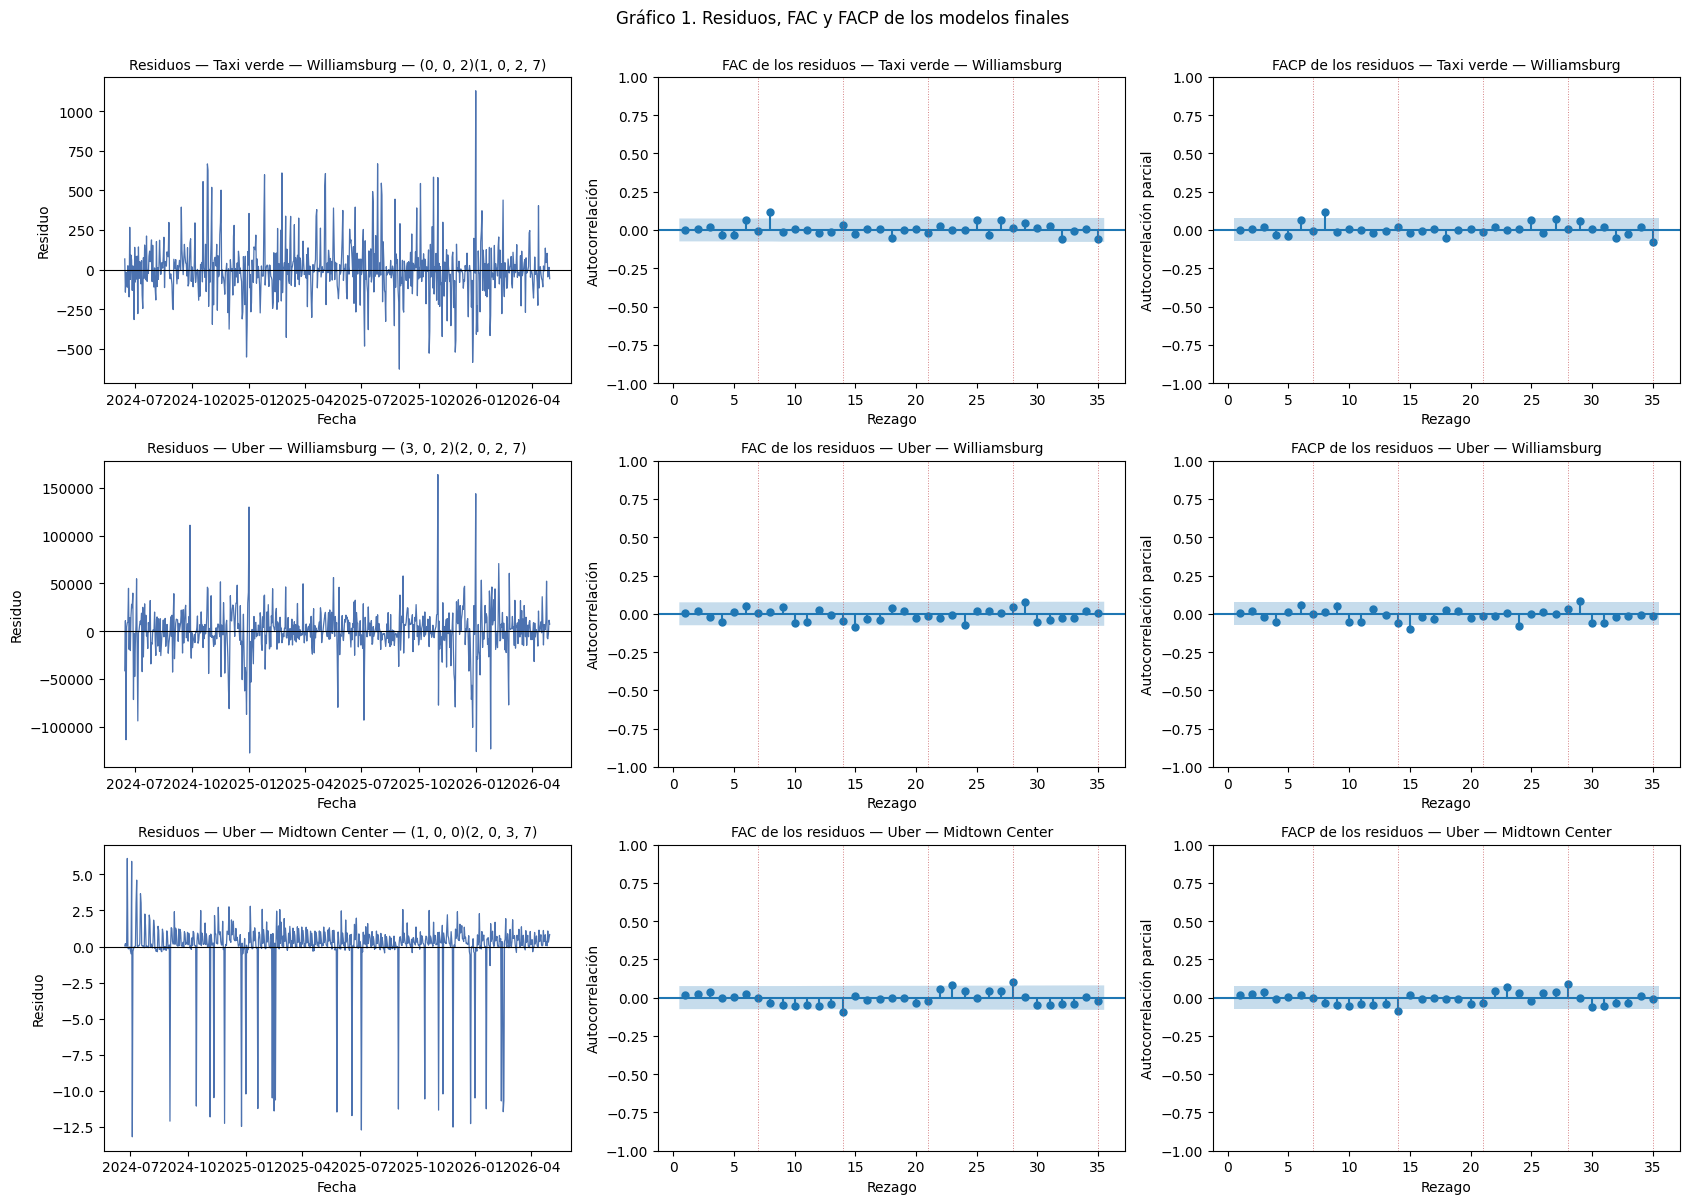

In [90]:
def graficar_diagnostico_residuos(residuos_por_serie, max_lags=MAX_LAGS_RESIDUOS):
    """Una fila por serie: residuos en el tiempo, FAC y FACP con bandas al 95%."""
    n = len(residuos_por_serie)
    fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(17, 4 * n))
    axes = np.atleast_2d(axes)

    for fila, (serie, resid) in enumerate(residuos_por_serie.items()):
        cfg = MODELOS_FINALES[serie]
        titulo = f'{SERIES[serie]["etiqueta"]} — {cfg["order"]}{cfg["seasonal_order"]}'

        # Residuos en el tiempo: se busca que oscilen alrededor de cero sin patrón visible.
        axes[fila, 0].plot(resid.index, resid.values, lw=0.9, color='#4C72B0')
        axes[fila, 0].axhline(0, color='black', lw=0.8)
        axes[fila, 0].set_title(f'Residuos — {titulo}', fontsize=10)
        axes[fila, 0].set_xlabel('Fecha')
        axes[fila, 0].set_ylabel('Residuo')

        # FAC de los residuos (zero=False: el rezago 0 vale 1 por construcción y no aporta)
        plot_acf(resid, lags=max_lags, alpha=0.05, zero=False, ax=axes[fila, 1])
        axes[fila, 1].set_title(f'FAC de los residuos — {SERIES[serie]["etiqueta"]}', fontsize=10)
        axes[fila, 1].set_xlabel('Rezago')
        axes[fila, 1].set_ylabel('Autocorrelación')

        # FACP de los residuos
        plot_pacf(resid, lags=max_lags, alpha=0.05, zero=False, method='ywm', ax=axes[fila, 2])
        axes[fila, 2].set_title(f'FACP de los residuos — {SERIES[serie]["etiqueta"]}', fontsize=10)
        axes[fila, 2].set_xlabel('Rezago')
        axes[fila, 2].set_ylabel('Autocorrelación parcial')

        # Líneas de referencia en los múltiplos del período estacional
        for col in (1, 2):
            for k in range(PERIODO_ESTACIONAL, max_lags + 1, PERIODO_ESTACIONAL):
                axes[fila, col].axvline(k, color='#C44E52', lw=0.7, ls=':', alpha=0.7)

    fig.suptitle('Gráfico 1. Residuos, FAC y FACP de los modelos finales ', fontsize=12, y=1.0)
    fig.tight_layout()
    plt.show()


graficar_diagnostico_residuos(residuos_finales)

In [91]:
def ljung_box_serie(serie, resid, cfg, lags=LAGS_LJUNG_BOX, alfa=0.05):
    """Aplica Ljung-Box a los residuos de una serie, corrigiendo por los parámetros ARMA."""
    gl_modelo = grados_libertad_arma(cfg)

    # Solo tienen sentido los rezagos que superan los grados de libertad consumidos.
    lags_validos = [h for h in lags if h > gl_modelo]
    if not lags_validos:
        return pd.DataFrame()

    prueba = acorr_ljungbox(resid, lags=lags_validos, model_df=gl_modelo, return_df=True)

    return pd.DataFrame({
        'Serie': SERIES[serie]['etiqueta'],
        'Modelo': f'{cfg["order"]}{cfg["seasonal_order"]}',
        'Rezago (h)': prueba.index,
        'Q (Ljung-Box)': prueba['lb_stat'].values,
        'gl': [h - gl_modelo for h in prueba.index],
        'p-valor': prueba['lb_pvalue'].values,
        'Conclusión': [
            'Se rechaza H₀: queda autocorrelación' if p < alfa
            else 'No se rechaza H₀: residuos ≈ ruido blanco'
            for p in prueba['lb_pvalue'].values
        ],
    })


tabla_ljung_box = pd.concat(
    [ljung_box_serie(serie, residuos_finales[serie], MODELOS_FINALES[serie])
     for serie in MODELOS_FINALES],
    ignore_index=True
)

(
    GT(tabla_ljung_box)
    .tab_header(
        title='Tabla 4. Prueba de Ljung-Box sobre los residuos de los modelos finales',
        subtitle='H₀: los residuos no están autocorrelacionados hasta el rezago h (α = 0,05)'
    )
    .fmt_number(columns=['Q (Ljung-Box)', 'p-valor'], decimals=4)
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
    .tab_options(table_font_names='Arial')
)

GT(_tbl_data=                        Serie                 Modelo  Rezago (h)  \
0   Taxi verde — Williamsburg  (0, 0, 2)(1, 0, 2, 7)           7   
1   Taxi verde — Williamsburg  (0, 0, 2)(1, 0, 2, 7)          14   
2   Taxi verde — Williamsburg  (0, 0, 2)(1, 0, 2, 7)          21   
3   Taxi verde — Williamsburg  (0, 0, 2)(1, 0, 2, 7)          28   
4         Uber — Williamsburg  (3, 0, 2)(2, 0, 2, 7)          14   
5         Uber — Williamsburg  (3, 0, 2)(2, 0, 2, 7)          21   
6         Uber — Williamsburg  (3, 0, 2)(2, 0, 2, 7)          28   
7       Uber — Midtown Center  (1, 0, 0)(2, 0, 3, 7)           7   
8       Uber — Midtown Center  (1, 0, 0)(2, 0, 3, 7)          14   
9       Uber — Midtown Center  (1, 0, 0)(2, 0, 3, 7)          21   
10      Uber — Midtown Center  (1, 0, 0)(2, 0, 3, 7)          28   

    Q (Ljung-Box)  gl   p-valor                                 Conclusión  
0        4.880519   2  0.087138  No se rechaza H₀: residuos ≈ ruido blanco  
1       15.591733   9  0.075912  No se rechaza H₀: residuos ≈ ruido blanco  
2       18.390252  16  0.301545  No se rechaza H₀: residuos ≈ ruido blanco  
3       26.418398  23  0.281515  No se rechaza H₀: residuos ≈ ruido blanco  
4       12.818883   5  0.025136       Se rechaza H₀: queda autocorrelación  
5       22.121629  12  0.036179       Se rechaza H₀: queda autocorrelación  
6       28.242511  19  0.078871  No se rechaza H₀: residuos ≈ ruido blanco  
7        1.967866   1  0.160675  No se rechaza H₀: residuos ≈ ruido blanco  
8       17.232413   8  0.027778       Se rechaza H₀: queda autocorrelación  
9       18.648272  15  0.230117  No se rechaza H₀: residuos ≈ ruido blanco  
10      36.659283  22  0.025774       Se rechaza H₀: queda autocorrelación  , _body=<great_tables._gt_data.Body object at 0x7b7d7dd97930>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Modelo', type=<ColInfoTypeEnum.default: 1>, column_label='Modelo', column_align='right', column_width=None), ColInfo(var='Rezago (h)', type=<ColInfoTypeEnum.default: 1>, column_label='Rezago (h)', column_align='right', column_width=None), ColInfo(var='Q (Ljung-Box)', type=<ColInfoTypeEnum.default: 1>, column_label='Q (Ljung-Box)', column_align='right', column_width=None), ColInfo(var='gl', type=<ColInfoTypeEnum.default: 1>, column_label='gl', column_align='right', column_width=None), ColInfo(var='p-valor', type=<ColInfoTypeEnum.default: 1>, column_label='p-valor', column_align='right', column_width=None), ColInfo(var='Conclusión', type=<ColInfoTypeEnum.default: 1>, column_label='Conclusión', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7b7ce972ec50>, _spanners=Spanners([]), _heading=Heading(title='Tabla 4. Prueba de Ljung-Box sobre los residuos de los modelos finales', subtitle='H₀: los residuos no están autocorrelacionados hasta el rezago h (α = 0,05)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7b7ce94c5fd0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7b7ce9675e50>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=2, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None

## 9. Modelos de Machine Learning — LightGBM y XGBoost

Se incorporan dos ensambles de árboles de decisión con *gradient boosting* —**LightGBM** y
**XGBoost**— como segundo enfoque de pronóstico, entre el benchmark estadístico (SARIMAX) y la red
neuronal recurrente (LSTM).

A diferencia del SARIMAX, que modela la dependencia temporal a través de la estructura ARMA, estos
modelos la reciben **explícitamente como variables**: los rezagos y estadísticos móviles construidos
en la sección 7, más las variables de calendario de la sección 6. El modelo no "sabe" que los datos
son una serie de tiempo; aprende una función que mapea ese conjunto de *features* al valor del día.

El flujo replica deliberadamente el de la sección de LSTM, para que las métricas resulten
comparables entre los tres enfoques:

1. Verificación de requisitos previos.
2. Preparación de la matriz de *features* y partición train / test.
3. Definición de hiperparámetros y entrenamiento.
4. Validación cruzada temporal sobre **las mismas cinco ventanas** que usa el LSTM.
5. Evaluación en test (mayo 2026) — mismo horizonte que todos los demás modelos.
6. Diagnóstico de residuos.
7. Guardado de resultados para la tabla de comparación final.

**Diferencia metodológica central frente al LSTM:** como la matriz de *features* incluye rezagos de
orden 1 y 2, el pronóstico de los 31 días de test es necesariamente **recursivo** (cada día
predicho alimenta los rezagos del siguiente), mientras que el LSTM produce un pronóstico
**directo** del horizonte completo. Esa diferencia es intrínseca a los modelos y se documenta en el
análisis del error por día del horizonte.

### 9.2. Preparación de los datos

La matriz de *features* es la construida en la sección 7 (`features_por_serie`): variables de
calendario, rezagos de orden 1, 2, 7, 14, 21, 28, 30 y 35, y media y desvío móviles de 7, 14, 28 y
35 días calculados sobre la serie desplazada un día, de modo que en *t* solo resuman información
hasta *t−1*.

La constante `ESCALA_ML` define sobre qué escala se entrena:

- `'original'` — ingresos en dólares, **igual que el LSTM**. Es el valor por defecto, para que la
  comparación entre ambos enfoques no mezcle diferencias de escala con diferencias de modelo.
- `'modelo'` — aplica la transformación de la sección 4 (log1p en Uber — Midtown Center), igual que
  el SARIMAX, y destransforma antes de calcular las métricas.

En cualquiera de los dos casos **todas las métricas se reportan en dólares**, que es lo que hace
comparables los tres enfoques.

In [18]:

# 'original' = escala en dólares (igual que el LSTM) | 'modelo' = con la transformación de la sec. 4
ESCALA_ML = 'modelo'

# Variables de calendario que se usan como features. El LSTM usa un subconjunto
# (LSTM_FUTR_EXOG); para una comparación estricta puede reducirse a esa misma lista.
FEATURES_CALENDARIO = list(exog_calendario.columns)

HORIZONTE_TEST = 31                                  # días de mayo 2026, igual que LSTM y SARIMAX
FECHA_CORTE_TEST_ML = pd.Timestamp('2026-05-01')     # mismo criterio que dividir_train_test()


def construir_features_ml(serie, escala=ESCALA_ML):
    """Matriz de features + target de una serie, con las definiciones de las secciones 6 y 7.

    Se reconstruye en lugar de tomar `features_por_serie` directamente para poder
    alternar la escala de entrenamiento sin tocar el resto del notebook.
    """
    y = df[serie] if escala == 'original' else df_modelo[columna_modelo(serie)]

    feats = exog_calendario[FEATURES_CALENDARIO].join(agregar_features_autorregresivas(y))
    feats['target'] = y
    return feats


def destransformar_ml(serie, valores, escala=ESCALA_ML):
    """Lleva las predicciones a dólares. En escala 'original' no hace nada."""
    if escala == 'original':
        return valores
    return destransformar(serie, valores)


# ── Construcción de los datos por serie ───────────────────────────────────
datos_ml = {}
for serie, titulo in COLUMNAS_ORIGINALES.items():
    feats = construir_features_ml(serie)

    entrenamiento = feats[feats.index < FECHA_CORTE_TEST_ML].dropna()
    prueba = feats[feats.index >= FECHA_CORTE_TEST_ML]

    datos_ml[serie] = {
        'titulo': titulo,
        'X_train': entrenamiento.drop(columns='target'),
        'y_train': entrenamiento['target'],
        'fechas_test': prueba.index,
        'y_test': df.loc[prueba.index, serie],      # el real siempre en dólares
        'serie_completa': feats['target'],          # en la escala de entrenamiento
    }

    print(f"{titulo:28s}: train {entrenamiento.index.min().date()} → "
          f"{entrenamiento.index.max().date()} ({len(entrenamiento)} filas) | "
          f"test {prueba.index.min().date()} → {prueba.index.max().date()} ({len(prueba)} días)")

COLUMNAS_FEATURES = list(datos_ml[list(datos_ml)[0]]['X_train'].columns)
print(f"\nFeatures utilizadas ({len(COLUMNAS_FEATURES)}): {COLUMNAS_FEATURES}")
print(f"Escala de entrenamiento: {ESCALA_ML}")


# ── Ventanas del protocolo de evaluación ──────────────────────────────────
# Se definen acá porque las usan tanto la búsqueda de hiperparámetros (9.5)
# como la validación cruzada (9.6).
N_WINDOWS_CV = 5
STEP_SIZE_CV = 30


def ventanas_cv(ultimo_dia_train, h=HORIZONTE_TEST,
                n_windows=N_WINDOWS_CV, step_size=STEP_SIZE_CV):
    """Puntos de corte de la validación cruzada, con la convención de NeuralForecast.

    Cada ventana pronostica los días (cutoff, cutoff + h]. La última termina en el
    último día de train y las anteriores se desplazan `step_size` días hacia atrás.
    """
    cortes = [ultimo_dia_train - pd.Timedelta(days=h + i * step_size)
              for i in range(n_windows)]
    return sorted(cortes)


def verificar_ventanas(cortes):
    """Contrasta los puntos de corte con los que usó la CV del LSTM, si está en memoria."""
    if 'cv_df_lstm' not in globals():
        print('  [aviso] la CV del LSTM no está en memoria: no se puede verificar la coincidencia '
              'de ventanas. Ejecutá esta celda después de la sección de LSTM para comprobarlo.')
        return

    cortes_lstm = sorted(pd.to_datetime(pd.Series(cv_df_lstm['cutoff']).unique()))
    if [pd.Timestamp(c) for c in cortes] == [pd.Timestamp(c) for c in cortes_lstm]:
        print('  ✓ Los puntos de corte coinciden exactamente con los de la CV del LSTM.')
    else:
        print('  ⚠ Los puntos de corte NO coinciden con los del LSTM:')
        print(f'     ML  : {[str(pd.Timestamp(c).date()) for c in cortes]}')
        print(f'     LSTM: {[str(pd.Timestamp(c).date()) for c in cortes_lstm]}')
        print('     Las métricas de CV no serán estrictamente comparables hasta corregirlo.')


ULTIMO_DIA_TRAIN = datos_ml[list(datos_ml)[0]]['y_train'].index.max()
CORTES_CV = ventanas_cv(ULTIMO_DIA_TRAIN)

print(f'Ventanas de validación cruzada ({N_WINDOWS_CV} ventanas, step={STEP_SIZE_CV}, '
      f'h={HORIZONTE_TEST}):')
for corte in CORTES_CV:
    print(f'   corte {corte.date()} → pronostica {(corte + pd.Timedelta(days=1)).date()} '
          f'a {(corte + pd.Timedelta(days=HORIZONTE_TEST)).date()}')
verificar_ventanas(CORTES_CV)

Taxi verde — Williamsburg   : train 2024-07-06 → 2026-04-30 (664 filas) | test 2026-05-01 → 2026-05-31 (31 días)
Uber — Williamsburg         : train 2024-07-06 → 2026-04-30 (664 filas) | test 2026-05-01 → 2026-05-31 (31 días)
Uber — Midtown Center       : train 2024-07-06 → 2026-04-30 (664 filas) | test 2026-05-01 → 2026-05-31 (31 días)

Features utilizadas (23): ['dayofmonth', 'dayofweek', 'weekofyear', 'month', 'quarter', 'year', 'holiday', 'lag_1', 'lag_2', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_30', 'lag_35', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_28', 'rolling_std_28', 'rolling_mean_35', 'rolling_std_35']
Escala de entrenamiento: modelo
Ventanas de validación cruzada (5 ventanas, step=30, h=31):
   corte 2025-11-30 → pronostica 2025-12-01 a 2025-12-31
   corte 2025-12-30 → pronostica 2025-12-31 a 2026-01-30
   corte 2026-01-29 → pronostica 2026-01-30 a 2026-03-01
   corte 2026-02-28 → pronostica 2026-03-01 a 2026-03-31
   corte 2

### 9.3. Hiperparámetros

Los valores se eligen en función del tamaño del conjunto de entrenamiento (~665 filas utilizables
por serie), que es chico para ensambles de árboles. La configuración prioriza la regularización
sobre la capacidad:

| Parámetro | LightGBM | XGBoost | Justificación |
|-----------|----------|---------|---------------|
| `n_estimators` | 400 | 400 | Suficiente con tasa de aprendizaje baja |
| `learning_rate` | 0,05 | 0,05 | Compromiso entre convergencia y sobreajuste |
| profundidad | `num_leaves = 15` | `max_depth = 4` | Árboles poco profundos: pocas observaciones por hoja |
| `min_child_samples` / `min_child_weight` | 20 | 5 | Evita hojas con muy pocas observaciones |
| `subsample` | 0,8 | 0,8 | Submuestreo de filas (*bagging*) |
| `colsample_bytree` | 0,8 | 0,8 | Submuestreo de *features* en cada árbol |
| `reg_lambda` | 1,0 | 1,0 | Penalización L2 |
| `random_state` | 42 | 42 | Reproducibilidad, igual que la semilla del LSTM |

Estos valores funcionan como **línea de base**: son los que se usan mientras no se ejecute la
búsqueda de hiperparámetros de la sección 9.5, o si se decide desactivarla. Cuando esa búsqueda
corre, sus resultados reemplazan a estos valores para la serie y el modelo correspondientes.

In [93]:
PARAMS_LGBM = dict(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=20,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1,
)

PARAMS_XGB = dict(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0,
)

MODELOS_ML = ['LightGBM', 'XGBoost']

PARAMS_BASE = {'LightGBM': PARAMS_LGBM, 'XGBoost': PARAMS_XGB}

# Se completa en la sección 9.5 con los hiperparámetros que encuentre Optuna.
# Mientras esté vacío, todo el notebook usa los valores base de arriba.
MEJORES_PARAMS_ML = {}


def instanciar_modelo_ml(nombre, params=None):
    """Instancia nueva de un modelo. `params` reemplaza a los valores base."""
    configuracion = dict(PARAMS_BASE[nombre])
    if params:
        configuracion.update(params)

    if nombre == 'LightGBM':
        return lgb.LGBMRegressor(**configuracion)
    if nombre == 'XGBoost':
        return xgb.XGBRegressor(**configuracion)
    raise ValueError(f'Modelo desconocido: {nombre}')


def entrenar_modelo_ml(nombre, X, y, serie=None):
    """Devuelve un modelo entrenado sobre (X, y).

    Si la serie tiene hiperparámetros optimizados en MEJORES_PARAMS_ML, los usa;
    si no, cae en los valores base. Siempre instancia un modelo nuevo, para que cada
    ventana de validación cruzada reentrene desde cero (equivale a `refit=True`
    en la validación cruzada del LSTM).
    """
    return instanciar_modelo_ml(nombre, MEJORES_PARAMS_ML.get((serie, nombre))).fit(X, y)

### 9.4. Pronóstico recursivo

La matriz de *features* incluye el rezago de orden 1, que para el segundo día del horizonte ya no
está disponible: el 2 de mayo necesita el valor del 1 de mayo, que es justamente lo que se está
pronosticando. El procedimiento es entonces recursivo: se predice un día, ese valor se incorpora a
la serie, se recalculan los rezagos y estadísticos móviles, y se predice el siguiente.

La implementación reutiliza `agregar_features_autorregresivas` de la sección 7 en lugar de
reconstruir las *features* a mano, de modo que la definición de cada variable sea necesariamente
idéntica en entrenamiento y en predicción. Es el punto donde con más facilidad se introducen
inconsistencias silenciosas o *leakage*.

El costo de este esquema es la **acumulación de error**: un desvío en el día 1 contamina los
rezagos de los días siguientes. El LSTM no tiene este problema porque pronostica el horizonte
completo de forma directa, y esa diferencia se cuantifica más adelante en el gráfico de error por
día del horizonte.

In [94]:
def pronostico_recursivo(modelo, serie_historica, fechas_futuras,
                         columnas_features=None, escala=ESCALA_ML):
    """Pronóstico iterativo: cada predicción se incorpora a la serie y alimenta los rezagos.

    serie_historica: target observado hasta el día previo al horizonte, en la escala
                     de entrenamiento.
    fechas_futuras : DatetimeIndex contiguo de los días a pronosticar.

    Devuelve una Serie indexada por `fechas_futuras`, en la escala de entrenamiento.
    """
    if columnas_features is None:
        columnas_features = COLUMNAS_FEATURES

    serie = serie_historica.copy()
    predicciones = []

    for fecha in fechas_futuras:
        # Se reserva el lugar del día a predecir: sus features solo miran hacia atrás,
        # de modo que este NaN no interviene en su propia fila.
        serie.loc[fecha] = np.nan

        autorregresivas = agregar_features_autorregresivas(serie).loc[[fecha]]
        fila = exog_calendario.loc[[fecha], FEATURES_CALENDARIO].join(autorregresivas)

        pred = float(modelo.predict(fila[columnas_features])[0])
        serie.loc[fecha] = pred       # la predicción alimenta los rezagos de los días siguientes
        predicciones.append(pred)

    return pd.Series(predicciones, index=fechas_futuras, name='pred')

### 9.5. Optimización de hiperparámetros con Optuna

En lugar de una grilla exhaustiva como la del SARIMAX, la búsqueda usa **Optuna** con su muestreador
por defecto (TPE, *Tree-structured Parzen Estimator*), que propone cada combinación en función de
los resultados de las anteriores. Para un espacio continuo y de alta dimensión —tasa de aprendizaje,
profundidad, submuestreo, regularización— es mucho más eficiente que recorrer un producto
cartesiano.

**Qué se optimiza.** La función objetivo es el RMSE en dólares del pronóstico recursivo a 31 días,
es decir, exactamente la métrica y el procedimiento con los que después se evalúa el modelo. No se
optimiza el error a un paso, que sería más barato pero no representa el uso real.

**Sobre qué ventanas.** Un punto importante de diseño: las ventanas de ajuste son **anteriores** a
las cinco ventanas de validación cruzada de la sección 9.6. Si se optimizara sobre las mismas
ventanas con las que luego se reporta el `RMSE_CV`, esa métrica quedaría sesgada a la baja, porque
los hiperparámetros habrían sido elegidos para minimizarla. Con ventanas separadas, el `RMSE_CV`
reportado sigue siendo una estimación honesta, y el conjunto de test nunca interviene.

**Persistencia.** Cada estudio se guarda en una base SQLite dentro de la carpeta de caché, con el
mismo espíritu que el caché del grid search del SARIMAX:

- **Un estudio por combinación de (serie, modelo)**, con un hash en el nombre que resume el espacio
  de búsqueda, las ventanas, el horizonte y la escala de entrenamiento. Si se cambia cualquiera de
  esas cosas, el hash cambia y esa búsqueda se rehace; el resto queda intacto.
- **Guardado incremental**: Optuna persiste cada *trial* apenas termina. Si se corta la ejecución a
  mitad de camino, al volver a correr la celda se retoman solo los *trials* faltantes hasta
  completar `N_TRIALS_OPTUNA`.
- Si el estudio ya tiene todos los *trials*, la celda **no ejecuta nada** y solo lee el mejor
  resultado.

La base se trabaja sobre una copia en disco local y se sincroniza con la carpeta persistente al
terminar cada estudio, porque SQLite necesita bloqueo de archivos y ese bloqueo no es confiable
sobre Google Drive montado.

In [95]:
%pip install optuna -q

In [96]:
import inspect
import shutil
import tempfile

import optuna
from sklearn.metrics import mean_squared_error

optuna.logging.set_verbosity(optuna.logging.WARNING)   # silencia el log por trial

# ── Configuración de la búsqueda ─────────────────────────────────────────────
USAR_OPTUNA = True            # False -> se usan los PARAMS_BASE de la sección 9.3
N_TRIALS_OPTUNA = 100          # trials por (serie, modelo)
N_VENTANAS_OPTUNA = 6         # ventanas de ajuste, anteriores a las de evaluación
VERSION_OPTUNA = 'v3_logp1'         # cambiar para invalidar todos los estudios

# ── Almacenamiento persistente ───────────────────────────────────────────────
OPTUNA_DIR = CACHE_DIR / 'optuna'
OPTUNA_DIR.mkdir(parents=True, exist_ok=True)

NOMBRE_DB = 'optuna_tp2_v3_logp1.db'
RUTA_DB_PERSISTENTE = OPTUNA_DIR / NOMBRE_DB                         # Drive
RUTA_DB_TRABAJO = pathlib.Path(tempfile.gettempdir()) / NOMBRE_DB    # disco local


def preparar_db_optuna():
    """Trae la base desde el almacenamiento persistente al disco local.

    SQLite necesita bloqueo de archivos, que no funciona de forma confiable sobre
    Google Drive montado; por eso se trabaja sobre una copia local.
    """
    if RUTA_DB_PERSISTENTE.exists() and not RUTA_DB_TRABAJO.exists():
        shutil.copy2(RUTA_DB_PERSISTENTE, RUTA_DB_TRABAJO)
        print(f'  Base de estudios recuperada desde {RUTA_DB_PERSISTENTE}')
    return f'sqlite:///{RUTA_DB_TRABAJO}'


def sincronizar_db_optuna():
    """Copia la base local a la carpeta persistente (se llama al cerrar cada estudio)."""
    if RUTA_DB_TRABAJO.exists():
        shutil.copy2(RUTA_DB_TRABAJO, RUTA_DB_PERSISTENTE)


# ── Espacios de búsqueda ─────────────────────────────────────────────────────
def espacio_lightgbm(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 7, 31),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 40),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }


def espacio_xgboost(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 1e-4, 1.0, log=True),
    }


ESPACIOS_OPTUNA = {'LightGBM': espacio_lightgbm, 'XGBoost': espacio_xgboost}


# ── Ventanas de ajuste: anteriores a las de evaluación ───────────────────────
def ventanas_optuna(n_ventanas=N_VENTANAS_OPTUNA, h=HORIZONTE_TEST, step_size=STEP_SIZE_CV):
    """Puntos de corte para la búsqueda, ubicados antes de la primera ventana de CV.

    Así los hiperparámetros no se eligen mirando los mismos días con los que después
    se reporta el RMSE_CV.
    """
    primer_corte_cv = min(CORTES_CV)
    ultimo = primer_corte_cv - pd.Timedelta(days=h)
    cortes = [ultimo - pd.Timedelta(days=i * step_size) for i in range(n_ventanas)]
    return sorted(cortes)


def evaluar_parametros(serie, nombre_modelo, params, cortes, h=HORIZONTE_TEST):
    """RMSE en dólares del pronóstico recursivo a h días, agrupando todas las ventanas."""
    feats = construir_features_ml(serie)
    reales, predichos = [], []

    for corte in cortes:
        entrenamiento = feats[feats.index <= corte].dropna()
        fechas = pd.date_range(corte + pd.Timedelta(days=1), periods=h, freq='D')
        fechas = fechas.intersection(feats.index)
        if len(fechas) == 0 or entrenamiento.empty:
            continue

        modelo = instanciar_modelo_ml(nombre_modelo, params).fit(
            entrenamiento.drop(columns='target'), entrenamiento['target'])

        pred = pronostico_recursivo(modelo, feats['target'].loc[:corte], fechas)
        predichos.append(np.clip(destransformar_ml(serie, pred.values), 0, None))
        reales.append(df.loc[fechas, serie].values)

    if not reales:
        return float('inf')

    return float(np.sqrt(mean_squared_error(np.concatenate(reales), np.concatenate(predichos))))


# ── Un estudio por (serie, modelo), identificado por hash ────────────────────
def fuente_espacio(funcion):
    """Código fuente de la función que define el espacio de búsqueda.

    Entra en la firma del estudio para que, al editar los rangos, el hash cambie y
    esa búsqueda se rehaga. Si el entorno no expone el código fuente, se cae al
    nombre de la función y la invalidación queda a cargo de VERSION_OPTUNA.
    """
    try:
        return inspect.getsource(funcion)
    except (OSError, TypeError):
        return funcion.__name__


def firma_optuna(serie, nombre_modelo, cortes):
    """Diccionario que identifica unívocamente una búsqueda (mismo criterio que el grid search)."""
    return {
        'version': VERSION_OPTUNA,
        'serie': serie,
        'modelo': nombre_modelo,
        'escala': ESCALA_ML,
        'horizonte': HORIZONTE_TEST,
        'cortes': [str(c.date()) for c in cortes],
        'features': sorted(COLUMNAS_FEATURES),
        # El código de la función de espacio entra en la firma: si se editan los
        # rangos, el hash cambia y esa búsqueda se rehace desde cero.
        'espacio': fuente_espacio(ESPACIOS_OPTUNA[nombre_modelo]),
    }


def nombre_estudio(serie, nombre_modelo, cortes):
    firma = firma_optuna(serie, nombre_modelo, cortes)
    texto = json.dumps(firma, sort_keys=True, ensure_ascii=False)
    hash_corto = hashlib.md5(texto.encode('utf-8')).hexdigest()[:10]
    return f'{serie}__{nombre_modelo}__{hash_corto}', firma


def optimizar_hiperparametros(serie, nombre_modelo, cortes, n_trials=N_TRIALS_OPTUNA,
                              storage=None, verbose=True):
    """Crea o retoma el estudio de Optuna y ejecuta solo los trials que falten."""
    nombre, firma = nombre_estudio(serie, nombre_modelo, cortes)

    estudio = optuna.create_study(
        study_name=nombre,
        storage=storage,
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=42),
        load_if_exists=True,
    )
    for clave, valor in firma.items():
        estudio.set_user_attr(clave, valor)

    completados = [t for t in estudio.trials if t.state == optuna.trial.TrialState.COMPLETE]
    faltantes = max(0, n_trials - len(completados))

    if verbose:
        print(f'  {COLUMNAS_ORIGINALES[serie]} | {nombre_modelo}: {n_trials} trials '
              f'({len(completados)} en la base, {faltantes} pendientes)')

    if faltantes:
        estudio.optimize(
            lambda trial: evaluar_parametros(
                serie, nombre_modelo, ESPACIOS_OPTUNA[nombre_modelo](trial), cortes),
            n_trials=faltantes,
            show_progress_bar=False,
        )
        sincronizar_db_optuna()
        if verbose:
            print(f'    {faltantes} trials ejecutados y guardados en {NOMBRE_DB}')

    return estudio


# ── Ejecución ────────────────────────────────────────────────────────────────
CORTES_OPTUNA = ventanas_optuna()

print(f'Ventanas de ajuste ({N_VENTANAS_OPTUNA}, anteriores a las de validación cruzada):')
for corte in CORTES_OPTUNA:
    print(f'   corte {corte.date()} → ajusta sobre {(corte + pd.Timedelta(days=1)).date()} '
          f'a {(corte + pd.Timedelta(days=HORIZONTE_TEST)).date()}')
print(f'   primera ventana de CV: {min(CORTES_CV).date()}  (sin solapamiento)\n')

estudios_optuna = {}

if USAR_OPTUNA:
    almacenamiento = preparar_db_optuna()
    print(f'Base de estudios: {RUTA_DB_PERSISTENTE}\n')

    for serie in datos_ml:
        for nombre_modelo in MODELOS_ML:
            estudio = optimizar_hiperparametros(serie, nombre_modelo, CORTES_OPTUNA,
                                                storage=almacenamiento)
            estudios_optuna[(serie, nombre_modelo)] = estudio
            MEJORES_PARAMS_ML[(serie, nombre_modelo)] = estudio.best_params

    sincronizar_db_optuna()
    print(f'\n✓ Búsqueda completa. Hiperparámetros optimizados para '
          f'{len(MEJORES_PARAMS_ML)} combinaciones (serie × modelo).')
else:
    print('USAR_OPTUNA = False: se usan los hiperparámetros base de la sección 9.3.')

Ventanas de ajuste (6, anteriores a las de validación cruzada):
   corte 2025-06-02 → ajusta sobre 2025-06-03 a 2025-07-03
   corte 2025-07-02 → ajusta sobre 2025-07-03 a 2025-08-02
   corte 2025-08-01 → ajusta sobre 2025-08-02 a 2025-09-01
   corte 2025-08-31 → ajusta sobre 2025-09-01 a 2025-10-01
   corte 2025-09-30 → ajusta sobre 2025-10-01 a 2025-10-31
   corte 2025-10-30 → ajusta sobre 2025-10-31 a 2025-11-30
   primera ventana de CV: 2025-11-30  (sin solapamiento)

Base de estudios: /content/drive/MyDrive/MCD/AST/Trabajo Final/Trabajo Final/data/cache/optuna/optuna_tp2_v3_logp1.db

  Taxi verde — Williamsburg | LightGBM: 100 trials (100 en la base, 0 pendientes)
  Taxi verde — Williamsburg | XGBoost: 100 trials (100 en la base, 0 pendientes)
  Uber — Williamsburg | LightGBM: 100 trials (100 en la base, 0 pendientes)
  Uber — Williamsburg | XGBoost: 100 trials (100 en la base, 0 pendientes)
  Uber — Midtown Center | LightGBM: 100 trials (100 en la base, 0 pendientes)
  Uber — Midt

In [97]:
if estudios_optuna:
    filas_optuna = []
    for (serie, nombre_modelo), estudio in estudios_optuna.items():
        completados = [t for t in estudio.trials
                       if t.state == optuna.trial.TrialState.COMPLETE]

        # RMSE del modelo base sobre las mismas ventanas, como referencia
        rmse_base = evaluar_parametros(serie, nombre_modelo, None, CORTES_OPTUNA)

        filas_optuna.append({
            'Serie': COLUMNAS_ORIGINALES[serie],
            'Modelo': nombre_modelo,
            'Trials': len(completados),
            'RMSE base': round(rmse_base, 2),
            'RMSE optimizado': round(estudio.best_value, 2),
            'Mejora %': round(100 * (rmse_base - estudio.best_value) / rmse_base, 1),
            'Hiperparámetros': ', '.join(
                f'{k}={v:.4g}' if isinstance(v, float) else f'{k}={v}'
                for k, v in estudio.best_params.items()
            ),
        })

    tabla_optuna = pd.DataFrame(filas_optuna)

    display(
        GT(tabla_optuna)
        .tab_header(
            title='Tabla 5. Optimización de hiperparámetros con Optuna',
        )
        .fmt_number(columns=['RMSE base', 'RMSE optimizado'], decimals=2)
        .fmt_number(columns=['Mejora %'], decimals=1)
        .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
    )
else:
    print('No hay estudios de Optuna en memoria (USAR_OPTUNA = False).')

GT(_tbl_data=                       Serie    Modelo  Trials  RMSE base  RMSE optimizado  \
0  Taxi verde — Williamsburg  LightGBM     100     215.36           193.15   
1  Taxi verde — Williamsburg   XGBoost     100     210.15           194.10   
2        Uber — Williamsburg  LightGBM     100   21414.20         22327.80   
3        Uber — Williamsburg   XGBoost     100   25616.76         21558.10   
4      Uber — Midtown Center  LightGBM     100   96785.96         81827.57   
5      Uber — Midtown Center   XGBoost     100   82479.20         78742.01   

   Mejora %  \
0      10.3   
1       7.6   
2      -4.3   
3      15.8   
4      15.5   
5       4.5   

                                                                                                                                           Hiperparámetros  
0              n_estimators=700, learning_rate=0.05356, num_leaves=20, min_child_samples=7, subsample=0.9259, colsample_bytree=0.9534, reg_lambda=0.008866  
1  n_estimators=500, learning_rate=0.08384, max_depth=3, min_child_weight=11, subsample=0.837, colsample_bytree=0.6186, reg_lambda=0.2693, gamma=0.0004809  
2                n_estimators=500, learning_rate=0.01231, num_leaves=22, min_child_samples=10, subsample=0.9654, colsample_bytree=0.87, reg_lambda=0.08783  
3      n_estimators=600, learning_rate=0.0243, max_depth=6, min_child_weight=17, subsample=0.7319, colsample_bytree=0.8273, reg_lambda=1.112, gamma=0.2356  
4               n_estimators=300, learning_rate=0.03355, num_leaves=12, min_child_samples=17, subsample=0.6659, colsample_bytree=0.6836, reg_lambda=0.8081  
5    n_estimators=500, learning_rate=0.04996, max_depth=5, min_child_weight=20, subsample=0.6063, colsample_bytree=0.9143, reg_lambda=7.209, gamma=0.05959  , _body=<great_tables._gt_data.Body object at 0x7b7ce8fc0aa0>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Modelo', type=<ColInfoTypeEnum.default: 1>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='Trials', type=<ColInfoTypeEnum.default: 1>, column_label='Trials', column_align='right', column_width=None), ColInfo(var='RMSE base', type=<ColInfoTypeEnum.default: 1>, column_label='RMSE base', column_align='right', column_width=None), ColInfo(var='RMSE optimizado', type=<ColInfoTypeEnum.default: 1>, column_label='RMSE optimizado', column_align='right', column_width=None), ColInfo(var='Mejora %', type=<ColInfoTypeEnum.default: 1>, column_label='Mejora %', column_align='right', column_width=None), ColInfo(var='Hiperparámetros', type=<ColInfoTypeEnum.default: 1>, column_label='Hiperparámetros', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7b7ce9330650>, _spanners=Spanners([]), _heading=Heading(title='Tabla 5. Optimización de hiperparámetros con Optuna', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7b7ce8fdf710>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7b7ce8fdd250>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=2, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, t

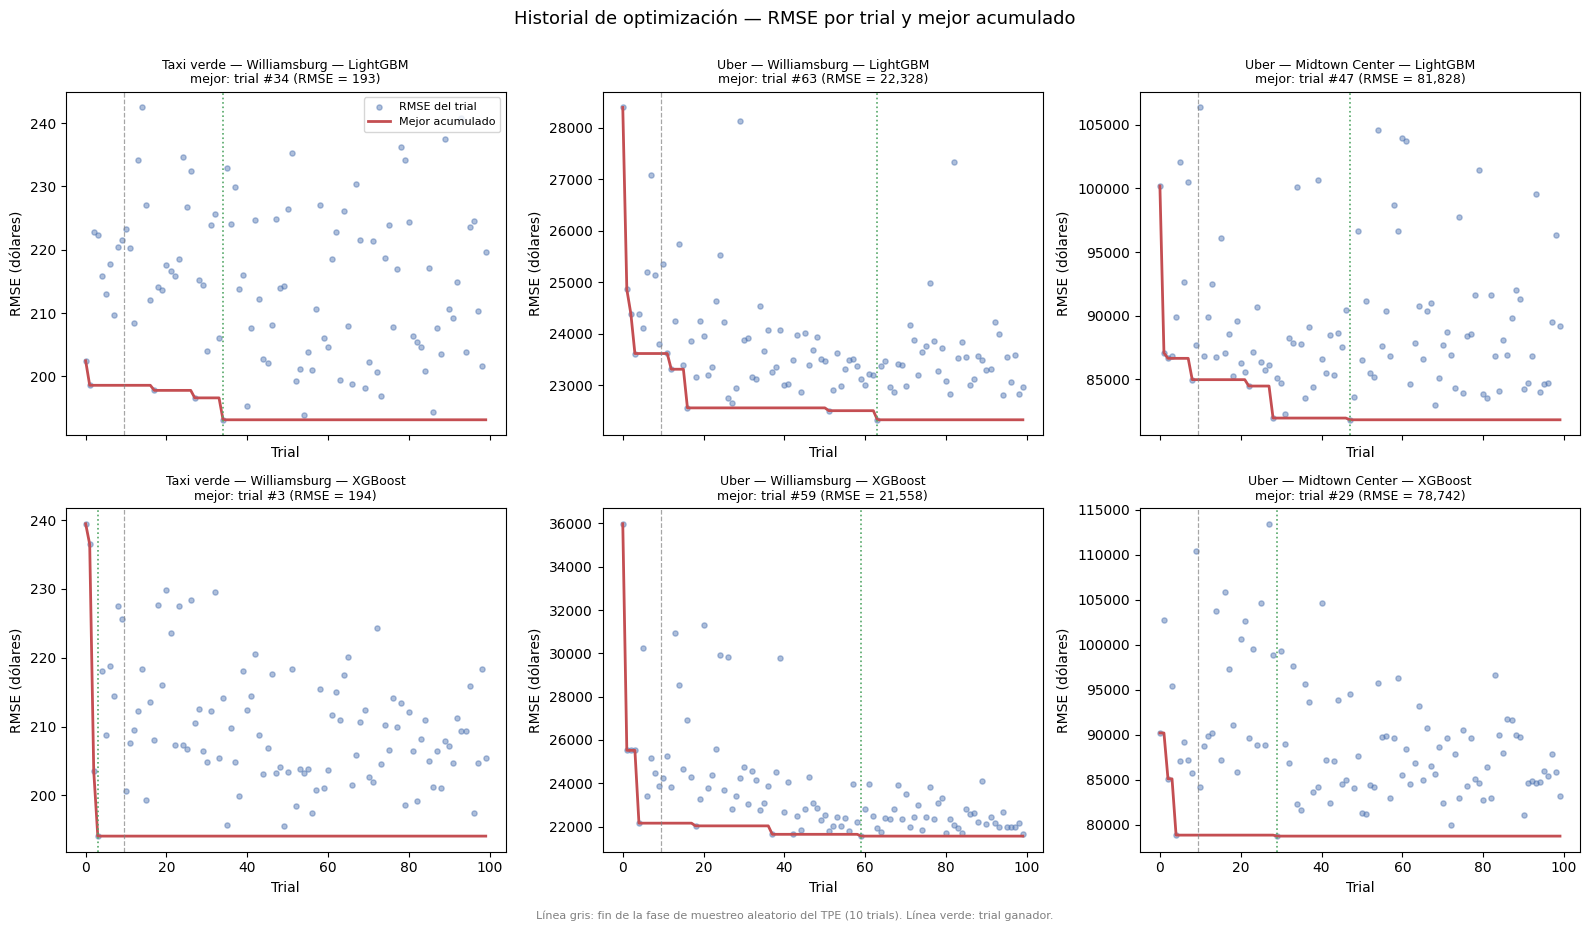

In [98]:
# ── Gráfico. Historial de optimización ───────────────────────────────────────
N_TRIALS_ALEATORIOS = 10   # n_startup_trials por defecto del TPESampler


def historial_estudio(estudio):
    """Valores de cada trial completado y el mejor acumulado hasta ese punto."""
    completados = [t for t in estudio.trials
                   if t.state == optuna.trial.TrialState.COMPLETE and t.value is not None]
    valores = pd.Series([t.value for t in completados],
                        index=[t.number for t in completados]).sort_index()
    return valores, valores.cummin()


n_filas, n_cols = len(MODELOS_ML), len(datos_ml)
fig, axes = plt.subplots(n_filas, n_cols, figsize=(16, 4.5 * n_filas), sharex=True)
axes = np.atleast_2d(axes)

fig.suptitle('Historial de optimización — RMSE por trial y mejor acumulado',
             fontsize=13, y=1.0)

for i, nombre_modelo in enumerate(MODELOS_ML):
    for j, serie in enumerate(datos_ml):
        ax = axes[i, j]
        estudio = estudios_optuna.get((serie, nombre_modelo))
        if estudio is None:
            ax.axis('off')
            continue

        valores, mejor = historial_estudio(estudio)

        ax.scatter(valores.index, valores.values, s=14, alpha=0.45,
                   color='#4C72B0', label='RMSE del trial')
        ax.plot(mejor.index, mejor.values, lw=2, color='#C44E52',
                label='Mejor acumulado')

        # Marca del trial ganador y del final de la fase aleatoria del muestreador
        ax.axvline(estudio.best_trial.number, color='#55A868', ls=':', lw=1.2)
        ax.axvline(N_TRIALS_ALEATORIOS - 0.5, color='gray', ls='--', lw=0.9, alpha=0.7)

        ax.set_title(f'{COLUMNAS_ORIGINALES[serie]} — {nombre_modelo}\n'
                     f'mejor: trial #{estudio.best_trial.number} '
                     f'(RMSE = {estudio.best_value:,.0f})', fontsize=9)
        ax.set_xlabel('Trial')
        ax.set_ylabel('RMSE (dólares)')
        if i == 0 and j == 0:
            ax.legend(fontsize=8, loc='upper right')

fig.text(0.5, -0.01,
         f'Línea gris: fin de la fase de muestreo aleatorio del TPE '
         f'({N_TRIALS_ALEATORIOS} trials). Línea verde: trial ganador.',
         ha='center', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

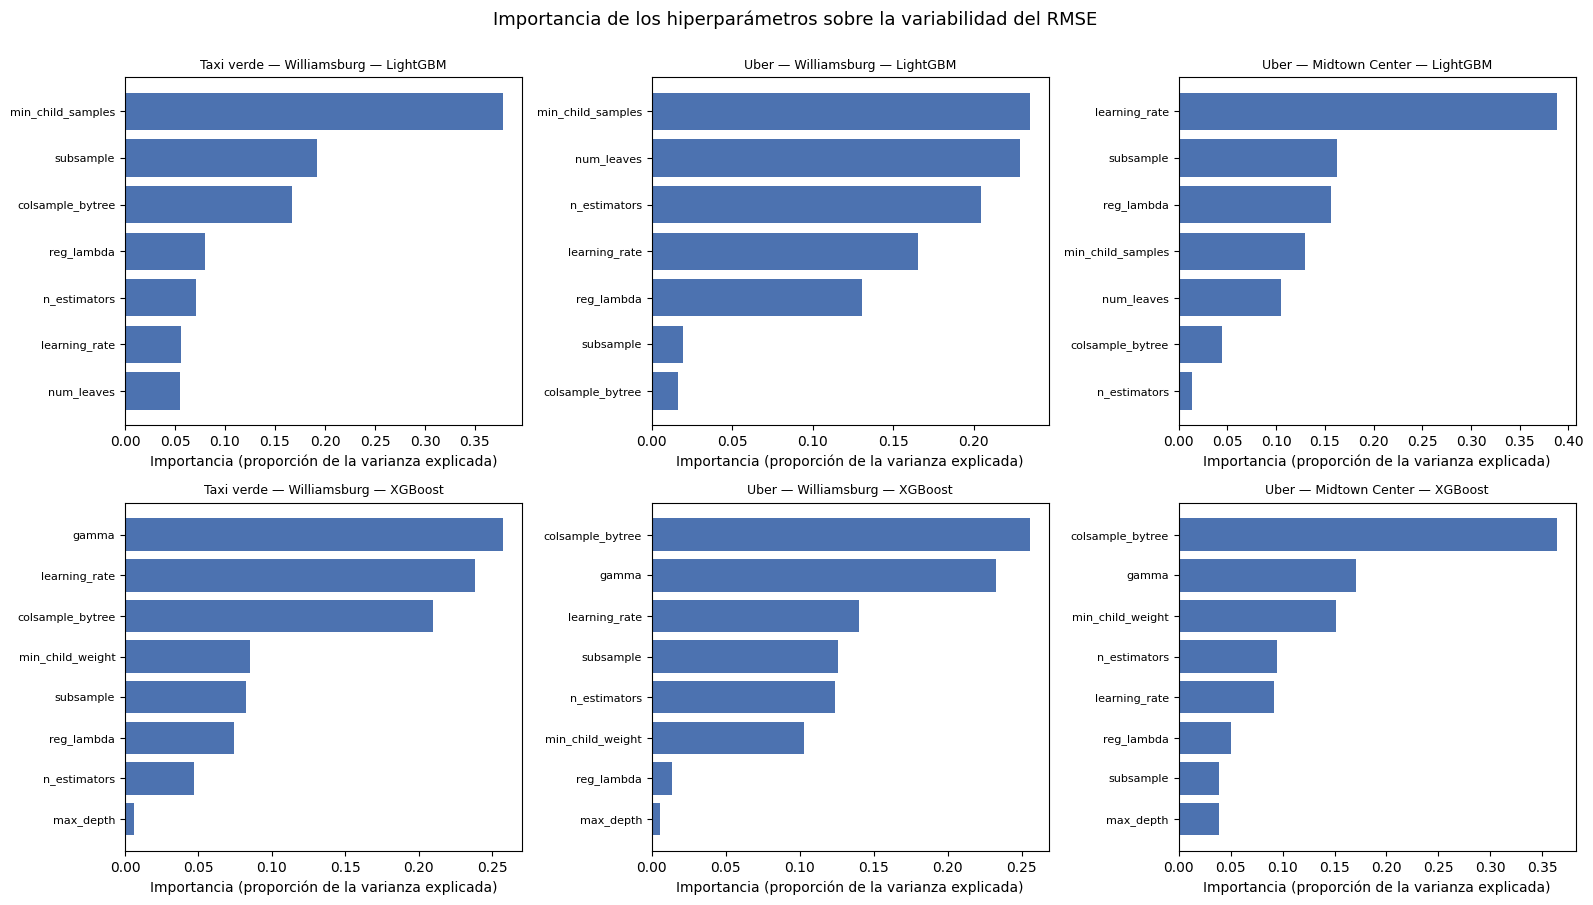

Importancia media de cada hiperparámetro (promedio de las tres series):
Modelo             LightGBM  XGBoost
Hiperparámetro                      
min_child_samples     0.247      NaN
learning_rate         0.203    0.157
num_leaves            0.130      NaN
subsample             0.125    0.082
reg_lambda            0.123    0.046
n_estimators          0.097    0.088
colsample_bytree      0.076    0.276
gamma                   NaN    0.220
max_depth               NaN    0.017
min_child_weight        NaN    0.113


In [99]:
# ── Gráfico. Importancia de los hiperparámetros ──────────────────────────────
def importancia_hiperparametros(estudio):
    """Importancia de cada hiperparámetro según el evaluador por defecto de Optuna.

    Mide qué proporción de la variabilidad del RMSE entre trials explica cada
    hiperparámetro. No indica en qué dirección conviene moverlo.
    """
    try:
        return pd.Series(optuna.importance.get_param_importances(estudio))
    except Exception as error:
        print(f'  [aviso] no se pudo calcular la importancia: {type(error).__name__}')
        return pd.Series(dtype=float)


filas_importancia_hp = []

fig, axes = plt.subplots(len(MODELOS_ML), len(datos_ml),
                         figsize=(16, 4.5 * len(MODELOS_ML)))
axes = np.atleast_2d(axes)
fig.suptitle('Importancia de los hiperparámetros sobre la variabilidad del RMSE',
             fontsize=13, y=1.0)

for i, nombre_modelo in enumerate(MODELOS_ML):
    for j, serie in enumerate(datos_ml):
        ax = axes[i, j]
        estudio = estudios_optuna.get((serie, nombre_modelo))
        if estudio is None:
            ax.axis('off')
            continue

        importancias = importancia_hiperparametros(estudio).sort_values()
        if importancias.empty:
            ax.axis('off')
            continue

        ax.barh(importancias.index, importancias.values, color='#4C72B0')
        ax.set_title(f'{COLUMNAS_ORIGINALES[serie]} — {nombre_modelo}', fontsize=9)
        ax.set_xlabel('Importancia (proporción de la varianza explicada)')
        ax.tick_params(axis='y', labelsize=8)

        for hiperparametro, valor in importancias.items():
            filas_importancia_hp.append({
                'Serie': COLUMNAS_ORIGINALES[serie],
                'Modelo': nombre_modelo,
                'Hiperparámetro': hiperparametro,
                'Importancia': round(float(valor), 4),
            })

plt.tight_layout()
plt.show()

importancias_hp = pd.DataFrame(filas_importancia_hp)

# Resumen: importancia media de cada hiperparámetro por modelo
resumen_hp = (importancias_hp
              .pivot_table(index='Hiperparámetro', columns='Modelo',
                           values='Importancia', aggfunc='mean')
              .sort_values(MODELOS_ML[0], ascending=False)
              .round(3))
print('Importancia media de cada hiperparámetro (promedio de las tres series):')
print(resumen_hp.to_string())

### 9.6. Validación cruzada temporal

Para que el `RMSE_CV` sea comparable entre los tres enfoques, la validación cruzada usa exactamente
las mismas ventanas que la del LSTM, siguiendo la convención de `cross_validation` de
NeuralForecast:

| Parámetro | Valor | Equivalencia con el LSTM |
|-----------|-------|--------------------------|
| `n_windows` | 5 | `N_WINDOWS_LSTM_CV = 5` |
| `step_size` | 30 | `STEP_SIZE_LSTM_CV = 30` |
| horizonte | 31 | `LSTM_HORIZONTE = 31` |
| reentrenamiento | en cada ventana | `refit=True` |

La última ventana termina en el último día de entrenamiento y cada ventana previa se desplaza 30
días hacia atrás; el entrenamiento es expansivo, es decir, cada ventana usa toda la historia
anterior a su punto de corte. Dentro de cada ventana el pronóstico de los 31 días es recursivo,
igual que en el test.

Si la sección del LSTM ya fue ejecutada, la celda **verifica** que los puntos de corte coincidan con
los que efectivamente usó NeuralForecast, en lugar de asumirlo.

In [100]:
ML_CV_DIR = DATA_DIR / 'ml_cv'
ML_CV_DIR.mkdir(parents=True, exist_ok=True)
RUTA_CV_ML = ML_CV_DIR / 'cv_ml.csv'

FORZAR_RECALCULO_CV_ML = False


def validacion_cruzada_ml(serie, nombre_modelo, cortes, h=HORIZONTE_TEST):
    """Recorre las ventanas: reentrena sobre la historia previa al corte y pronostica h días."""
    datos = datos_ml[serie]
    feats = construir_features_ml(serie)
    filas = []

    for corte in cortes:
        entrenamiento = feats[feats.index <= corte].dropna()
        fechas = pd.date_range(corte + pd.Timedelta(days=1), periods=h, freq='D')
        fechas = fechas.intersection(feats.index)
        if len(fechas) == 0 or entrenamiento.empty:
            continue

        modelo = entrenar_modelo_ml(nombre_modelo,
                                    entrenamiento.drop(columns='target'),
                                    entrenamiento['target'],
                                    serie=serie)

        pred = pronostico_recursivo(modelo, datos['serie_completa'].loc[:corte], fechas)
        pred_dolares = np.clip(destransformar_ml(serie, pred.values), 0, None)

        filas.append(pd.DataFrame({
            'Serie': datos['titulo'],
            'Modelo': nombre_modelo,
            'cutoff': corte,
            'ds': fechas,
            'y': df.loc[fechas, serie].values,     # real en dólares
            'pred': pred_dolares,
        }))

    return pd.concat(filas, ignore_index=True) if filas else pd.DataFrame()


if RUTA_CV_ML.exists() and not FORZAR_RECALCULO_CV_ML:
    print(f'\nCargando CV cacheada desde {RUTA_CV_ML.name} ...')
    cv_df_ml = pd.read_csv(RUTA_CV_ML, parse_dates=['ds', 'cutoff'])
    print(f'✓ CV cargada: {cv_df_ml.shape[0]} predicciones')
else:
    print('\nCorriendo validación cruzada (reentrenamiento en cada ventana) ...')
    cv_df_ml = pd.concat(
        [validacion_cruzada_ml(serie, nombre, CORTES_CV)
         for serie in datos_ml for nombre in MODELOS_ML],
        ignore_index=True
    )
    cv_df_ml.to_csv(RUTA_CV_ML, index=False)
    print(f'✓ CV completada y guardada → {RUTA_CV_ML.name}')
    print(f'  Total predicciones: {cv_df_ml.shape[0]}')

cv_df_ml.head(4)


Cargando CV cacheada desde cv_ml.csv ...
✓ CV cargada: 930 predicciones


,Serie,Modelo,cutoff,ds,y,pred
0,Taxi verde — Williamsburg,LightGBM,2025-11-30,2025-12-01,0.00,75.639560
1,Taxi verde — Williamsburg,LightGBM,2025-11-30,2025-12-02,37.83,64.814488
2,Taxi verde — Williamsburg,LightGBM,2025-11-30,2025-12-03,40.67,97.533833
3,Taxi verde — Williamsburg,LightGBM,2025-11-30,2025-12-04,0.00,107.596996


In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error


def mape_safe(y_true, y_pred, eps=1.0):
    """MAPE excluyendo observaciones con |y_true| < eps (evita div/0 con ceros).

    Misma definición que en la sección de LSTM, para que las métricas sean comparables.
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask = np.abs(y_true) >= eps
    if mask.sum() == 0:
        return np.nan
    return 100.0 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


resultados_cv_ml = []
for (titulo, nombre), grupo in cv_df_ml.groupby(['Serie', 'Modelo'], sort=False):
    grupo = grupo.dropna(subset=['y', 'pred'])

    # RMSE calculado por separado en cada ventana: su dispersión indica cuánta
    # diferencia entre modelos es atribuible al ruido de la evaluación.
    rmse_por_ventana = grupo.groupby('cutoff').apply(
        lambda v: rmse(v['y'], v['pred']), include_groups=False)

    resultados_cv_ml.append({
        'Serie': titulo,
        'Modelo': nombre,
        # Agrupado sobre todas las predicciones: es el comparable con el LSTM
        'RMSE medio': round(float(rmse_por_ventana.mean()), 2),
        'RMSE desvío': round(float(rmse_por_ventana.std(ddof=1)), 2),
        'RMSE mín': round(float(rmse_por_ventana.min()), 2),
        'RMSE máx': round(float(rmse_por_ventana.max()), 2),
        'CV %': round(100 * float(rmse_por_ventana.std(ddof=1) / rmse_por_ventana.mean()), 1),
        'N_pred_CV': len(grupo),
        'N_ventanas': len(rmse_por_ventana),
    })

df_cv_ml = pd.DataFrame(resultados_cv_ml)

# Las columnas de conteo son idénticas en todas las filas: van al subtítulo
_n_pred = df_cv_ml['N_pred_CV'].iloc[0]
_n_ventanas = df_cv_ml['N_ventanas'].iloc[0]

(
    GT(df_cv_ml.drop(columns=['RMSE mín', 'RMSE máx', 'N_pred_CV', 'N_ventanas']),
       rowname_col='Modelo', groupname_col='Serie')
    .tab_header(
        title='Tabla 6. Validación cruzada temporal — LightGBM / XGBoost',
    )
    .fmt_number(columns=['RMSE medio', 'RMSE desvío'],
                decimals=0, use_seps=True)
    .fmt_number(columns=['CV %', 'MAPE_CV%'], decimals=1)
    .cols_label(**{
        'RMSE medio': md('RMSE medio<br>por ventana'),
        'RMSE desvío': md('Desvío<br>entre ventanas'),
        'CV %': md('Coef. de<br>variación (%)'),
    })
    # Se resalta la dispersión alta: por encima del 15% las diferencias entre
    # modelos de una misma serie no son distinguibles del ruido.
    .tab_style(style=style.fill(color='#fdecea'),
               locations=loc.body(columns='CV %', rows=lambda d: d['CV %'] > 15))
    .tab_source_note('Coeficiente de variación = desvío / media.')
    .tab_options(table_font_size='13px', table_font_names='Arial')
)

NameError: name 'cv_df_ml' is not defined

In [102]:
# ── Detalle ventana por ventana ─────────────────────────────────────────────
detalle_ventanas = (cv_df_ml.dropna(subset=['y', 'pred'])
                    .groupby(['Serie', 'Modelo', 'cutoff'])
                    .apply(lambda v: rmse(v['y'], v['pred']), include_groups=False)
                    .rename('RMSE').reset_index())

# Cada ventana se identifica por su primer día pronosticado. No se usa el nombre
# del mes porque las ventanas no coinciden con meses calendario y dos de ellas
# caerían bajo la misma etiqueta.
detalle_ventanas['Ventana'] = (detalle_ventanas['cutoff'] + pd.Timedelta(days=1)
                               ).dt.strftime('%d/%m/%y')

tabla_detalle = (detalle_ventanas
                 .pivot_table(index=['Serie', 'Modelo'], columns='Ventana',
                              values='RMSE', sort=False)
                 .reset_index())
tabla_detalle = tabla_detalle[['Serie', 'Modelo'] + list(
    detalle_ventanas['Ventana'].drop_duplicates())]

_columnas_ventana = [c for c in tabla_detalle.columns if c not in ('Serie', 'Modelo')]

(
    GT(tabla_detalle, rowname_col='Modelo', groupname_col='Serie')
    .tab_header(
        title='Tabla 7. RMSE por ventana de validación cruzada',
    )
    .fmt_number(columns=_columnas_ventana, decimals=0, use_seps=True)
    .tab_source_note(f'Cada columna se identifica por el primer día que pronostica y cubre '
                     f'{HORIZONTE_TEST} días. Permite identificar si el error se reparte entre '
                     f'ventanas o si algún período concentra el desvío.')
    .tab_options(table_font_size='13px', table_font_names='Arial')
)

GT(_tbl_data=Ventana                      Serie    Modelo       01/12/25      31/12/25  \
0        Taxi verde — Williamsburg  LightGBM     131.517397    279.220421   
1        Taxi verde — Williamsburg   XGBoost     127.524345    256.505600   
2            Uber — Midtown Center  LightGBM  227953.955418  74592.667054   
3            Uber — Midtown Center   XGBoost  161867.474477  73326.811708   
4              Uber — Williamsburg  LightGBM   38659.007044  46590.540931   
5              Uber — Williamsburg   XGBoost   26619.043509  41233.063882   

Ventana      30/01/26      01/03/26      31/03/26  
0          152.179239    151.520064     97.963533  
1          145.445498    144.521038    107.106080  
2        77788.984380  63579.984829  72760.456137  
3        77873.498904  63896.861105  68558.233093  
4        26128.161420  15286.882889  18385.883722  
5        26957.380343  11981.045388  14213.336569  , _body=<great_tables._gt_data.Body object at 0x7b7ce895fd90>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.row_group: 3>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Modelo', type=<ColInfoTypeEnum.stub: 2>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='01/12/25', type=<ColInfoTypeEnum.default: 1>, column_label='01/12/25', column_align='right', column_width=None), ColInfo(var='31/12/25', type=<ColInfoTypeEnum.default: 1>, column_label='31/12/25', column_align='right', column_width=None), ColInfo(var='30/01/26', type=<ColInfoTypeEnum.default: 1>, column_label='30/01/26', column_align='right', column_width=None), ColInfo(var='01/03/26', type=<ColInfoTypeEnum.default: 1>, column_label='01/03/26', column_align='right', column_width=None), ColInfo(var='31/03/26', type=<ColInfoTypeEnum.default: 1>, column_label='31/03/26', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7b7ce8941a30>, _spanners=Spanners([]), _heading=Heading(title='Tabla 7. RMSE por ventana de validación cruzada', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7b7ce8942510>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7b7ce8942210>, _source_notes=['Cada columna se identifica por el primer día que pronostica y cubre 31 días. Permite identificar si el error se reparte entre ventanas o si algún período concentra el desvío.'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7b7ce89349b0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7b7d7b1fe9f0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['Arial']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='13px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=Opt

### 9.7. Evaluación en test — Mayo 2026

Cada modelo se reentrena sobre todo el conjunto de entrenamiento (hasta el 30 de abril de 2026
inclusive) y pronostica los 31 días de mayo de forma recursiva. Las predicciones se llevan a
dólares y se truncan en cero, dado que no existen ingresos negativos — el mismo tratamiento que
recibe la salida del LSTM.

In [103]:
modelos_finales_ml = {}      # (serie, modelo) -> modelo entrenado sobre todo el train
predicciones_ml = {}         # (serie, modelo) -> Serie de predicciones en dólares

print('Entrenando modelos finales y pronosticando mayo 2026 ...\n')

for serie, datos in datos_ml.items():
    for nombre in MODELOS_ML:
        modelo = entrenar_modelo_ml(nombre, datos['X_train'], datos['y_train'], serie=serie)
        modelos_finales_ml[(serie, nombre)] = modelo

        pred = pronostico_recursivo(
            modelo,
            datos['serie_completa'].loc[:datos['y_train'].index.max()],
            datos['fechas_test'],
        )
        pred_dolares = pd.Series(
            np.clip(destransformar_ml(serie, pred.values), 0, None),
            index=datos['fechas_test'],
        )
        predicciones_ml[(serie, nombre)] = pred_dolares

        print(f'  {datos["titulo"]:28s} {nombre:10s}: '
              f'{len(pred_dolares)} días pronosticados | '
              f'media ${pred_dolares.mean():,.0f}')

# Formato largo, equivalente a pred_lstm_test
pred_ml_test = pd.concat([
    pd.DataFrame({
        'Serie': datos_ml[serie]['titulo'],
        'Modelo': nombre,
        'ds': pred.index,
        'pred': pred.values,
    })
    for (serie, nombre), pred in predicciones_ml.items()
], ignore_index=True)

print(f'\n✓ Predicciones generadas: {pred_ml_test.shape}')
pred_ml_test.head(4)

Entrenando modelos finales y pronosticando mayo 2026 ...

  Taxi verde — Williamsburg    LightGBM  : 31 días pronosticados | media $202
  Taxi verde — Williamsburg    XGBoost   : 31 días pronosticados | media $181
  Uber — Williamsburg          LightGBM  : 31 días pronosticados | media $162,632
  Uber — Williamsburg          XGBoost   : 31 días pronosticados | media $162,385
  Uber — Midtown Center        LightGBM  : 31 días pronosticados | media $358,515
  Uber — Midtown Center        XGBoost   : 31 días pronosticados | media $355,986

✓ Predicciones generadas: (186, 4)


,Serie,Modelo,ds,pred
0,Taxi verde — Williamsburg,LightGBM,2026-05-01,135.547376
1,Taxi verde — Williamsburg,LightGBM,2026-05-02,622.800622
2,Taxi verde — Williamsburg,LightGBM,2026-05-03,443.723492
3,Taxi verde — Williamsburg,LightGBM,2026-05-04,18.602574


In [104]:
resultados_test_ml = []

for (serie, nombre), pred in predicciones_ml.items():
    datos = datos_ml[serie]
    y_true = datos['y_test'].values
    y_pred = pred.values

    fila_cv = df_cv_ml[(df_cv_ml['Serie'] == datos['titulo']) & (df_cv_ml['Modelo'] == nombre)]
    rmse_medio_cv = float(fila_cv['RMSE medio'].values[0])
    desvio_cv = float(fila_cv['RMSE desvío'].values[0])

    rmse_test = rmse(y_true, y_pred)

    resultados_test_ml.append({
        'Serie': datos['titulo'],
        'Modelo': nombre,
        'RMSE medio CV': round(rmse_medio_cv, 2),
        'RMSE desvío CV': round(desvio_cv, 2),
        'RMSE test': round(rmse_test, 2),
        'MAE test': round(float(mean_absolute_error(y_true, y_pred)), 2),
        'MAPE% test': round(float(mape_safe(y_true, y_pred)), 2),
    })

df_resultados_ml = pd.DataFrame(resultados_test_ml)

(
    GT(df_resultados_ml, rowname_col='Modelo', groupname_col='Serie')
    .tab_header(
        title='Tabla 8. Evaluación en test — LightGBM / XGBoost',
        subtitle=f'Test: mayo 2026 ({HORIZONTE_TEST} días) | RMSE y MAE en dólares'
    )
    .fmt_number(columns=['RMSE medio CV', 'RMSE desvío CV', 'RMSE test', 'MAE test'],
                decimals=0, use_seps=True)
    .fmt_number(columns=['MAPE% test'], decimals=1)
    .fmt_number(columns=['Desvíos'], decimals=2)
    .cols_label(**{
        'RMSE medio CV': md('RMSE medio<br>en validación'),
        'RMSE desvío CV': md('Desvío entre<br>ventanas'),
        'RMSE test': md('RMSE<br>test'),
        'MAE test': md('MAE<br>test'),
        'MAPE% test': md('MAPE<br>(%)'),
    })
    .tab_options(table_font_size='13px', table_font_names='Arial')
)

GT(_tbl_data=                       Serie    Modelo  RMSE medio CV  RMSE desvío CV  \
0  Taxi verde — Williamsburg  LightGBM         162.48           68.88   
1  Taxi verde — Williamsburg   XGBoost         156.22           58.19   
2        Uber — Williamsburg  LightGBM       29010.10        13338.66   
3        Uber — Williamsburg   XGBoost       24200.77        11753.90   
4      Uber — Midtown Center  LightGBM      103335.21        69863.92   
5      Uber — Midtown Center   XGBoost       89104.58        41009.44   

   RMSE test  MAE test  MAPE% test  
0     115.63     79.17       70.74  
1      98.98     61.66       40.33  
2   23963.64  17541.17        9.64  
3   21790.16  16154.10        9.21  
4   80776.22  56995.53       15.85  
5   71224.42  49393.66       14.09  , _body=<great_tables._gt_data.Body object at 0x7b7ce87a2a30>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.row_group: 3>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Modelo', type=<ColInfoTypeEnum.stub: 2>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='RMSE medio CV', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='RMSE medio<br>en validación'), column_align='right', column_width=None), ColInfo(var='RMSE desvío CV', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='Desvío entre<br>ventanas'), column_align='right', column_width=None), ColInfo(var='RMSE test', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='RMSE<br>test'), column_align='right', column_width=None), ColInfo(var='MAE test', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='MAE<br>test'), column_align='right', column_width=None), ColInfo(var='MAPE% test', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='MAPE<br>(%)'), column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7b7ce8993350>, _spanners=Spanners([]), _heading=Heading(title='Tabla 8. Evaluación en test — LightGBM / XGBoost', subtitle='Test: mayo 2026 (31 días) | RMSE y MAE en dólares', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7b7ce87a8710>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7b7ce87a8770>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7b7ce8935ef0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7b7ce87b4550>, <great_tables._gt_data.FormatInfo object at 0x7b7ce8989fd0>, <great_tables._gt_data.FormatInfo object at 0x7b7ce88afe70>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['Arial']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='13px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table

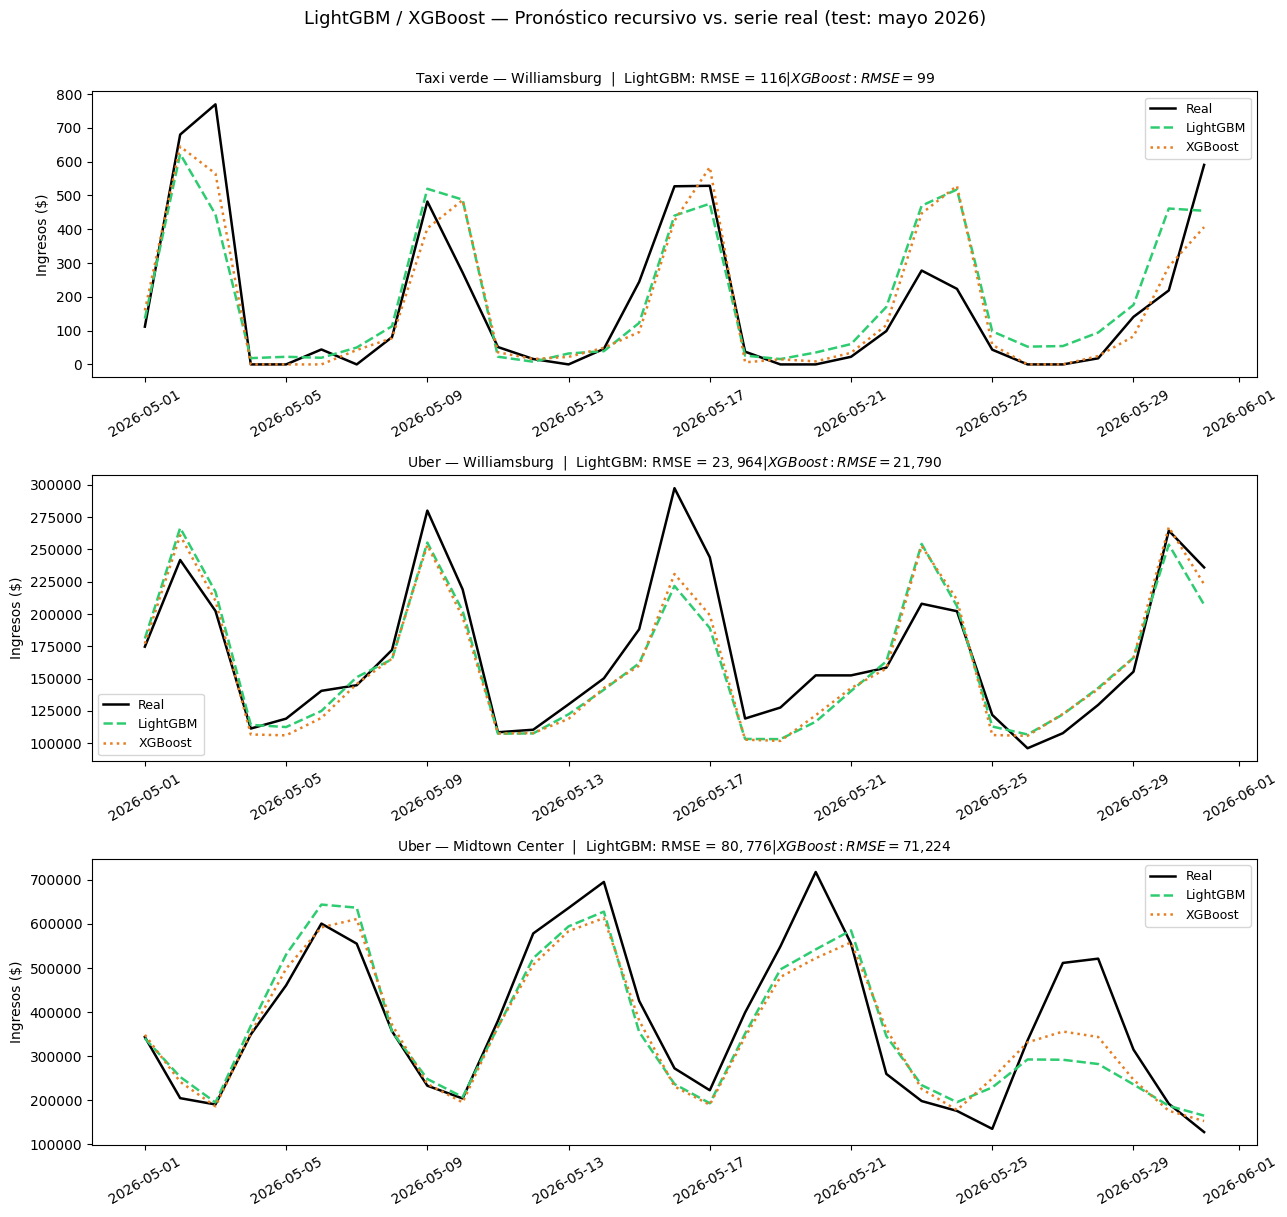

In [105]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12))
fig.suptitle('LightGBM / XGBoost — Pronóstico recursivo vs. serie real (test: mayo 2026)',
             fontsize=13, y=1.01)

ESTILOS_ML = {'LightGBM': ('#2ecc71', '--'), 'XGBoost': ('#e67e22', ':')}

for ax, (serie, datos) in zip(axes, datos_ml.items()):
    real = datos['y_test']
    ax.plot(real.index, real.values, label='Real', color='black', lw=1.8)

    etiquetas = []
    for nombre in MODELOS_ML:
        pred = predicciones_ml[(serie, nombre)]
        color, estilo = ESTILOS_ML[nombre]
        ax.plot(pred.index, pred.values, label=nombre, color=color, lw=1.8, linestyle=estilo)

        rmse_disp = np.sqrt(mean_squared_error(real.values, pred.values))
        etiquetas.append(f'{nombre}: RMSE = ${rmse_disp:,.0f}')

    ax.set_title(f'{datos["titulo"]}  |  ' + '  |  '.join(etiquetas), fontsize=10)
    ax.set_ylabel('Ingresos ($)')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 9.8. Importancia de variables

Se analiza la importancia de las variables del modelo ganador de cada serie, entendiendo por tal
el que obtuvo el menor valor de la función objetivo en la búsqueda de hiperparámetros.

La métrica utilizada es la **ganancia**: la mejora total de la función de pérdida aportada por
todos los cortes en los que participa cada variable. Se fuerza esa métrica en ambas librerías
porque sus valores por defecto no son comparables entre sí —LightGBM informa la cantidad de cortes
y XGBoost la ganancia—, de modo que usar los valores por defecto haría que los dos modelos no se
pudieran contrastar.

Tres advertencias sobre la lectura de estos resultados. Primero, la importancia por ganancia se
calcula sobre el conjunto de entrenamiento y refleja el uso que el modelo hizo de cada variable,
no su capacidad predictiva fuera de muestra. Segundo, cuando dos variables están correlacionadas
—como ocurre entre `weekofyear`, `month` y `quarter`— el modelo reparte la ganancia entre ellas de
forma arbitraria, por lo que una importancia baja no implica que la variable sea irrelevante.
Tercero, la importancia no es una medida causal: indica qué variables usó el modelo para dividir
las observaciones, no qué factores determinan los ingresos.

La agregación por familia de variables permite además contrastar empíricamente las decisiones de
construcción del conjunto de datos: cuánto aportan efectivamente los rezagos, los estadísticos de
ventana móvil y las variables de calendario.

In [106]:
# ── Importancia de variables de ambos modelos ────────────────────────────────
def mejor_modelo_de(serie):
    """Modelo ganador de una serie: menor valor objetivo de Optuna, o menor RMSE medio."""
    estudios = globals().get('estudios_optuna', {})
    candidatos = {m: estudios[(serie, m)].best_value
                  for m in MODELOS_ML if (serie, m) in estudios}
    if candidatos:
        return min(candidatos, key=candidatos.get)

    # Si no se corrió Optuna, se decide por el RMSE medio de validación cruzada
    sub = df_cv_ml[df_cv_ml['Serie'] == COLUMNAS_ORIGINALES[serie]]
    return sub.loc[sub['RMSE medio'].idxmin(), 'Modelo']


def grupo_de(variable):
    """Familia de variables a la que pertenece cada feature (secciones 6 y 7)."""
    if variable.startswith('lag_'):
        return 'Rezagos'
    if variable.startswith('rolling_'):
        return 'Ventanas móviles'
    return 'Calendario'


def importancia_por_ganancia(nombre_modelo, modelo, columnas=None):
    """Importancia por ganancia, normalizada a porcentaje.

    Se fuerza 'gain' en ambas librerías —la mejora total de la función de pérdida
    aportada por los cortes de cada variable— porque los valores por defecto no son
    comparables entre sí: LightGBM informa 'split' (cantidad de cortes en los que
    participa la variable) y XGBoost informa 'gain'.
    """
    columnas = columnas if columnas is not None else COLUMNAS_FEATURES

    if nombre_modelo == 'LightGBM':
        importancias = pd.Series(
            modelo.booster_.feature_importance(importance_type='gain'),
            index=modelo.booster_.feature_name(),
        )
    else:
        # get_score omite las variables que nunca se usaron: se completan con 0
        importancias = pd.Series(
            modelo.get_booster().get_score(importance_type='gain'), dtype=float)

    importancias = importancias.reindex(columnas).fillna(0.0)
    total = importancias.sum()
    return 100 * importancias / total if total else importancias


MEJOR_MODELO_POR_SERIE = {serie: mejor_modelo_de(serie) for serie in datos_ml}

# Ahora se recorren las dos familias de modelos, no solo la ganadora
filas_importancia = []
for serie in datos_ml:
    for nombre_modelo in MODELOS_ML:
        modelo = modelos_finales_ml.get((serie, nombre_modelo))
        if modelo is None:
            continue

        for variable, valor in importancia_por_ganancia(nombre_modelo, modelo).items():
            filas_importancia.append({
                'Serie': COLUMNAS_ORIGINALES[serie],
                'Modelo': nombre_modelo,
                'Grupo': grupo_de(variable),
                'Variable': variable,
                'Importancia %': round(float(valor), 2),
            })

importancias_ml = pd.DataFrame(filas_importancia)

print('Modelo ganador por serie:')
for serie, nombre_modelo in MEJOR_MODELO_POR_SERIE.items():
    print(f'  {COLUMNAS_ORIGINALES[serie]:28s}: {nombre_modelo}')

# ── Agregación por familia de variables ──────────────────────────────────────
importancia_por_grupo = (
    importancias_ml
    .groupby(['Serie', 'Modelo', 'Grupo'], as_index=False)['Importancia %'].sum()
    .pivot(index=['Serie', 'Modelo'], columns='Grupo', values='Importancia %')
    .reset_index()
    .round(1)
)

# Marca del modelo elegido en cada serie
_ganadores = {COLUMNAS_ORIGINALES[s]: m for s, m in MEJOR_MODELO_POR_SERIE.items()}
importancia_por_grupo['Elegido'] = [
    '✓' if _ganadores.get(fila['Serie']) == fila['Modelo'] else ''
    for _, fila in importancia_por_grupo.iterrows()
]

_columnas_grupo = [c for c in importancia_por_grupo.columns
                   if c not in ('Serie', 'Modelo', 'Elegido')]

display(
    GT(importancia_por_grupo[['Serie', 'Modelo', 'Elegido'] + _columnas_grupo],
       rowname_col='Modelo', groupname_col='Serie')
    .tab_header(
        title='Tabla 9. Importancia de variables por familia',
        subtitle='Ganancia acumulada (%) sobre el conjunto de entrenamiento completo'
    )
    .fmt_number(columns=_columnas_grupo, decimals=1)
    .cols_label(Elegido=md('Modelo<br>elegido'))
    .tab_source_note('Cada fila suma 100%. La ganancia mide la mejora de la función de '
                     'pérdida aportada por los cortes de cada variable, y se calcula sobre '
                     'el conjunto de entrenamiento.')
    .tab_source_note('El modelo marcado es el de menor error en la búsqueda de '
                     'hiperparámetros; se informan ambos para contrastar si las dos familias '
                     'se apoyan en el mismo tipo de información.')
    .tab_options(table_font_size='13px', table_font_names='Arial')
)

Modelo ganador por serie:
  Taxi verde — Williamsburg   : LightGBM
  Uber — Williamsburg         : XGBoost
  Uber — Midtown Center       : XGBoost


GT(_tbl_data=Grupo                      Serie    Modelo Elegido  Calendario  Rezagos  \
0      Taxi verde — Williamsburg  LightGBM       ✓        61.4     22.6   
1      Taxi verde — Williamsburg   XGBoost                74.0     17.5   
2          Uber — Midtown Center  LightGBM                24.5     67.3   
3          Uber — Midtown Center   XGBoost       ✓        38.2     50.5   
4            Uber — Williamsburg  LightGBM                61.0     33.0   
5            Uber — Williamsburg   XGBoost       ✓        77.8     15.5   

Grupo  Ventanas móviles  
0                  16.0  
1                   8.5  
2                   8.2  
3                  11.3  
4                   6.0  
5                   6.7  , _body=<great_tables._gt_data.Body object at 0x7b7ce877eda0>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.row_group: 3>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Modelo', type=<ColInfoTypeEnum.stub: 2>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='Elegido', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='Modelo<br>elegido'), column_align='left', column_width=None), ColInfo(var='Calendario', type=<ColInfoTypeEnum.default: 1>, column_label='Calendario', column_align='right', column_width=None), ColInfo(var='Rezagos', type=<ColInfoTypeEnum.default: 1>, column_label='Rezagos', column_align='right', column_width=None), ColInfo(var='Ventanas móviles', type=<ColInfoTypeEnum.default: 1>, column_label='Ventanas móviles', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7b7ce86049b0>, _spanners=Spanners([]), _heading=Heading(title='Tabla 9. Importancia de variables por familia', subtitle='Ganancia acumulada (%) sobre el conjunto de entrenamiento completo', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7b7ce8605b50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7b7ce86059d0>, _source_notes=['Cada fila suma 100%. La ganancia mide la mejora de la función de pérdida aportada por los cortes de cada variable, y se calcula sobre el conjunto de entrenamiento.', 'El modelo marcado es el de menor error en la búsqueda de hiperparámetros; se informan ambos para contrastar si las dos familias se apoyan en el mismo tipo de información.'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7b7d7b0631d0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7b7d7af3c280>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['Arial']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='13px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='soli

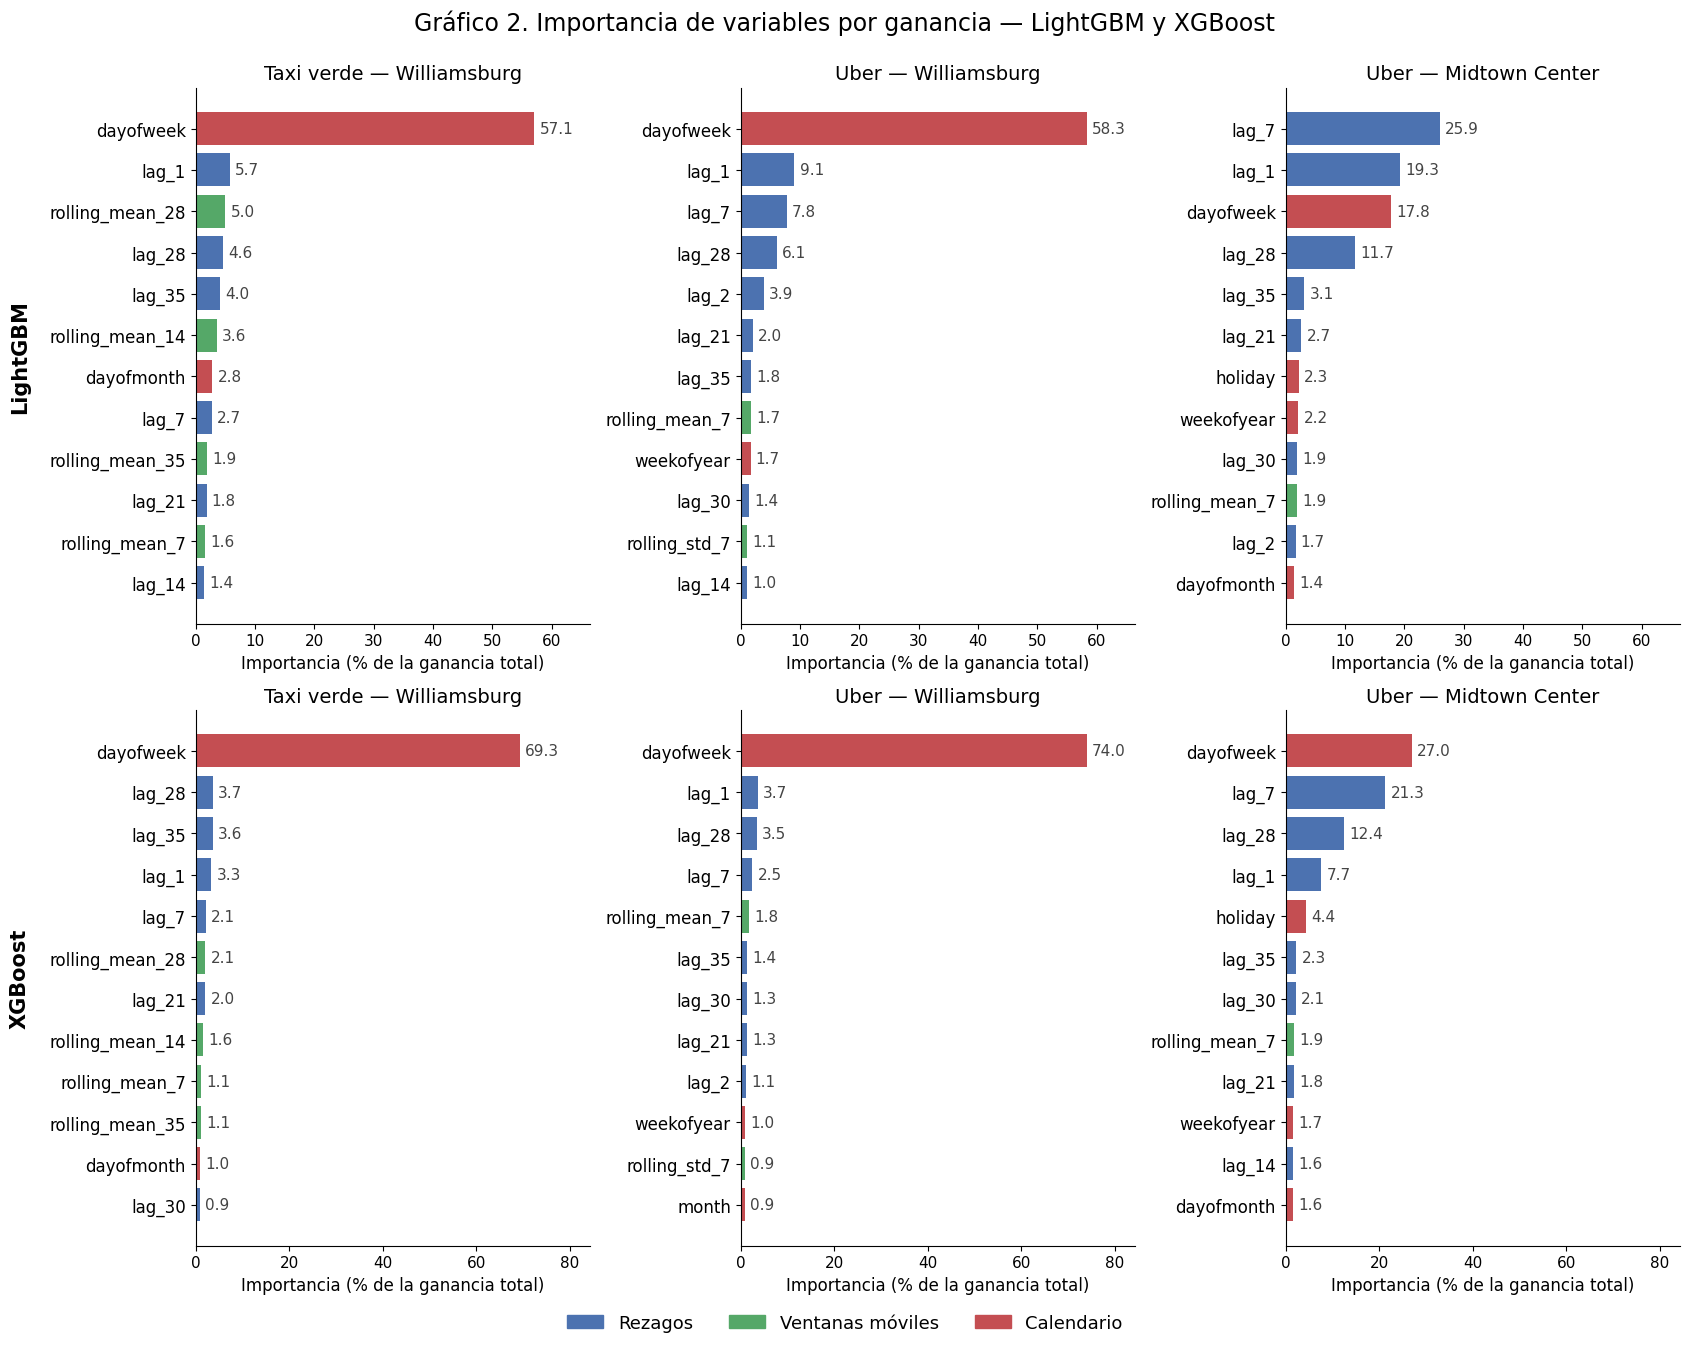

In [107]:
# ── Gráfico. Importancia de variables por modelo y serie ─────────────────────
COLORES_GRUPO = {
    'Rezagos': '#4C72B0',
    'Ventanas móviles': '#55A868',
    'Calendario': '#C44E52',
}
TOP_GRAFICO = 12   # variables mostradas en cada panel

fig, axes = plt.subplots(len(MODELOS_ML), len(datos_ml),
                         figsize=(17, 6.5 * len(MODELOS_ML)))
axes = np.atleast_2d(axes)
fig.suptitle('Gráfico 2. Importancia de variables por ganancia — LightGBM y XGBoost',
             fontsize=17, y=1.0)

for i, nombre_modelo in enumerate(MODELOS_ML):
    # Escala común en toda la fila: hace comparables las tres series de un modelo
    maximo_fila = max(
        importancias_ml[(importancias_ml['Serie'] == COLUMNAS_ORIGINALES[s]) &
                        (importancias_ml['Modelo'] == nombre_modelo)]['Importancia %'].max()
        for s in datos_ml)

    for j, serie in enumerate(datos_ml):
        ax = axes[i, j]
        titulo = COLUMNAS_ORIGINALES[serie]

        sub = (importancias_ml[(importancias_ml['Serie'] == titulo) &
                               (importancias_ml['Modelo'] == nombre_modelo)]
               .nlargest(TOP_GRAFICO, 'Importancia %')
               .sort_values('Importancia %'))

        ax.barh(sub['Variable'], sub['Importancia %'],
                color=[COLORES_GRUPO[g] for g in sub['Grupo']])
        ax.set_xlim(0, maximo_fila * 1.14)

        # Valor al final de cada barra
        for y, valor in zip(sub['Variable'], sub['Importancia %']):
            ax.text(valor + maximo_fila * 0.015, y, f'{valor:.1f}',
                    va='center', fontsize=11, color='#444444')

        ax.set_title(titulo, fontsize=14)
        ax.set_xlabel('Importancia (% de la ganancia total)', fontsize=12)
        ax.tick_params(axis='y', labelsize=12)
        ax.tick_params(axis='x', labelsize=11)
        ax.spines[['top', 'right']].set_visible(False)

    # Nombre del modelo a la izquierda de cada fila
    axes[i, 0].set_ylabel(nombre_modelo, fontsize=15, fontweight='bold', labelpad=14)

manijas = [plt.Rectangle((0, 0), 1, 1, color=color) for color in COLORES_GRUPO.values()]
fig.legend(manijas, COLORES_GRUPO.keys(), loc='lower center', ncol=3,
           frameon=False, fontsize=13, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.show()

### 9.8. Diagnóstico de residuos

Se replica el diagnóstico aplicado al LSTM sobre los residuos del test (31 observaciones por serie y
por modelo):

- **QQ plot**: ¿los residuos siguen una distribución normal?
- **Residuos vs. predicho**: ¿la varianza del error depende del nivel pronosticado?

Como en el caso del LSTM, estos modelos no asumen normalidad de los residuos; el diagnóstico es
orientativo y sirve para detectar sesgos sistemáticos, no para validar supuestos.

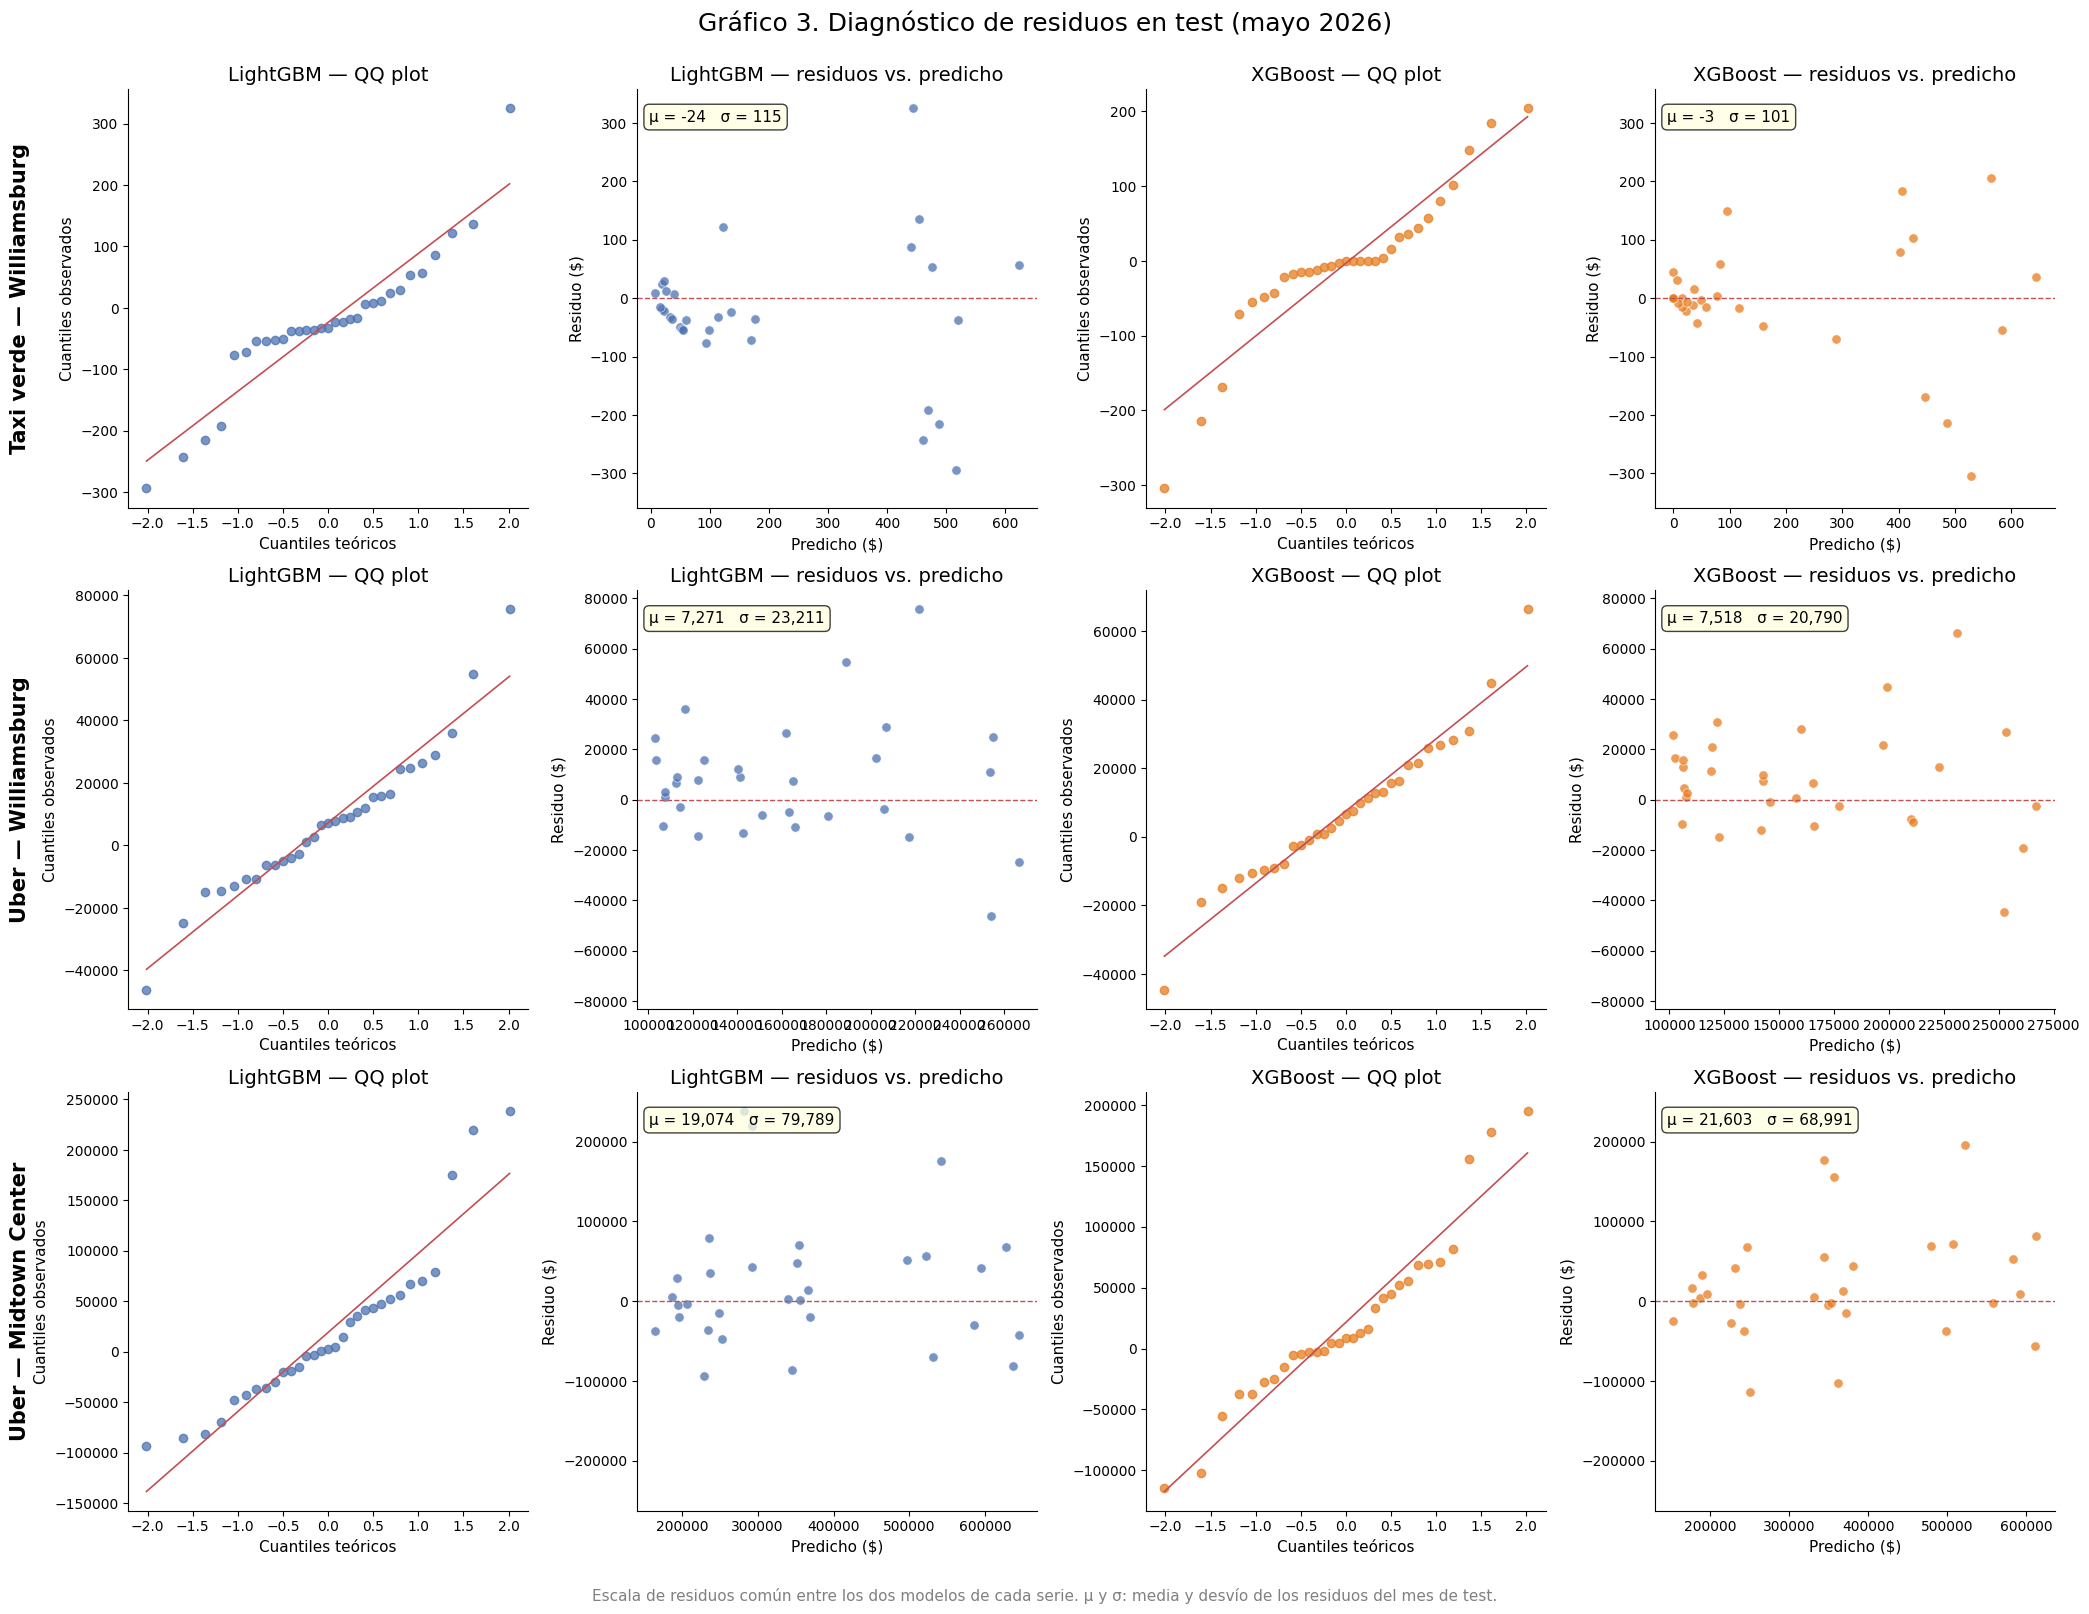

In [108]:
from scipy import stats as scipy_stats

# ── Gráfico. Diagnóstico de residuos: una fila por serie ─────────────────────
COLORES_MODELO = {'LightGBM': '#4C72B0', 'XGBoost': '#E67E22'}

fig, axes = plt.subplots(len(datos_ml), 2 * len(MODELOS_ML),
                         figsize=(21, 5.2 * len(datos_ml)))
axes = np.atleast_2d(axes)
fig.suptitle('Gráfico 3. Diagnóstico de residuos en test (mayo 2026)', fontsize=18, y=1.0)

for i, (serie, datos) in enumerate(datos_ml.items()):
    titulo = datos['titulo']

    # Escala común de residuos entre los dos modelos de la serie
    residuos_serie = {m: (datos['y_test'] - predicciones_ml[(serie, m)]).dropna()
                      for m in MODELOS_ML}
    limite = max(r.abs().max() for r in residuos_serie.values()) * 1.1

    for k, nombre_modelo in enumerate(MODELOS_ML):
        ax_qq, ax_res = axes[i, 2 * k], axes[i, 2 * k + 1]
        pred = predicciones_ml[(serie, nombre_modelo)]
        residuos = residuos_serie[nombre_modelo]
        color = COLORES_MODELO.get(nombre_modelo, '#4C72B0')

        # ── QQ plot: ¿los residuos siguen una distribución normal? ────────
        scipy_stats.probplot(residuos.values, dist='norm', plot=ax_qq)
        ax_qq.get_lines()[0].set(markersize=6, alpha=0.75, color=color)
        ax_qq.get_lines()[1].set(color='#C44E52', lw=1.2)
        ax_qq.set_title(f'{nombre_modelo} — QQ plot', fontsize=14)
        ax_qq.set_xlabel('Cuantiles teóricos', fontsize=11)
        ax_qq.set_ylabel('Cuantiles observados', fontsize=11)

        # ── Residuos vs. predicho: ¿la varianza depende del nivel? ────────
        ax_res.scatter(pred.values, residuos.values, alpha=0.75, s=45,
                       color=color, edgecolors='white', linewidths=0.5)
        ax_res.axhline(0, color='#C44E52', linestyle='--', lw=1.0)
        ax_res.set_ylim(-limite, limite)
        ax_res.set_title(f'{nombre_modelo} — residuos vs. predicho', fontsize=14)
        ax_res.set_xlabel('Predicho ($)', fontsize=11)
        ax_res.set_ylabel('Residuo ($)', fontsize=11)
        ax_res.annotate(
            f'μ = {residuos.mean():,.0f}   σ = {residuos.std():,.0f}',
            xy=(0.03, 0.95), xycoords='axes fraction', fontsize=11, va='top',
            bbox=dict(boxstyle='round,pad=0.35', facecolor='lightyellow', alpha=0.75),
        )

        for ax in (ax_qq, ax_res):
            ax.tick_params(labelsize=10)
            ax.spines[['top', 'right']].set_visible(False)

# Nombre de la serie a la izquierda de cada fila. Se ancla al eje con un
# desplazamiento en puntos para que no se superponga con la etiqueta del eje y.
for i, (serie, datos) in enumerate(datos_ml.items()):
    axes[i, 0].annotate(datos['titulo'], xy=(0, 0.5), xycoords='axes fraction',
                        xytext=(-78, 0), textcoords='offset points',
                        rotation=90, va='center', ha='center',
                        fontsize=15, fontweight='bold')

plt.tight_layout()
fig.text(0.5, -0.02,
         'Escala de residuos común entre los dos modelos de cada serie. '
         'μ y σ: media y desvío de los residuos del mes de test.',
         ha='center', fontsize=11, color='gray')
plt.show()

In [109]:
# Estructura compatible con df_resultados_lstm, para la sección de comparación final.
RUTA_RESULTADOS_ML = ML_CV_DIR / 'resultados_ml.csv'
df_resultados_ml.to_csv(RUTA_RESULTADOS_ML, index=False)
print(f'✓ Resultados guardados → {RUTA_RESULTADOS_ML.name}')

print('\nResumen final LightGBM / XGBoost:')
print(df_resultados_ml[['Serie', 'Modelo', 'RMSE_CV', 'RMSE', 'MAE', 'MAPE%',
                        'gap_CV_test_%']].to_string(index=False))

# Si la sección de LSTM ya corrió, se muestran las tres familias juntas
if 'df_resultados_lstm' in globals():
    comparacion = pd.concat([df_resultados_ml, df_resultados_lstm], ignore_index=True)
    print('\nComparación con el LSTM (mismo test, mismas ventanas de CV, métricas en dólares):')
    print(comparacion.sort_values(['Serie', 'RMSE'])
          [['Serie', 'Modelo', 'RMSE_CV', 'RMSE', 'MAE', 'MAPE%', 'gap_CV_test_%']]
          .to_string(index=False))

print('\nVariables disponibles para la sección de comparación:')
print('  df_resultados_ml   — métricas RMSE/MAE/MAPE en test + RMSE_CV por serie y modelo')
print('  predicciones_ml    — {(serie, modelo): Serie diaria de mayo 2026, en dólares}')
print('  pred_ml_test       — las mismas predicciones en formato largo')
print('  cv_df_ml           — predicciones de todas las ventanas de validación cruzada')

✓ Resultados guardados → resultados_ml.csv

Resumen final LightGBM / XGBoost:


KeyError: "['RMSE_CV', 'RMSE', 'MAE', 'MAPE%', 'gap_CV_test_%'] not in index"

## 10. Modelado con RNN: LSTM

### 10.1. Redes Neuronales — LSTM

Se incorpora una red neuronal recurrente **LSTM** (*Long Short-Term Memory*)
como tercer enfoque de pronóstico, para contrastar con el benchmark
estadístico (SARIMAX) y los ensambles de árboles (LightGBM / XGBoost).

La implementación utiliza la librería **NeuralForecast** (Nixtla), que:
- provee una API unificada y reproducible para modelos de DL en series de tiempo,
- maneja la normalización por serie internamente (`scaler_type='standard'`),
- produce pronósticos **directos** a h pasos (sin acumulación de error recursivo,
  a diferencia de LightGBM/XGBoost), y
- incluye validación cruzada temporal compatible con la usada en el benchmark ML.

El flujo es:
1. Verificación de requisitos previos.
2. Preparación de datos en formato largo (NeuralForecast).
3. Definición y entrenamiento del modelo (sobre todo el conjunto de train).
4. Validación cruzada temporal con 5 ventanas (comparable con `TimeSeriesSplit`
   usado en LightGBM/XGBoost).
5. Evaluación en test (mayo 2026) — mismo horizonte que todos los demás modelos.
6. Diagnóstico de residuos.
7. Guardado de resultados para la tabla de comparación final.

In [110]:
%pip install neuralforecast -q

### 10.2. Verificación de requisitos previos para LSTM

A diferencia de ARIMA/SARIMAX, el LSTM **no exige estacionariedad estricta**:
la normalización interna (StandardScaler por serie) amortigua diferencias de
escala y tendencias suaves, y la red puede aprender representaciones internas
de estructuras no lineales. Sin embargo, conviene diagnosticar:

1. **Suficiencia de datos** — ¿hay suficientes ventanas de entrenamiento?
2. **Valores faltantes y ceros** — impactan en la normalización y la pérdida.
3. **Estacionariedad (ADF + KPSS)** — referencia informativa; se documenta
   para comparar con el tratamiento dado al SARIMAX.
4. **Autocorrelación** — justifica usar un modelo con memoria temporal.

In [111]:
from statsmodels.tsa.stattools import adfuller, kpss

# Parámetro que se reutiliza más adelante
LSTM_INPUT_SIZE = 35   # ventana de contexto: 5 semanas (= max lag en ML)

print("=" * 70)
print("VERIFICACIÓN DE REQUISITOS PREVIOS PARA LSTM")
print("=" * 70)

resultados_prereq_lstm = []

for col, titulo in COLUMNAS_ORIGINALES.items():
    serie = df[col].dropna()
    n = len(serie)

    print(f"\n{'─'*65}")
    print(f"Serie: {titulo}")
    print(f"{'─'*65}")

    # ── 1. Suficiencia de datos ───────────────────────────────────────────
    n_ventanas_train = n - LSTM_INPUT_SIZE
    suficiente = n_ventanas_train >= 100
    print(f"   Suficiencia de datos")
    print(f"   Total de observaciones : {n}")
    print(f"   Input size (lookback)  : {LSTM_INPUT_SIZE} días")
    print(f"   Ventanas disponibles   : {n_ventanas_train}")
    print(f"   {'✓ SUFICIENTE' if suficiente else '✗ INSUFICIENTE'}"
          f"  (mínimo recomendado: 100 ventanas de entrenamiento)")

    # ── 2. Valores faltantes y ceros ─────────────────────────────────────
    n_nan   = serie.isna().sum()
    n_ceros = (serie == 0).sum()
    pct_ceros = 100 * n_ceros / n
    print(f"\n2. Valores faltantes y ceros")
    print(f"   NaN    : {n_nan:>4}  {'✓' if n_nan == 0 else '✗ (hay NaN)'}")
    print(f"   Ceros  : {n_ceros:>4}  ({pct_ceros:.1f}% de la serie)"
          + ("  ⚠ Serie con alta proporción de ceros" if pct_ceros > 15 else ""))

    # ── 3. Test ADF (Augmented Dickey-Fuller) ────────────────────────────
    adf_stat, adf_p, adf_lags, _, _, _ = adfuller(serie, autolag='AIC')
    adf_est = adf_p < 0.05
    print(f"\n3. Test ADF  — H₀: raíz unitaria (no estacionaria)")
    print(f"   Estadístico t : {adf_stat:>9.4f}   "
          f"({'✓ Estacionaria' if adf_est else '⚠ No estacionaria'})")
    print(f"   p-valor       : {adf_p:>9.4f}   Lags auto: {adf_lags}")

    # ── 4. Test KPSS ─────────────────────────────────────────────────────
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kpss_stat, kpss_p, _, _ = kpss(serie, regression='c', nlags='auto')
    kpss_est = kpss_p >= 0.05
    print(f"\n4. Test KPSS — H₀: estacionaria")
    print(f"   Estadístico  : {kpss_stat:>9.4f}   "
          f"({'✓ Estacionaria' if kpss_est else '⚠ No estacionaria'})")
    print(f"   p-valor      : {kpss_p:>9.4f}")

    # ── Diagnóstico conjunto ADF + KPSS ──────────────────────────────────
    if adf_est and kpss_est:
        diag = "Estacionaria (ambos tests coinciden)"
    elif not adf_est and not kpss_est:
        diag = "No estacionaria — NOTA: el LSTM no requiere diferenciación"
    elif adf_est and not kpss_est:
        diag = "Estacionaria en diferencias (KPSS detecta tendencia determinista)"
    else:
        diag = "Estacionaria en tendencia (ADF sugiere tendencia determinista)"
    print(f"\n   ➤ Diagnóstico conjunto: {diag}")

    # ── 5. Autocorrelación (Ljung-Box) ────────────────────────────────────
    from statsmodels.stats.diagnostic import acorr_ljungbox
    lb = acorr_ljungbox(serie, lags=[7, 14, 28], return_df=True)
    rechazados = (lb['lb_pvalue'] < 0.05).sum()
    print(f"\n5. Test de Ljung-Box (lags 7, 14, 28)")
    print(f"   Rechazos H₀ (p<0.05): {rechazados}/3  "
          + ("✓ Hay autocorrelación → LSTM apropiado" if rechazados > 0
             else "⚠ Sin autocorrelación significativa"))

    resultados_prereq_lstm.append({
        'Serie': titulo,
        'N': n,
        'N_ventanas': n_ventanas_train,
        'Ceros (%)': round(pct_ceros, 1),
        'ADF p-val': round(adf_p, 4),
        'ADF estac.': 'Sí' if adf_est else 'No',
        'KPSS p-val': round(kpss_p, 4),
        'KPSS estac.': 'Sí' if kpss_est else 'No',
        'LjungBox rechazos': rechazados,
    })

df_prereq_lstm = pd.DataFrame(resultados_prereq_lstm)
display(df_prereq_lstm.style.set_caption("Tabla de requisitos previos — LSTM"))

VERIFICACIÓN DE REQUISITOS PREVIOS PARA LSTM

─────────────────────────────────────────────────────────────────
Serie: Taxi verde — Williamsburg
─────────────────────────────────────────────────────────────────
   Suficiencia de datos
   Total de observaciones : 730
   Input size (lookback)  : 35 días
   Ventanas disponibles   : 695
   ✓ SUFICIENTE  (mínimo recomendado: 100 ventanas de entrenamiento)

2. Valores faltantes y ceros
   NaN    :    0  ✓
   Ceros  :  161  (22.1% de la serie)  ⚠ Serie con alta proporción de ceros

3. Test ADF  — H₀: raíz unitaria (no estacionaria)
   Estadístico t :   -3.1406   (✓ Estacionaria)
   p-valor       :    0.0237   Lags auto: 20

4. Test KPSS — H₀: estacionaria
   Estadístico  :    0.1459   (✓ Estacionaria)
   p-valor      :    0.1000

   ➤ Diagnóstico conjunto: Estacionaria (ambos tests coinciden)

5. Test de Ljung-Box (lags 7, 14, 28)
   Rechazos H₀ (p<0.05): 3/3  ✓ Hay autocorrelación → LSTM apropiado

───────────────────────────────────────────

/tmp/ipykernel_624/973532692.py:40: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, adf_lags, _, _, _ = adfuller(serie, autolag='AIC')
/tmp/ipykernel_624/973532692.py:40: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, adf_lags, _, _, _ = adfuller(serie, autolag='AIC')
/tmp/ipykernel_624/973532692.py:40: FutureWarning: adfuller currently retu

,Serie,N,N_ventanas,Ceros (%),ADF p-val,ADF estac.,KPSS p-val,KPSS estac.,LjungBox rechazos
0,Taxi verde — Williamsburg,730,695,22.100000,0.023700,Sí,0.100000,Sí,3
1,Uber — Williamsburg,730,695,0.000000,0.000100,Sí,0.100000,Sí,3
2,Uber — Midtown Center,730,695,0.000000,0.000400,Sí,0.011700,No,3


El LSTM no requiere estacionariedad (a diferencia de ARIMA).La normalización interna (scaler_type='standard') maneja la escala.
La presencia de autocorrelación (Ljung-Box) justifica el uso de una arquitectura con memoria temporal explícita.

### 10.3. Preparación de los datos

NeuralForecast requiere los datos en **formato largo** con tres columnas
obligatorias: `unique_id` (identificador de serie), `ds` (fecha) e `y`
(valor objetivo). Las variables exógenas futuras conocidas se agregan como
columnas adicionales y se declaran en `futr_exog_list`.

Se usan las mismas variables de calendario que en LightGBM/XGBoost:
`dayofweek`, `holiday`, `month`, `year`. A diferencia del SARIMAX, aquí
se pueden incluir todas las variables de calendario porque el LSTM no
sufre el problema de multicolinealidad ni la inestabilidad de coeficientes
que motivó reducir las exógenas en el modelo estadístico.

In [112]:
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM as NF_LSTM
from neuralforecast.losses.pytorch import MAE as NF_MAE

# Variables de calendario disponibles en el futuro (exógenas conocidas)
LSTM_FUTR_EXOG = ['dayofweek', 'holiday', 'month', 'year']

# ── Convertir a formato largo ─────────────────────────────────────────────
dfs_long = []
for col, titulo in COLUMNAS_ORIGINALES.items():
    tmp = df[[col]].rename(columns={col: 'y'}).copy()
    tmp['unique_id'] = titulo
    tmp['ds'] = tmp.index
    # Anexar variables exógenas de calendario
    tmp = tmp.join(exog_calendario[LSTM_FUTR_EXOG])
    dfs_long.append(tmp.reset_index(drop=True))

df_long = pd.concat(dfs_long, ignore_index=True)
df_long['ds'] = pd.to_datetime(df_long['ds'])
df_long = df_long[['unique_id', 'ds', 'y'] + LSTM_FUTR_EXOG]

print(f"DataFrame formato largo: {df_long.shape[0]:,} filas × {df_long.shape[1]} columnas")
print(f"Series únicas : {df_long['unique_id'].unique().tolist()}")
print(f"Rango temporal: {df_long['ds'].min().date()} → {df_long['ds'].max().date()}")
print()
df_long.head(3)

DataFrame formato largo: 2,190 filas × 7 columnas
Series únicas : ['Taxi verde — Williamsburg', 'Uber — Williamsburg', 'Uber — Midtown Center']
Rango temporal: 2024-06-01 → 2026-05-31



,unique_id,ds,y,dayofweek,holiday,month,year
0,Taxi verde — Williamsburg,2024-06-01,291.40,5,0,6,2024
1,Taxi verde — Williamsburg,2024-06-02,480.02,6,0,6,2024
2,Taxi verde — Williamsburg,2024-06-03,0.00,0,0,6,2024


In [113]:
# Mismo criterio que dividir_train_test(): test = mayo 2026
FECHA_CORTE_TEST = pd.Timestamp('2026-05-01')

df_long_train = df_long[df_long['ds'] < FECHA_CORTE_TEST].copy()
df_long_test  = df_long[df_long['ds'] >= FECHA_CORTE_TEST].copy()

print(f"Train : {df_long_train['ds'].min().date()} → {df_long_train['ds'].max().date()}"
      f"  ({df_long_train.groupby('unique_id').size().iloc[0]} días/serie)")
print(f"Test  : {df_long_test['ds'].min().date()}  → {df_long_test['ds'].max().date()}"
      f"  ({df_long_test.groupby('unique_id').size().iloc[0]} días/serie)")

Train : 2024-06-01 → 2026-04-30  (699 días/serie)
Test  : 2026-05-01  → 2026-05-31  (31 días/serie)


### 10.4. Optimización de hiperparámetros con Optuna para LSTM

Al igual que en los modelos de Machine Learning (LightGBM y XGBoost), se implementa una búsqueda
bayesiana mediante **Optuna** para sintonizar la arquitectura y el entrenamiento del LSTM:

- **Función objetivo:** Se entrena el modelo sobre `df_long_train` y se evalúa el error promedio (`MAE_CV`)
  sobre ventanas temporales de validación.
- **Espacio de búsqueda:**
  - `hidden_size`: neuronas por capa `[32, 64, 96]`
  - `n_layers`: capas recurrentes apiladas `[1, 2]`
  - `dropout`: regularización `[0.0, 0.20]`
  - `learning_rate`: tasa de aprendizaje `[1e-4, 3e-3]` (escala logarítmica)
  - `scaler_type`: normalización interna por serie `['standard', 'robust']`

El flag `USAR_OPTUNA_LSTM` controla si se ejecuta la exploración o si se adoptan los parámetros predeterminados/óptimos.

In [115]:
import optuna
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM as NF_LSTM
from neuralforecast.losses.pytorch import MAE as NF_MAE

# --- Definición de constantes para LSTM  ---
LSTM_HORIZONTE      = 31    # días de mayo 2026
LSTM_INPUT_SIZE     = 35    # lookback de 5 semanas
LSTM_FUTR_EXOG      = ['dayofweek', 'holiday', 'month', 'year']
LSTM_BATCH_SIZE     = 32
LSTM_VAL_SIZE       = 31
STEP_SIZE_LSTM_CV   = 30

# --- Configuración de la búsqueda Optuna para LSTM ---
USAR_OPTUNA_LSTM = False          # Cambiar a True para correr la búsqueda bayesiana
N_TRIALS_LSTM    = 35             # Cantidad de combinaciones a evaluar
MAX_STEPS_OPTUNA = 200            # Pasos reducidos por trial para agilizar la búsqueda

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objetivo_lstm(trial):
    h_size   = trial.suggest_categorical('hidden_size', [24, 32, 48, 64])
    n_layers = trial.suggest_int('n_layers', 1, 2)
    dropout  = trial.suggest_float('dropout', 0.05, 0.25, step=0.05)
    lr       = trial.suggest_float('learning_rate', 5e-4, 3e-3, log=True)

    # Aplicar dropout solo si n_layers es mayor que 1
    effective_dropout = dropout if n_layers > 1 else 0.0

    modelo_trial = NF_LSTM(
        h                   = LSTM_HORIZONTE,
        input_size          = LSTM_INPUT_SIZE,
        encoder_n_layers    = n_layers,
        encoder_hidden_size = h_size,
        encoder_dropout     = effective_dropout,
        futr_exog_list      = LSTM_FUTR_EXOG,
        loss                = NF_MAE(),
        learning_rate       = lr,
        max_steps           = MAX_STEPS_OPTUNA,
        batch_size          = LSTM_BATCH_SIZE,
        random_seed         = 42,
        early_stop_patience_steps = 30,
        val_check_steps           = 15,
    )

    nf_trial = NeuralForecast(models=[modelo_trial], freq='D')
    try:
        cv_trial = nf_trial.cross_validation(
            df        = df_long_train,
            h         = LSTM_HORIZONTE,
            n_windows = 2,           # 2 ventanas de validación para optimización ágil
            step_size = STEP_SIZE_LSTM_CV,
            val_size  = LSTM_VAL_SIZE,
            refit     = True,
        )
        val_mae = (cv_trial['y'] - cv_trial['LSTM']).abs().mean()
        return float(val_mae)
    except Exception as e:
        return float('inf')

if USAR_OPTUNA_LSTM:
    print(f'Iniciando optimización de hiperparámetros con Optuna ({N_TRIALS_LSTM} trials)...')
    estudio_lstm = optuna.create_study(direction='minimize', study_name='optuna_lstm_tp2')
    estudio_lstm.optimize(objetivo_lstm, n_trials=N_TRIALS_LSTM, show_progress_bar=True)
    print(f'\n✓ Optimización finalizada. Mejor MAE_CV: {estudio_lstm.best_value:,.2f}')
    print('Mejores hiperparámetros:', estudio_lstm.best_params)

    # Se actualizan las variables globales con los parámetros óptimos encontrados
    LSTM_HIDDEN_SIZE = estudio_lstm.best_params['hidden_size']
    LSTM_N_LAYERS    = estudio_lstm.best_params['n_layers']
    LSTM_DROPOUT     = estudio_lstm.best_params['dropout']
    LSTM_LR          = estudio_lstm.best_params['learning_rate']
else:
    print('USAR_OPTUNA_LSTM = False: se utilizan los hiperparámetros predeterminados.')
    LSTM_SCALER      = 'robust'

USAR_OPTUNA_LSTM = False: se utilizan los hiperparámetros predeterminados.


In [116]:
torch.manual_seed(42)
np.random.seed(42)

# --- Parámetros del modelo (adoptan los valores optimizados por Optuna si se ejecutó), sino usa los valores hardcodeados ---
LSTM_HORIZONTE      = 31    # días de mayo 2026
LSTM_HIDDEN_SIZE    = globals().get('LSTM_HIDDEN_SIZE', 32)    # neuronas por capa
LSTM_N_LAYERS       = globals().get('LSTM_N_LAYERS', 1)        # capas apiladas
LSTM_DROPOUT        = globals().get('LSTM_DROPOUT', 0.10)      # regularización
LSTM_MAX_STEPS      = 300   # pasos de entrenamiento
LSTM_BATCH_SIZE     = 32    # tamaño de lote
LSTM_LR             = globals().get('LSTM_LR', 1e-3)           # tasa de aprendizaje (Adam)
LSTM_VAL_SIZE       = 31    # días de validación interna (para curva de pérdida)
LSTM_SCALER         = globals().get('LSTM_SCALER', 'robust')

def construir_lstm():
    """Retorna una instancia nueva del modelo LSTM con los parámetros globales."""
    return NF_LSTM(
        h                   = LSTM_HORIZONTE,
        input_size          = LSTM_INPUT_SIZE,
        encoder_n_layers    = LSTM_N_LAYERS,
        encoder_hidden_size = LSTM_HIDDEN_SIZE,
        encoder_dropout     = LSTM_DROPOUT,
        futr_exog_list      = LSTM_FUTR_EXOG,
        loss                = NF_MAE(),
        scaler_type         = LSTM_SCALER,
        learning_rate       = LSTM_LR,
        max_steps           = LSTM_MAX_STEPS,
        batch_size          = LSTM_BATCH_SIZE,
        random_seed         = 42,
        early_stop_patience_steps = 50,
        val_check_steps           = 25,
    )

# --- Entrenamiento del modelo final (sobre todo el conjunto train) ---
print("Entrenando modelo LSTM sobre todo el conjunto train...")
print(f"  Input size  : {LSTM_INPUT_SIZE} días  |  Horizonte: {LSTM_HORIZONTE} días")
print(f"  Capas LSTM  : {LSTM_N_LAYERS}  |  Hidden: {LSTM_HIDDEN_SIZE}  |  Dropout: {LSTM_DROPOUT}")
print(f"  Scaler type : {LSTM_SCALER}  |  LR: {LSTM_LR:.2e}  |  Max steps: {LSTM_MAX_STEPS}\n")

nf_lstm_final = NeuralForecast(models=[construir_lstm()], freq='D')
nf_lstm_final.fit(df=df_long_train, val_size=LSTM_VAL_SIZE)

print("\n✓ Entrenamiento completado.")

INFO:lightning_fabric.utilities.seed:Seed set to 42


Entrenando modelo LSTM sobre todo el conjunto train...
  Input size  : 35 días  |  Horizonte: 31 días
  Capas LSTM  : 1  |  Hidden: 32  |  Dropout: 0.1
  Scaler type : robust  |  LR: 1.00e-03  |  Max steps: 300



/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | hist_encoder        | LSTM          | 5.0 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.



✓ Entrenamiento completado.


### 10.5. Validación cruzada temporal — comparable con el benchmark ML

Se usa la función `cross_validation` de NeuralForecast con:

| Parámetro | Valor | Equivalente en ML (TimeSeriesSplit) |
|-----------|-------|--------------------------------------|
| `n_windows` | 5 | `N_SPLITS_CV = 5` |
| `step_size` | 30 | `TEST_SIZE_CV = 30` |
| `h` | 31 | igual que el horizonte de test |
| `refit` | `True` | reentrena desde cero en cada ventana (rigoroso) |

Con `refit=True`, cada ventana usa una ventana de entrenamiento **expansiva**
(más datos en cada iteración), exactamente como `TimeSeriesSplit`. El RMSE_CV
resultante es directamente comparable con el `RMSE_CV` reportado para
LightGBM y XGBoost.

> **Nota de cómputo:** con `refit=True` y `n_windows=5`, se realizan 5
> entrenamientos completos. Para reducir el tiempo se usa `max_steps=150`
> en la CV (la mitad del modelo final), que es suficiente para estimar el
> rendimiento relativo entre ventanas.

In [117]:
LSTM_CV_DIR = DATA_DIR / 'lstm_cv'
LSTM_CV_DIR.mkdir(parents=True, exist_ok=True)
RUTA_CV_LSTM = LSTM_CV_DIR / 'cv_lstm.csv'

N_WINDOWS_LSTM_CV = 5   # = N_SPLITS_CV
STEP_SIZE_LSTM_CV = 30  # ≈ TEST_SIZE_CV

if RUTA_CV_LSTM.exists() and not globals().get('FORZAR_RECALCULO_CV_LSTM', True):
    print(f"Cargando CV cacheada desde {RUTA_CV_LSTM.name} ...")
    cv_df_lstm = pd.read_csv(RUTA_CV_LSTM, parse_dates=['ds'])
    print(f"✓ CV cargada: {cv_df_lstm.shape[0]} predicciones")
else:
    def construir_lstm_cv():
        """Instancia de LSTM con max_steps reducidos para CV."""
        return NF_LSTM(
            h                   = LSTM_HORIZONTE,
            input_size          = LSTM_INPUT_SIZE,
            encoder_n_layers    = LSTM_N_LAYERS,
            encoder_hidden_size = LSTM_HIDDEN_SIZE,
            encoder_dropout     = LSTM_DROPOUT,
            futr_exog_list      = LSTM_FUTR_EXOG,
            loss                = NF_MAE(),
            scaler_type         = LSTM_SCALER,
            learning_rate       = LSTM_LR,
            max_steps           = 150,   # reducido para CV
            batch_size          = LSTM_BATCH_SIZE,
            random_seed         = 42,
            early_stop_patience_steps = 30,
            val_check_steps           = 15,
        )

    print(f"Corriendo validacion cruzada LSTM ({N_WINDOWS_LSTM_CV} ventanas, "
          f"step={STEP_SIZE_LSTM_CV}, refit=True) ...")

    nf_lstm_cv = NeuralForecast(models=[construir_lstm_cv()], freq='D')
    cv_df_lstm = nf_lstm_cv.cross_validation(
        df        = df_long_train,
        h         = LSTM_HORIZONTE,
        n_windows = N_WINDOWS_LSTM_CV,
        step_size = STEP_SIZE_LSTM_CV,
        val_size  = LSTM_VAL_SIZE,  # Agregado para habilitar early stopping en la CV
        refit     = True,
    )
    cv_df_lstm.to_csv(RUTA_CV_LSTM, index=False)
    print(f"✓ CV completada y guardada   {RUTA_CV_LSTM.name}")
    print(f"  Total predicciones: {cv_df_lstm.shape[0]}")

cv_df_lstm.head(4)


INFO:lightning_fabric.utilities.seed:Seed set to 42
/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | 

Corriendo validacion cruzada LSTM (5 ventanas, step=30, refit=True) ...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=150` reached.
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

✓ CV completada y guardada   cv_lstm.csv
  Total predicciones: 465


,unique_id,ds,cutoff,LSTM,y
0,Taxi verde — Williamsburg,2025-12-01,2025-11-30,1.493174,0.00
1,Taxi verde — Williamsburg,2025-12-02,2025-11-30,12.776011,37.83
2,Taxi verde — Williamsburg,2025-12-03,2025-11-30,12.692701,40.67
3,Taxi verde — Williamsburg,2025-12-04,2025-11-30,25.663532,0.00


In [118]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def mape_safe(y_true, y_pred, eps=1.0):
    """MAPE excluyendo observaciones con |y_true| < eps (evita div/0 con ceros)."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask = np.abs(y_true) >= eps
    if mask.sum() == 0:
        return np.nan
    return 100.0 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

resultados_cv_lstm = []
for uid in df_long_train['unique_id'].unique():
    tmp = cv_df_lstm[cv_df_lstm['unique_id'] == uid].dropna(subset=['LSTM', 'y'])
    y_true = tmp['y'].values
    y_pred = tmp['LSTM'].values

    rmse_cv = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_cv  = mean_absolute_error(y_true, y_pred)
    mape_cv = mape_safe(y_true, y_pred)

    resultados_cv_lstm.append({
        'Serie'   : uid,
        'Modelo'  : 'LSTM',
        'RMSE_CV' : round(rmse_cv, 2),
        'MAE_CV'  : round(mae_cv,  2),
        'MAPE_CV%': round(mape_cv, 2) if not np.isnan(mape_cv) else np.nan,
        'N_pred_CV': len(tmp),
    })

df_cv_lstm = pd.DataFrame(resultados_cv_lstm)

print("Métricas de validación cruzada — LSTM (5 ventanas, step=30, refit=True):")
print("(Comparables con RMSE_CV de LightGBM y XGBoost)\n")
display(df_cv_lstm)

Métricas de validación cruzada — LSTM (5 ventanas, step=30, refit=True):
(Comparables con RMSE_CV de LightGBM y XGBoost)



,Serie,Modelo,RMSE_CV,MAE_CV,MAPE_CV%,N_pred_CV
0,Taxi verde — Williamsburg,LSTM,178.34,97.62,86.41,155
1,Uber — Williamsburg,LSTM,40511.29,27533.92,21.18,155
2,Uber — Midtown Center,LSTM,127119.29,91323.04,32.21,155


### 10.6. Evaluación en test — Mayo 2026

Se usa el modelo entrenado sobre todo el conjunto train (hasta abril 2026
inclusive) para predecir los 31 días de mayo de 2026, el mismo horizonte
usado en SARIMAX, LightGBM y XGBoost.

A diferencia del pronóstico **recursivo** de LightGBM/XGBoost (que predice
un día a la vez y usa predicciones anteriores como input), el LSTM hace un
pronóstico **directo** de los 31 días, sin propagar errores.

In [119]:
# DataFrame de exógenas futuras para el mes de test
futr_df_test = df_long_test[['unique_id', 'ds'] + LSTM_FUTR_EXOG].copy()

print("Generando pronóstico LSTM para mayo 2026 ...")
pred_lstm_test = nf_lstm_final.predict(futr_df=futr_df_test)
pred_lstm_test.columns = ['unique_id', 'ds', 'LSTM']
pred_lstm_test['ds'] = pd.to_datetime(pred_lstm_test['ds'])
pred_lstm_test['LSTM'] = pred_lstm_test['LSTM'].clip(lower=0)   # no hay ingresos negativos

print(f"✓ Predicciones generadas: {pred_lstm_test.shape}")
pred_lstm_test.head(5)

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.


Generando pronóstico LSTM para mayo 2026 ...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

✓ Predicciones generadas: (93, 3)


,unique_id,ds,LSTM
0,Taxi verde — Williamsburg,2026-05-01,62.068340
1,Taxi verde — Williamsburg,2026-05-02,318.752930
2,Taxi verde — Williamsburg,2026-05-03,405.200195
3,Taxi verde — Williamsburg,2026-05-04,49.444351
4,Taxi verde — Williamsburg,2026-05-05,13.174196


In [120]:
resultados_test_lstm = []

for uid in pred_lstm_test['unique_id'].unique():
    pred = (pred_lstm_test[pred_lstm_test['unique_id'] == uid]
            .set_index('ds')['LSTM'])
    real = (df_long_test[df_long_test['unique_id'] == uid]
            .set_index('ds')['y'])

    idx_comun = pred.index.intersection(real.index)
    y_pred = pred.loc[idx_comun].values
    y_true = real.loc[idx_comun].values

    rmse_current = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape_val = mape_safe(y_true, y_pred)

    resultados_test_lstm.append({
        'Serie'   : uid,
        'Modelo'  : 'LSTM',
        'RMSE'    : round(rmse_current, 2),
        'MAE'     : round(mae,  2),
        'MAPE%'   : round(mape_val, 2) if not np.isnan(mape_val) else np.nan,
        'RMSE_CV' : df_cv_lstm.loc[df_cv_lstm['Serie'] == uid, 'RMSE_CV'].values[0],
        'MAE_CV'  : df_cv_lstm.loc[df_cv_lstm['Serie'] == uid, 'MAE_CV'].values[0],
    })

df_resultados_lstm = pd.DataFrame(resultados_test_lstm)
df_resultados_lstm['gap_CV_test_%'] = (
    100 * (df_resultados_lstm['RMSE'] - df_resultados_lstm['RMSE_CV'])
    / df_resultados_lstm['RMSE_CV']
).round(1)

print("Metricas LSTM — test (mayo 2026):\n")
display(df_resultados_lstm)

# ── Tabla estilizada con great_tables ────────────────────────────────────────
tabla_lstm_test = (
    GT(df_resultados_lstm[['Serie', 'Modelo', 'RMSE_CV', 'RMSE', 'MAE', 'MAPE%', 'gap_CV_test_%']])
    .tab_header(
        title   = 'Evaluacion del modelo LSTM',
        subtitle = 'RMSE/MAE en dolares | test = mayo 2026 | CV = 5 ventanas temporales'
    )
    .fmt_number(columns=['RMSE_CV', 'RMSE', 'MAE'], decimals=2)
    .fmt_number(columns=['MAPE%', 'gap_CV_test_%'], decimals=1)
    .cols_label(**{
        'RMSE_CV':        md('RMSE<br>CV'),
        'RMSE':           md('RMSE<br>test'),
        'MAE':            md('MAE<br>test'),
        'MAPE%':          md('MAPE%<br>test'),
        'gap_CV_test_%':  md('Gap CV→test<br>(%)'),
    })
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
    .tab_style(
        style     = style.fill(color='#fdecea'),
        locations = loc.body(rows=list(np.where(df_resultados_lstm['gap_CV_test_%'] > 30)[0])),
    )
    .tab_source_note('Gap = 100x(RMSE_test − RMSE_CV) / RMSE_CV. Rojo: gap > 30%.')
)
tabla_lstm_test

Metricas LSTM — test (mayo 2026):



,Serie,Modelo,RMSE,MAE,MAPE%,RMSE_CV,MAE_CV,gap_CV_test_%
0,Taxi verde — Williamsburg,LSTM,122.66,75.32,41.09,178.34,97.62,-31.2
1,Uber — Midtown Center,LSTM,78779.40,58791.29,18.68,127119.29,91323.04,-38.0
2,Uber — Williamsburg,LSTM,20828.65,15978.13,8.96,40511.29,27533.92,-48.6


GT(_tbl_data=                       Serie Modelo    RMSE_CV      RMSE       MAE  MAPE%  \
0  Taxi verde — Williamsburg   LSTM     178.34    122.66     75.32  41.09   
1      Uber — Midtown Center   LSTM  127119.29  78779.40  58791.29  18.68   
2        Uber — Williamsburg   LSTM   40511.29  20828.65  15978.13   8.96   

   gap_CV_test_%  
0          -31.2  
1          -38.0  
2          -48.6  , _body=<great_tables._gt_data.Body object at 0x7b7ce8f768a0>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Modelo', type=<ColInfoTypeEnum.default: 1>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='RMSE_CV', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='RMSE<br>CV'), column_align='right', column_width=None), ColInfo(var='RMSE', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='RMSE<br>test'), column_align='right', column_width=None), ColInfo(var='MAE', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='MAE<br>test'), column_align='right', column_width=None), ColInfo(var='MAPE%', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='MAPE%<br>test'), column_align='right', column_width=None), ColInfo(var='gap_CV_test_%', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='Gap CV→test<br>(%)'), column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7b7ce857d130>, _spanners=Spanners([]), _heading=Heading(title='Evaluacion del modelo LSTM', subtitle='RMSE/MAE en dolares | test = mayo 2026 | CV = 5 ventanas temporales', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7b7ce857e570>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7b7ce857e4b0>, _source_notes=['Gap = 100x(RMSE_test − RMSE_CV) / RMSE_CV. Rojo: gap > 30%.'], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=2, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7b7cd33a5950>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7b7ce857eb10>, <great_tables._gt_data.FormatInfo object at 0x7b7ce857ea50>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), tabl

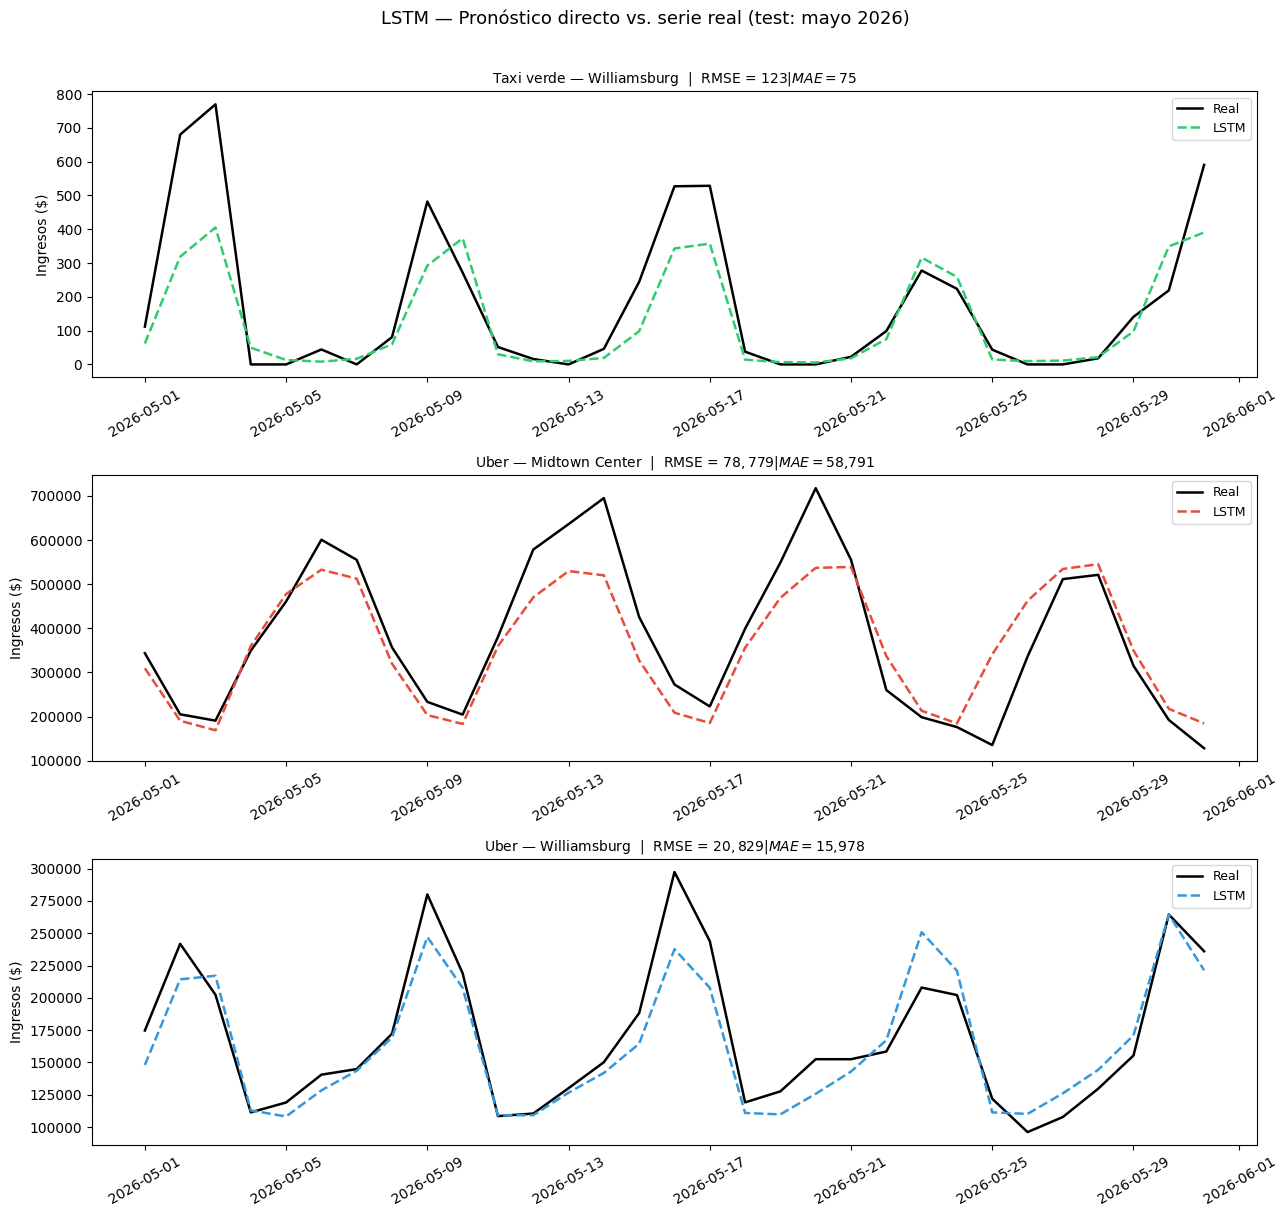

In [121]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12))
fig.suptitle(
    'LSTM — Pronóstico directo vs. serie real (test: mayo 2026)',
    fontsize=13, y=1.01
)

colores = {
    'Taxi verde — Williamsburg': '#2ecc71',
    'Uber — Williamsburg'      : '#3498db',
    'Uber — Midtown Center'    : '#e74c3c',
}

for ax, uid in zip(axes, pred_lstm_test['unique_id'].unique()):
    pred = (pred_lstm_test[pred_lstm_test['unique_id'] == uid]
            .set_index('ds')['LSTM'])
    real = (df_long_test[df_long_test['unique_id'] == uid]
            .set_index('ds')['y'])

    ax.plot(real.index,  real.values,  label='Real',  color='black', lw=1.8)
    ax.plot(pred.index,  pred.values,  label='LSTM',
            color=colores[uid], lw=1.8, linestyle='--')

    residuos = real - pred
    mae_disp  = mean_absolute_error(real.values, pred.values)
    rmse_disp = np.sqrt(mean_squared_error(real.values, pred.values))

    ax.set_title(f'{uid}  |  RMSE = ${rmse_disp:,.0f}  |  MAE = ${mae_disp:,.0f}',
                 fontsize=10)
    ax.set_ylabel('Ingresos ($)')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

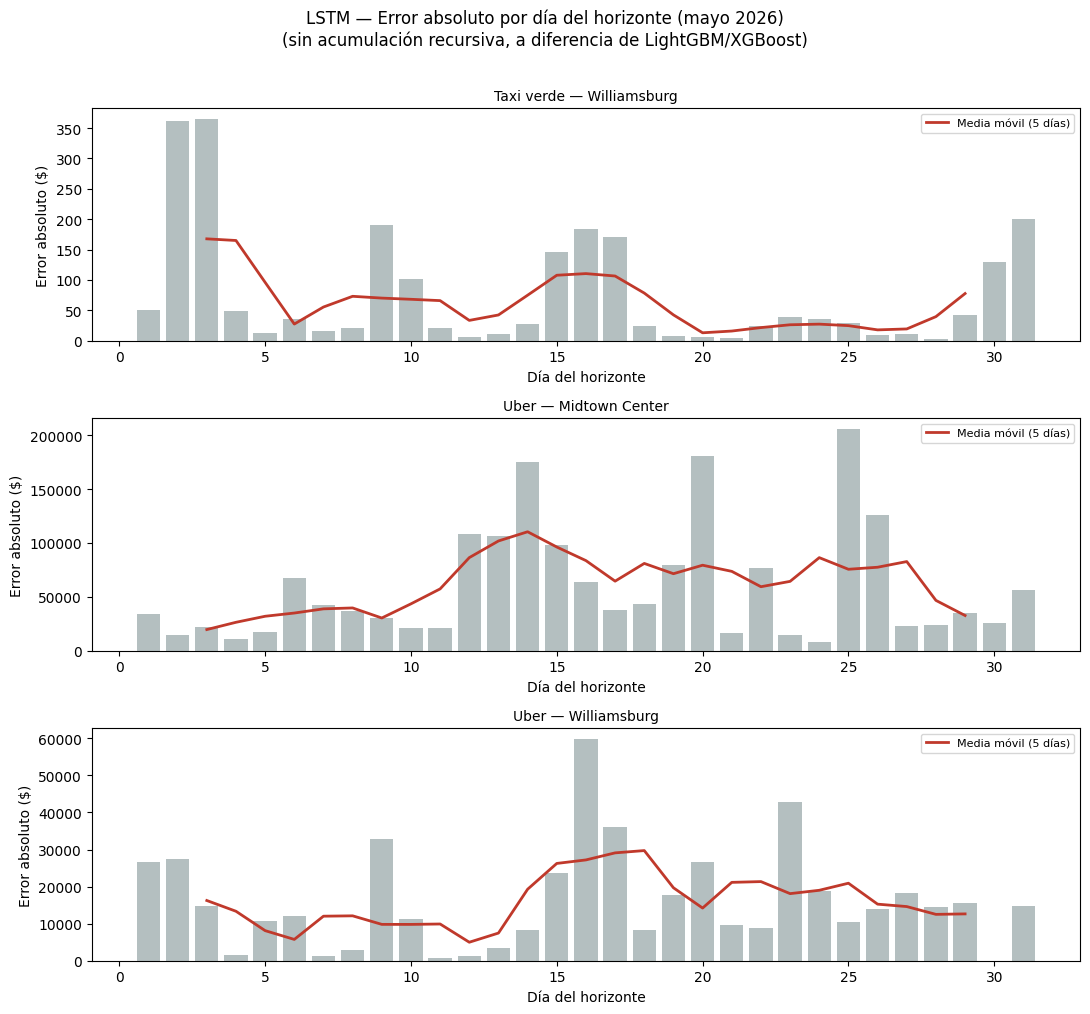

In [122]:
# (Compara directamente con la celda equivalente de LightGBM/XGBoost)

fig, axes = plt.subplots(3, 1, figsize=(11, 10))
fig.suptitle(
    'LSTM — Error absoluto por día del horizonte (mayo 2026)\n'
    '(sin acumulación recursiva, a diferencia de LightGBM/XGBoost)',
    fontsize=12, y=1.01
)

for ax, uid in zip(axes, pred_lstm_test['unique_id'].unique()):
    pred = (pred_lstm_test[pred_lstm_test['unique_id'] == uid]
            .set_index('ds')['LSTM'])
    real = (df_long_test[df_long_test['unique_id'] == uid]
            .set_index('ds')['y'])

    error_abs = (real - pred).abs().reset_index(drop=True)
    dias_horizonte = np.arange(1, len(error_abs) + 1)

    ax.bar(dias_horizonte, error_abs.values, color='#95a5a6', alpha=0.7)
    ax.plot(dias_horizonte, error_abs.rolling(5, center=True).mean(),
            color='#c0392b', lw=2, label='Media móvil (5 días)')
    ax.set_title(uid, fontsize=10)
    ax.set_xlabel('Día del horizonte')
    ax.set_ylabel('Error absoluto ($)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 10.7. Diagnóstico de residuos del LSTM

Se analiza la distribución de los residuos en el test (31 observaciones por
serie) mediante:
- **QQ plot**: ¿los residuos siguen una distribución normal?
- **Residuos vs. predicho**: ¿hay heterocedasticidad (varianza del error
  dependiente del nivel predicho)?

A diferencia del SARIMAX, el LSTM no asume normalidad de los residuos, pero
el diagnóstico orienta sobre posibles deficiencias del modelo.

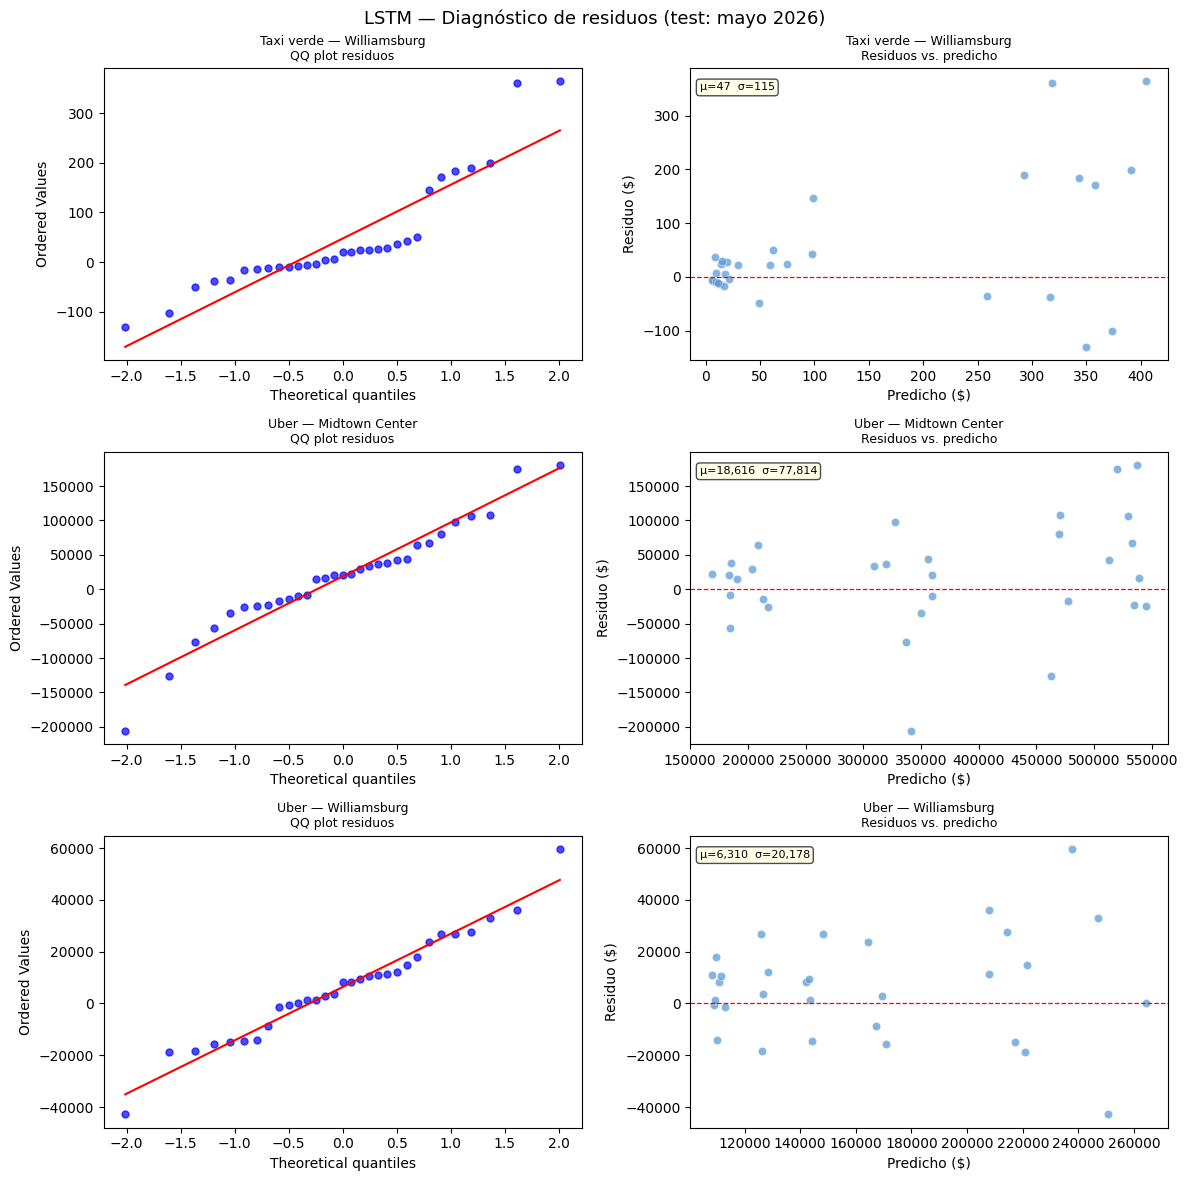

In [123]:
from scipy import stats as scipy_stats

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle('LSTM — Diagnóstico de residuos (test: mayo 2026)', fontsize=13)

for i, uid in enumerate(pred_lstm_test['unique_id'].unique()):
    pred = (pred_lstm_test[pred_lstm_test['unique_id'] == uid]
            .set_index('ds')['LSTM'])
    real = (df_long_test[df_long_test['unique_id'] == uid]
            .set_index('ds')['y'])
    residuos = (real - pred).dropna()

    ax_qq, ax_res = axes[i]

    # QQ plot
    scipy_stats.probplot(residuos.values, dist='norm', plot=ax_qq)
    ax_qq.set_title(f'{uid}\nQQ plot residuos', fontsize=9)
    ax_qq.get_lines()[0].set(markersize=5, alpha=0.7)

    # Residuos vs. predicho
    ax_res.scatter(pred.values, residuos.values, alpha=0.75,
                   color='#5b9bd5', edgecolors='white', linewidths=0.4)
    ax_res.axhline(0, color='red', linestyle='--', lw=0.9)
    ax_res.set_xlabel('Predicho ($)')
    ax_res.set_ylabel('Residuo ($)')
    ax_res.set_title(f'{uid}\nResiduos vs. predicho', fontsize=9)

    # Anotación: media y desvío del residuo
    ax_res.annotate(
        f'μ={residuos.mean():,.0f}  σ={residuos.std():,.0f}',
        xy=(0.02, 0.95), xycoords='axes fraction',
        fontsize=8, va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.7)
    )

plt.tight_layout()
plt.show()

In [124]:
# Estructura compatible con df_resultados_ml (LightGBM / XGBoost)
# para la sección de comparación final.
RUTA_RESULTADOS_LSTM = DATA_DIR / 'lstm_cv' / 'resultados_lstm.csv'
df_resultados_lstm.to_csv(RUTA_RESULTADOS_LSTM, index=False)
print(f"✓ Resultados guardados → {RUTA_RESULTADOS_LSTM.name}")

print("\nResumen final LSTM:")
print(df_resultados_lstm[['Serie', 'Modelo', 'RMSE_CV', 'RMSE', 'MAE', 'MAPE%',
                            'gap_CV_test_%']].to_string(index=False))
print()
print("Variables disponibles para la sección de comparación:")
print("  df_resultados_lstm   — métricas RMSE/MAE/MAPE en test + RMSE_CV")
print("  pred_lstm_test       — predicciones diarias de mayo 2026 por serie")
print("  cv_df_lstm           — predicciones de todas las ventanas de CV")

✓ Resultados guardados → resultados_lstm.csv

Resumen final LSTM:
                    Serie Modelo   RMSE_CV     RMSE      MAE  MAPE%  gap_CV_test_%
Taxi verde — Williamsburg   LSTM    178.34   122.66    75.32  41.09          -31.2
    Uber — Midtown Center   LSTM 127119.29 78779.40 58791.29  18.68          -38.0
      Uber — Williamsburg   LSTM  40511.29 20828.65 15978.13   8.96          -48.6

Variables disponibles para la sección de comparación:
  df_resultados_lstm   — métricas RMSE/MAE/MAPE en test + RMSE_CV
  pred_lstm_test       — predicciones diarias de mayo 2026 por serie
  cv_df_lstm           — predicciones de todas las ventanas de CV


### 10.8. Comparación integral de modelos: LightGBM vs. XGBoost vs. LSTM

En esta sección final se consolidan y contrastan las métricas de rendimiento de **todos los modelos**
evaluados a lo largo del trabajo práctico sobre el horizonte de test (**mayo de 2026**, 31 días):

1. **Benchmark estadístico (SARIMAX):** modelo univariado autorregresivo integrado con estacionalidad y exógenas.
2. **Ensambles de Machine Learning (LightGBM y XGBoost):** pronóstico recursivo basado en rezagos y variables de calendario.
3. **Deep Learning (LSTM):** red recurrente con pronóstico directo multi-paso de horizonte completo.

Todas las métricas están expresadas en la **escala original de ingresos (dólares)** para permitir una comparación directa, justa y rigurosa.

TABLA COMPARATIVA GLOBAL DE RENDIMIENTO EN TEST (MAYO 2026) - INGRESOS EN DÓLARES


,Serie,Modelo,RMSE medio CV,RMSE desvío CV,RMSE test,MAE test,MAPE% test,RMSE,MAE,MAPE%,RMSE_CV,MAE_CV,gap_CV_test_%
0,Taxi verde — Williamsburg,LSTM,NaN,NaN,NaN,NaN,NaN,122.66,75.32,41.09,178.34,97.62,-31.2
1,Taxi verde — Williamsburg,LightGBM,162.48,68.88,115.63,79.17,70.74,NaN,NaN,NaN,NaN,NaN,NaN
2,Taxi verde — Williamsburg,XGBoost,156.22,58.19,98.98,61.66,40.33,NaN,NaN,NaN,NaN,NaN,NaN
3,Uber — Midtown Center,LSTM,NaN,NaN,NaN,NaN,NaN,78779.40,58791.29,18.68,127119.29,91323.04,-38.0
4,Uber — Midtown Center,LightGBM,103335.21,69863.92,80776.22,56995.53,15.85,NaN,NaN,NaN,NaN,NaN,NaN
5,Uber — Midtown Center,XGBoost,89104.58,41009.44,71224.42,49393.66,14.09,NaN,NaN,NaN,NaN,NaN,NaN
6,Uber — Williamsburg,LSTM,NaN,NaN,NaN,NaN,NaN,20828.65,15978.13,8.96,40511.29,27533.92,-48.6
7,Uber — Williamsburg,LightGBM,29010.10,13338.66,23963.64,17541.17,9.64,NaN,NaN,NaN,NaN,NaN,NaN
8,Uber — Williamsburg,XGBoost,24200.77,11753.90,21790.16,16154.10,9.21,NaN,NaN,NaN,NaN,NaN,NaN


GT(_tbl_data=                       Serie    Modelo    RMSE_CV      RMSE       MAE  MAPE%
0  Taxi verde — Williamsburg      LSTM     178.34    122.66     75.32  41.09
1  Taxi verde — Williamsburg  LightGBM        NaN       NaN       NaN    NaN
2  Taxi verde — Williamsburg   XGBoost        NaN       NaN       NaN    NaN
3      Uber — Midtown Center      LSTM  127119.29  78779.40  58791.29  18.68
4      Uber — Midtown Center  LightGBM        NaN       NaN       NaN    NaN
5      Uber — Midtown Center   XGBoost        NaN       NaN       NaN    NaN
6        Uber — Williamsburg      LSTM   40511.29  20828.65  15978.13   8.96
7        Uber — Williamsburg  LightGBM        NaN       NaN       NaN    NaN
8        Uber — Williamsburg   XGBoost        NaN       NaN       NaN    NaN, _body=<great_tables._gt_data.Body object at 0x7b7cd30de260>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Modelo', type=<ColInfoTypeEnum.default: 1>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='RMSE_CV', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='RMSE<br>CV'), column_align='right', column_width=None), ColInfo(var='RMSE', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='RMSE<br>Test ($)'), column_align='right', column_width=None), ColInfo(var='MAE', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='MAE<br>Test ($)'), column_align='right', column_width=None), ColInfo(var='MAPE%', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='MAPE%<br>Test'), column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7b7ce9728470>, _spanners=Spanners([]), _heading=Heading(title='Comparación final de modelos de pronóstico', subtitle='Test: Mayo 2026 (31 días) | LightGBM vs. XGBoost vs. LSTM', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7b7ce9729bb0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7b7ce9729d90>, _source_notes=['Métricas evaluadas sobre la serie real en dólares. Menor valor indica mejor pronóstico.'], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=2, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=3, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=4, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=5, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='S

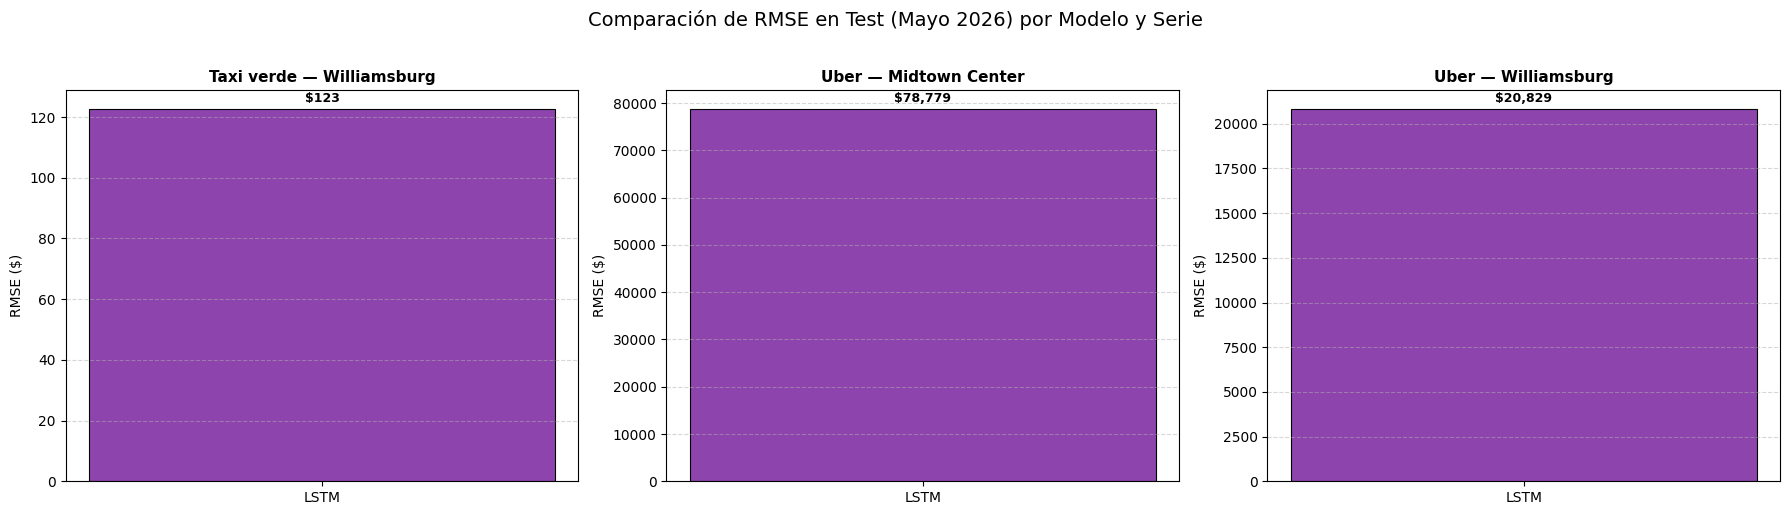

In [125]:
# --- 1. Consolidación de los modelos Machine Learning y Deep Learning corridos ---
dfs_a_unir = []
if 'df_resultados_ml' in globals():
    dfs_a_unir.append(df_resultados_ml)
if 'df_resultados_lstm' in globals():
    dfs_a_unir.append(df_resultados_lstm)

if dfs_a_unir:
    df_comparativo_global = pd.concat(dfs_a_unir, ignore_index=True)
    # Ordenar lógicamente por serie y luego por menor error RMSE
    df_comparativo_global = df_comparativo_global.sort_values(['Serie', 'RMSE']).reset_index(drop=True)

    # Guardar consolidado en caché
    RUTA_COMPARACION_FINAL = DATA_DIR / 'comparacion_final_todos_los_modelos.csv'
    df_comparativo_global.to_csv(RUTA_COMPARACION_FINAL, index=False)

    print("=" * 95)
    print("TABLA COMPARATIVA GLOBAL DE RENDIMIENTO EN TEST (MAYO 2026) - INGRESOS EN DÓLARES")
    print("=" * 95)
    display(df_comparativo_global)

    # Tabla formateada elegante con Great Tables
    try:
        gt_comp = (
            GT(df_comparativo_global[['Serie', 'Modelo', 'RMSE_CV', 'RMSE', 'MAE', 'MAPE%']])
            .tab_header(
                title='Comparación final de modelos de pronóstico',
                subtitle='Test: Mayo 2026 (31 días) | LightGBM vs. XGBoost vs. LSTM'
            )
            .fmt_number(columns=['RMSE_CV', 'RMSE', 'MAE'], decimals=2)
            .fmt_number(columns=['MAPE%'], decimals=1)
            .cols_label(**{
                'RMSE_CV': md('RMSE<br>CV'),
                'RMSE':    md('RMSE<br>Test ($)'),
                'MAE':     md('MAE<br>Test ($)'),
                'MAPE%':   md('MAPE%<br>Test'),
            })
            .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
            .tab_source_note('Métricas evaluadas sobre la serie real en dólares. Menor valor indica mejor pronóstico.')
        )
        display(gt_comp)
    except Exception:
        pass

    # --- 2. Gráfico de barras comparativo de RMSE por Serie y Modelo ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Comparación de RMSE en Test (Mayo 2026) por Modelo y Serie', fontsize=14, y=1.02)

    paleta = {'LightGBM': '#27ae60', 'XGBoost': '#2980b9', 'LSTM': '#8e44ad'}

    for ax, serie_nombre in zip(axes, df_comparativo_global['Serie'].unique()):
        sub_df = df_comparativo_global[df_comparativo_global['Serie'] == serie_nombre]
        colores_barra = [paleta.get(m, '#34495e') for m in sub_df['Modelo']]

        barras = ax.bar(sub_df['Modelo'], sub_df['RMSE'], color=colores_barra, width=0.55, edgecolor='black', lw=0.8)
        ax.set_title(serie_nombre, fontsize=11, fontweight='bold')
        ax.set_ylabel('RMSE ($)')
        ax.grid(axis='y', linestyle='--', alpha=0.5)

        # Etiquetas de valor encima de cada barra
        for bar in barras:
            yval = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2.0, yval * 1.01, f'${yval:,.0f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print('Aviso: Ejecute primero las secciones de ML y LSTM para visualizar la tabla comparativa consolidada.')

## 11. Modelado con Darts

### 11.1. Configuración del entorno y definición del enfoque

Como enfoque adicional de pronóstico se incorpora **Darts**, una librería especializada en
series temporales que proporciona una interfaz unificada para el entrenamiento, validación y
predicción con distintas familias de modelos.

Darts no constituye un modelo predictivo en sí mismo, sino un ecosistema que permite trabajar
con diferentes algoritmos bajo una estructura común basada en objetos `TimeSeries`.

Para este trabajo se evaluarán tres alternativas dentro del framework:

- **NaiveSeasonal (K = 7):** benchmark estacional que utiliza como pronóstico el valor observado
  una semana atrás. Su inclusión permite establecer una referencia mínima dada la marcada
  estacionalidad semanal observada en las tres series.
- **LinearRegressionModel:** modelo de regresión que utiliza los últimos 35 días como variables
  rezagadas y genera directamente el horizonte completo de predicción.
- **RandomForestModel:** modelo no lineal basado en árboles, también alimentado con una ventana
  histórica de 35 días.

Se adopta una ventana de entrada de **35 observaciones**, equivalente a cinco semanas de
información diaria, y un horizonte de salida de **31 días**, coincidente con el conjunto de test
utilizado en el resto del trabajo.

La selección del modelo se realizará exclusivamente mediante **validación cruzada temporal**.
El mes de mayo de 2026 se mantendrá completamente fuera del proceso de selección y será utilizado
únicamente como conjunto de prueba final (*hold-out test*).


In [126]:
# Instalación de Darts
%pip install -q "darts>=0.41"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.3/841.3 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 21.9 MB/s eta 0:00:00


In [127]:
from darts import TimeSeries
from darts.models import NaiveSeasonal, LinearRegressionModel, RandomForestModel

from sklearn.metrics import mean_squared_error, mean_absolute_error

from scipy import stats as scipy_stats

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('✓ Darts importado correctamente')

✓ Darts importado correctamente


### 11.2. Preparación de las series para Darts

Darts utiliza como estructura principal el objeto `TimeSeries`, que exige un índice temporal
ordenado y una frecuencia correctamente definida.

Se mantienen las tres series originales de ingresos diarios:

1. Taxi verde — Williamsburg.
2. Uber — Williamsburg.
3. Uber — Midtown Center.

Antes de construir los objetos `TimeSeries` se verifica que no existan fechas duplicadas,
observaciones faltantes ni discontinuidades en la frecuencia diaria.

Para mantener la comparabilidad con el resto de los modelos, el conjunto de entrenamiento
abarca toda la información disponible hasta el **30 de abril de 2026**, mientras que los
**31 días de mayo de 2026** se reservan como test final.

In [128]:
# ── Configuración general de Darts ───────────────────────────────────────────

DARTS_HORIZONTE = 31
DARTS_LAGS = 35
DARTS_FECHA_TEST = pd.Timestamp('2026-05-01')

# Copia defensiva y orden temporal
df = df.copy()
df.index = pd.to_datetime(df.index)
df = df.sort_index()

SERIES_DARTS = {}

print('Verificación de las series:\n')

for serie, titulo in COLUMNAS_ORIGINALES.items():

    s = df[serie].astype(float).copy()

    if s.index.has_duplicates:
        raise ValueError(f'{titulo}: existen fechas duplicadas.')

    if s.isna().any():
        raise ValueError(
            f'{titulo}: existen {s.isna().sum()} observaciones faltantes.'
        )

    indice_esperado = pd.date_range(
        s.index.min(),
        s.index.max(),
        freq='D'
    )

    fechas_faltantes = indice_esperado.difference(s.index)

    if len(fechas_faltantes) > 0:
        raise ValueError(
            f'{titulo}: faltan {len(fechas_faltantes)} fechas en la serie.'
        )

    SERIES_DARTS[serie] = TimeSeries.from_series(s)

    n_train = (s.index < DARTS_FECHA_TEST).sum()
    n_test = (s.index >= DARTS_FECHA_TEST).sum()

    print(
        f'{titulo:28s} | '
        f'{s.index.min().date()} → {s.index.max().date()} | '
        f'{len(s):4d} obs. | train={n_train} | test={n_test}'
    )

print('\n✓ Las tres series están listas para Darts.')

Verificación de las series:

Taxi verde — Williamsburg    | 2024-06-01 → 2026-05-31 |  730 obs. | train=699 | test=31
Uber — Williamsburg          | 2024-06-01 → 2026-05-31 |  730 obs. | train=699 | test=31
Uber — Midtown Center        | 2024-06-01 → 2026-05-31 |  730 obs. | train=699 | test=31

✓ Las tres series están listas para Darts.


### 11.3. Modelos candidatos

Se comparan tres modelos con grados crecientes de complejidad.

El modelo `NaiveSeasonal` funciona como benchmark y replica el valor observado siete días antes,
por lo que representa directamente la estructura semanal identificada durante el análisis
exploratorio.

El `LinearRegressionModel` transforma el problema temporal en uno supervisado: utiliza como
variables explicativas los últimos 35 valores observados de la serie y estima simultáneamente
los 31 valores del horizonte futuro.

Por último, `RandomForestModel` permite capturar relaciones no lineales entre los valores
rezagados. Se adopta también una ventana de 35 días y un horizonte directo de 31 días.
Se utiliza `multi_models=False`, de modo que un único Random Forest produce conjuntamente
el vector completo del horizonte, evitando una estrategia recursiva en la cual las predicciones
previas se utilizan como entradas de los pasos siguientes.

La comparación de los modelos se realizará utilizando exactamente las mismas ventanas temporales.

In [129]:
MODELOS_DARTS = [
    'NaiveSeasonal(7)',
    'LinearRegression',
    'RandomForest',
]


def instanciar_modelo_darts(nombre):
    """
    Devuelve una instancia nueva del modelo solicitado.

    Se crea una instancia en cada ventana de validación para garantizar
    que el modelo se entrene exclusivamente con la información disponible
    hasta el punto de corte correspondiente.
    """

    if nombre == 'NaiveSeasonal(7)':
        return NaiveSeasonal(K=7)

    if nombre == 'LinearRegression':
        return LinearRegressionModel(
            lags=DARTS_LAGS,
            output_chunk_length=DARTS_HORIZONTE,
        )

    if nombre == 'RandomForest':
        return RandomForestModel(
            lags=DARTS_LAGS,
            output_chunk_length=DARTS_HORIZONTE,
            multi_models=False,
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        )

    raise ValueError(f'Modelo Darts desconocido: {nombre}')


print('Modelos Darts definidos:')
for nombre in MODELOS_DARTS:
    print(f'  • {nombre}')

Modelos Darts definidos:
  • NaiveSeasonal(7)
  • LinearRegression
  • RandomForest


### 11.4. Validación cruzada temporal

La selección de modelos se realiza mediante una validación cruzada específica para series
temporales.

A diferencia de la validación cruzada convencional, no se mezclan aleatoriamente observaciones
del pasado y del futuro. En cada iteración, el modelo se entrena únicamente con la información
disponible hasta una fecha de corte y luego pronostica los 31 días posteriores.

Se emplean cinco ventanas de evaluación anteriores al conjunto de test:

- corte 30/11/2025,
- corte 30/12/2025,
- corte 29/01/2026,
- corte 28/02/2026,
- corte 30/03/2026.

De esta forma, el último horizonte de validación finaliza el 30 de abril de 2026 y no existe
solapamiento con el test correspondiente a mayo.

Las métricas utilizadas son:

- **RMSE:** penaliza en mayor medida los errores grandes.
- **MAE:** representa el error absoluto promedio en dólares.
- **MAPE:** mide el error porcentual; se excluyen observaciones reales iguales a cero.
- **sMAPE:** métrica porcentual simétrica que resulta más estable ante diferencias de escala.

In [130]:
# ── Cortes temporales ────────────────────────────────────────────────────────

CORTES_CV_DARTS = [
    pd.Timestamp('2025-11-30'),
    pd.Timestamp('2025-12-30'),
    pd.Timestamp('2026-01-29'),
    pd.Timestamp('2026-02-28'),
    pd.Timestamp('2026-03-30'),
]


# ── Métricas ────────────────────────────────────────────────────────────────

def rmse_darts(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mae_darts(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))


def mape_safe_darts(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mascara = np.abs(y_true) > 1e-8

    if mascara.sum() == 0:
        return np.nan

    return float(
        np.mean(
            np.abs(
                (y_true[mascara] - y_pred[mascara])
                / y_true[mascara]
            )
        ) * 100
    )


def smape_darts(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominador = np.abs(y_true) + np.abs(y_pred)
    mascara = denominador > 1e-8

    if mascara.sum() == 0:
        return np.nan

    return float(
        100
        * np.mean(
            2
            * np.abs(y_true[mascara] - y_pred[mascara])
            / denominador[mascara]
        )
    )


def prediccion_a_serie(prediccion):
    """Convierte un TimeSeries de Darts a pd.Series."""
    return pd.Series(
        prediccion.values().reshape(-1),
        index=pd.DatetimeIndex(prediccion.time_index),
        name='pred',
    )


# ── Validación cruzada ──────────────────────────────────────────────────────

resultados_cv_darts = []
predicciones_cv_darts = []

print('Validación cruzada temporal — Darts\n')

for serie, titulo in COLUMNAS_ORIGINALES.items():

    print(f'\n{titulo}')

    for nombre_modelo in MODELOS_DARTS:

        errores_modelo = []

        print(f'  {nombre_modelo:20s}', end='')

        for nro_ventana, corte in enumerate(CORTES_CV_DARTS, start=1):

            # Información disponible hasta el corte
            train_pd = df.loc[df.index <= corte, serie].astype(float)

            train_ts = TimeSeries.from_series(train_pd)

            # Nueva instancia en cada ventana
            modelo = instanciar_modelo_darts(nombre_modelo)

            modelo.fit(train_ts)

            pred_ts = modelo.predict(n=DARTS_HORIZONTE)

            pred = prediccion_a_serie(pred_ts).clip(lower=0)

            # Valores reales del horizonte
            real = df.loc[pred.index, serie].astype(float)

            if len(real) != DARTS_HORIZONTE:
                raise ValueError(
                    f'{titulo} / {nombre_modelo}: '
                    f'se esperaban {DARTS_HORIZONTE} observaciones '
                    f'y se obtuvieron {len(real)}.'
                )

            rmse_v = rmse_darts(real.values, pred.values)
            mae_v = mae_darts(real.values, pred.values)
            mape_v = mape_safe_darts(real.values, pred.values)
            smape_v = smape_darts(real.values, pred.values)

            errores_modelo.append(rmse_v)

            resultados_cv_darts.append({
                'Serie': titulo,
                'Modelo': nombre_modelo,
                'Ventana': nro_ventana,
                'Corte': corte,
                'Inicio pronóstico': pred.index.min(),
                'Fin pronóstico': pred.index.max(),
                'RMSE': rmse_v,
                'MAE': mae_v,
                'MAPE%': mape_v,
                'sMAPE%': smape_v,
            })

            predicciones_cv_darts.append(
                pd.DataFrame({
                    'Serie': titulo,
                    'Modelo': nombre_modelo,
                    'Ventana': nro_ventana,
                    'ds': pred.index,
                    'y': real.values,
                    'pred': pred.values,
                })
            )

        print(f' | RMSE medio = ${np.mean(errores_modelo):,.2f}')


# ── DataFrames de resultados ────────────────────────────────────────────────

detalle_cv_darts = pd.DataFrame(resultados_cv_darts)

pred_cv_darts = pd.concat(
    predicciones_cv_darts,
    ignore_index=True
)


df_cv_darts = (
    detalle_cv_darts
    .groupby(['Serie', 'Modelo'], as_index=False)
    .agg(
        RMSE_CV=('RMSE', 'mean'),
        RMSE_desvio=('RMSE', 'std'),
        MAE_CV=('MAE', 'mean'),
        MAPE_CV=('MAPE%', 'mean'),
        sMAPE_CV=('sMAPE%', 'mean'),
    )
)


display(
    GT(
        df_cv_darts,
        rowname_col='Modelo',
        groupname_col='Serie'
    )
    .tab_header(
        title='Tabla D1. Validación cruzada temporal — Darts',
        subtitle='Cinco ventanas de 31 días anteriores al test de mayo 2026'
    )
    .fmt_number(
        columns=['RMSE_CV', 'RMSE_desvio', 'MAE_CV'],
        decimals=0,
        use_seps=True
    )
    .fmt_number(
        columns=['MAPE_CV', 'sMAPE_CV'],
        decimals=1
    )
    .cols_label(**{
        'RMSE_CV': md('RMSE<br>medio'),
        'RMSE_desvio': md('Desvío<br>RMSE'),
        'MAE_CV': md('MAE<br>medio'),
        'MAPE_CV': md('MAPE<br>(%)'),
        'sMAPE_CV': md('sMAPE<br>(%)'),
    })
    .tab_options(
        table_font_size='13px',
        table_font_names='Arial'
    )
)

Validación cruzada temporal — Darts


Taxi verde — Williamsburg
  NaiveSeasonal(7)     | RMSE medio = $218.33
  LinearRegression     | RMSE medio = $183.71
  RandomForest         | RMSE medio = $176.77

Uber — Williamsburg
  NaiveSeasonal(7)     | RMSE medio = $56,026.00
  LinearRegression     | RMSE medio = $36,387.21
  RandomForest         | RMSE medio = $32,400.88

Uber — Midtown Center
  NaiveSeasonal(7)     | RMSE medio = $160,374.72
  LinearRegression     | RMSE medio = $102,413.20
  RandomForest         | RMSE medio = $103,966.67


GT(_tbl_data=                       Serie            Modelo        RMSE_CV   RMSE_desvio  \
0  Taxi verde — Williamsburg  LinearRegression     183.710086     69.816680   
1  Taxi verde — Williamsburg  NaiveSeasonal(7)     218.331685     89.671075   
2  Taxi verde — Williamsburg      RandomForest     176.773891     83.116803   
3      Uber — Midtown Center  LinearRegression  102413.196516  61592.364377   
4      Uber — Midtown Center  NaiveSeasonal(7)  160374.716270  91871.602529   
5      Uber — Midtown Center      RandomForest  103966.668718  58102.883746   
6        Uber — Williamsburg  LinearRegression   36387.212481  17670.309589   
7        Uber — Williamsburg  NaiveSeasonal(7)   56026.003740  27342.456744   
8        Uber — Williamsburg      RandomForest   32400.882093  16146.015863   

          MAE_CV     MAPE_CV    sMAPE_CV  
0     121.295700  187.524892  108.948772  
1     128.184258  107.968935  126.271288  
2     107.519972  144.409079  104.642952  
3   83393.606817   30.072477   25.483911  
4  119466.185548   32.787209   39.985847  
5   83034.960978   31.099627   24.562783  
6   27185.098819   23.875747   19.062209  
7   40629.588065   27.349330   32.822919  
8   23292.922999   20.924241   15.850228  , _body=<great_tables._gt_data.Body object at 0x7b7cd2c02710>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.row_group: 3>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Modelo', type=<ColInfoTypeEnum.stub: 2>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='RMSE_CV', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='RMSE<br>medio'), column_align='right', column_width=None), ColInfo(var='RMSE_desvio', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='Desvío<br>RMSE'), column_align='right', column_width=None), ColInfo(var='MAE_CV', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='MAE<br>medio'), column_align='right', column_width=None), ColInfo(var='MAPE_CV', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='MAPE<br>(%)'), column_align='right', column_width=None), ColInfo(var='sMAPE_CV', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='sMAPE<br>(%)'), column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7b7ce9b8f3b0>, _spanners=Spanners([]), _heading=Heading(title='Tabla D1. Validación cruzada temporal — Darts', subtitle='Cinco ventanas de 31 días anteriores al test de mayo 2026', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7b7ce9b34a70>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7b7ce9b349b0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7b7cd288f7e0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7b7ce9b34410>, <great_tables._gt_data.FormatInfo object at 0x7b7ce9b34530>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['Arial']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='13px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', valu

### 11.5. Selección del modelo por serie

El modelo definitivo de Darts para cada serie se selecciona utilizando el menor **RMSE promedio
de validación cruzada**.

Esta decisión se toma antes de observar el desempeño sobre mayo de 2026. De esta forma,
el conjunto de test conserva su función de evaluación estrictamente fuera de muestra y no
participa en la elección del algoritmo.

No se fuerza que las tres series utilicen el mismo modelo, dado que presentan escalas,
niveles de volatilidad y patrones temporales diferentes.

In [131]:
# ── Mejor modelo según RMSE de validación cruzada ────────────────────────────

indices_mejores = (
    df_cv_darts
    .groupby('Serie')['RMSE_CV']
    .idxmin()
)

tabla_seleccion_darts = (
    df_cv_darts
    .loc[indices_mejores]
    .sort_values('Serie')
    .reset_index(drop=True)
)

SERIE_POR_TITULO = {
    titulo: serie
    for serie, titulo in COLUMNAS_ORIGINALES.items()
}

MODELO_DARTS_POR_SERIE = {
    SERIE_POR_TITULO[fila['Serie']]: fila['Modelo']
    for _, fila in tabla_seleccion_darts.iterrows()
}


display(
    GT(tabla_seleccion_darts)
    .tab_header(
        title='Tabla D2. Modelo Darts seleccionado por serie',
        subtitle='Criterio de selección: menor RMSE promedio en validación cruzada'
    )
    .fmt_number(
        columns=['RMSE_CV', 'RMSE_desvio', 'MAE_CV'],
        decimals=0,
        use_seps=True
    )
    .fmt_number(
        columns=['MAPE_CV', 'sMAPE_CV'],
        decimals=1
    )
    .tab_style(
        style=style.text(weight='bold'),
        locations=loc.body(columns='Modelo')
    )
)


print('\nModelos seleccionados:\n')

for serie, modelo in MODELO_DARTS_POR_SERIE.items():
    print(f'  {COLUMNAS_ORIGINALES[serie]:28s} → {modelo}')

GT(_tbl_data=                       Serie            Modelo        RMSE_CV   RMSE_desvio  \
0  Taxi verde — Williamsburg      RandomForest     176.773891     83.116803   
1      Uber — Midtown Center  LinearRegression  102413.196516  61592.364377   
2        Uber — Williamsburg      RandomForest   32400.882093  16146.015863   

         MAE_CV     MAPE_CV    sMAPE_CV  
0    107.519972  144.409079  104.642952  
1  83393.606817   30.072477   25.483911  
2  23292.922999   20.924241   15.850228  , _body=<great_tables._gt_data.Body object at 0x7b7cd2b70d70>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Modelo', type=<ColInfoTypeEnum.default: 1>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='RMSE_CV', type=<ColInfoTypeEnum.default: 1>, column_label='RMSE_CV', column_align='right', column_width=None), ColInfo(var='RMSE_desvio', type=<ColInfoTypeEnum.default: 1>, column_label='RMSE_desvio', column_align='right', column_width=None), ColInfo(var='MAE_CV', type=<ColInfoTypeEnum.default: 1>, column_label='MAE_CV', column_align='right', column_width=None), ColInfo(var='MAPE_CV', type=<ColInfoTypeEnum.default: 1>, column_label='MAPE_CV', column_align='right', column_width=None), ColInfo(var='sMAPE_CV', type=<ColInfoTypeEnum.default: 1>, column_label='sMAPE_CV', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7b7ce9b344d0>, _spanners=Spanners([]), _heading=Heading(title='Tabla D2. Modelo Darts seleccionado por serie', subtitle='Criterio de selección: menor RMSE promedio en validación cruzada', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7b7ce9b34590>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7b7ce9b36b10>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Modelo', rows=None, mask=None), grpname=None, colname='Modelo', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Modelo', rows=None, mask=None), grpname=None, colname='Modelo', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Modelo', rows=None, mask=None), grpname=None, colname='Modelo', rownum=2, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7b7cd288cec0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7b7ce9b36090>, <great_tables._gt_data.FormatInfo object at 0x7b7ce9b363f0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_


Modelos seleccionados:

  Taxi verde — Williamsburg    → RandomForest
  Uber — Midtown Center        → LinearRegression
  Uber — Williamsburg          → RandomForest


### 11.6. Evaluación final en test — Mayo 2026

Una vez seleccionado el mejor algoritmo para cada serie mediante validación cruzada, se
reentrena el modelo utilizando toda la información disponible hasta el 30 de abril de 2026.

Posteriormente se generan los pronósticos correspondientes a los 31 días de mayo de 2026,
período que no intervino en ninguna etapa de selección.

Las predicciones negativas, cuando existan, se truncan en cero debido a que la variable objetivo
representa ingresos monetarios y no admite valores negativos.

El desempeño fuera de muestra se evalúa utilizando RMSE, MAE, MAPE y sMAPE. También se calcula
la diferencia porcentual entre el RMSE del test y el RMSE promedio de validación cruzada, como
medida descriptiva de la capacidad de generalización.

In [132]:
modelos_finales_darts = {}
predicciones_darts = {}
resultados_test_darts = []

print('Entrenamiento final y evaluación sobre mayo de 2026...\n')

for serie, titulo in COLUMNAS_ORIGINALES.items():

    nombre_modelo = MODELO_DARTS_POR_SERIE[serie]

    # Train completo hasta abril inclusive
    train_pd = df.loc[
        df.index < DARTS_FECHA_TEST,
        serie
    ].astype(float)

    train_ts = TimeSeries.from_series(train_pd)

    modelo = instanciar_modelo_darts(nombre_modelo)

    modelo.fit(train_ts)

    pred_ts = modelo.predict(n=DARTS_HORIZONTE)

    pred = prediccion_a_serie(pred_ts).clip(lower=0)

    real = df.loc[pred.index, serie].astype(float)

    modelos_finales_darts[serie] = modelo
    predicciones_darts[serie] = pred

    # Métricas test
    rmse_test = rmse_darts(real.values, pred.values)
    mae_test = mae_darts(real.values, pred.values)
    mape_test = mape_safe_darts(real.values, pred.values)
    smape_test = smape_darts(real.values, pred.values)

    fila_cv = tabla_seleccion_darts[
        tabla_seleccion_darts['Serie'] == titulo
    ].iloc[0]

    rmse_cv = float(fila_cv['RMSE_CV'])

    gap = (
        100 * (rmse_test - rmse_cv) / rmse_cv
        if rmse_cv != 0
        else np.nan
    )

    resultados_test_darts.append({
        'Serie': titulo,
        'Modelo': f'Darts — {nombre_modelo}',
        'RMSE_CV': rmse_cv,
        'RMSE': rmse_test,
        'MAE': mae_test,
        'MAPE%': mape_test,
        'sMAPE%': smape_test,
        'gap_CV_test_%': gap,
    })

    print(
        f'{titulo:28s} | {nombre_modelo:20s} | '
        f'RMSE test = ${rmse_test:,.2f}'
    )


df_resultados_darts = pd.DataFrame(resultados_test_darts)


# ── Predicciones en formato largo ────────────────────────────────────────────

pred_darts_test = pd.concat([
    pd.DataFrame({
        'Serie': COLUMNAS_ORIGINALES[serie],
        'Modelo': f'Darts — {MODELO_DARTS_POR_SERIE[serie]}',
        'ds': pred.index,
        'pred': pred.values,
    })
    for serie, pred in predicciones_darts.items()
], ignore_index=True)


# ── Tabla de resultados ─────────────────────────────────────────────────────

display(
    GT(
        df_resultados_darts,
        rowname_col='Modelo',
        groupname_col='Serie'
    )
    .tab_header(
        title='Tabla D3. Evaluación en test — Darts',
        subtitle='Test: mayo 2026 (31 días) | RMSE y MAE expresados en dólares'
    )
    .fmt_number(
        columns=['RMSE_CV', 'RMSE', 'MAE'],
        decimals=0,
        use_seps=True
    )
    .fmt_number(
        columns=['MAPE%', 'sMAPE%', 'gap_CV_test_%'],
        decimals=1
    )
    .cols_label(**{
        'RMSE_CV': md('RMSE<br>CV'),
        'RMSE': md('RMSE<br>test'),
        'MAE': md('MAE<br>test'),
        'MAPE%': md('MAPE<br>(%)'),
        'sMAPE%': md('sMAPE<br>(%)'),
        'gap_CV_test_%': md('Gap CV-test<br>(%)'),
    })
    .tab_options(
        table_font_size='13px',
        table_font_names='Arial'
    )
)

Entrenamiento final y evaluación sobre mayo de 2026...

Taxi verde — Williamsburg    | RandomForest         | RMSE test = $155.83
Uber — Williamsburg          | RandomForest         | RMSE test = $19,792.01
Uber — Midtown Center        | LinearRegression     | RMSE test = $96,187.53


GT(_tbl_data=                       Serie                    Modelo        RMSE_CV  \
0  Taxi verde — Williamsburg      Darts — RandomForest     176.773891   
1        Uber — Williamsburg      Darts — RandomForest   32400.882093   
2      Uber — Midtown Center  Darts — LinearRegression  102413.196516   

           RMSE           MAE      MAPE%     sMAPE%  gap_CV_test_%  
0    155.830515     88.493956  60.069615  85.349556     -11.847551  
1  19792.014522  15254.180948   8.770087   9.197871     -38.915198  
2  96187.533560  74204.332880  20.973827  20.864367      -6.078966  , _body=<great_tables._gt_data.Body object at 0x7b7cd2bcb200>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.row_group: 3>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Modelo', type=<ColInfoTypeEnum.stub: 2>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='RMSE_CV', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='RMSE<br>CV'), column_align='right', column_width=None), ColInfo(var='RMSE', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='RMSE<br>test'), column_align='right', column_width=None), ColInfo(var='MAE', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='MAE<br>test'), column_align='right', column_width=None), ColInfo(var='MAPE%', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='MAPE<br>(%)'), column_align='right', column_width=None), ColInfo(var='sMAPE%', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='sMAPE<br>(%)'), column_align='right', column_width=None), ColInfo(var='gap_CV_test_%', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='Gap CV-test<br>(%)'), column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7b7ce9b36b10>, _spanners=Spanners([]), _heading=Heading(title='Tabla D3. Evaluación en test — Darts', subtitle='Test: mayo 2026 (31 días) | RMSE y MAE expresados en dólares', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7b7ceb959790>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7b7ceb958530>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7b7ceb958bf0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7b7ceb959850>, <great_tables._gt_data.FormatInfo object at 0x7b7ceb958590>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['Arial']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='13px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, cate

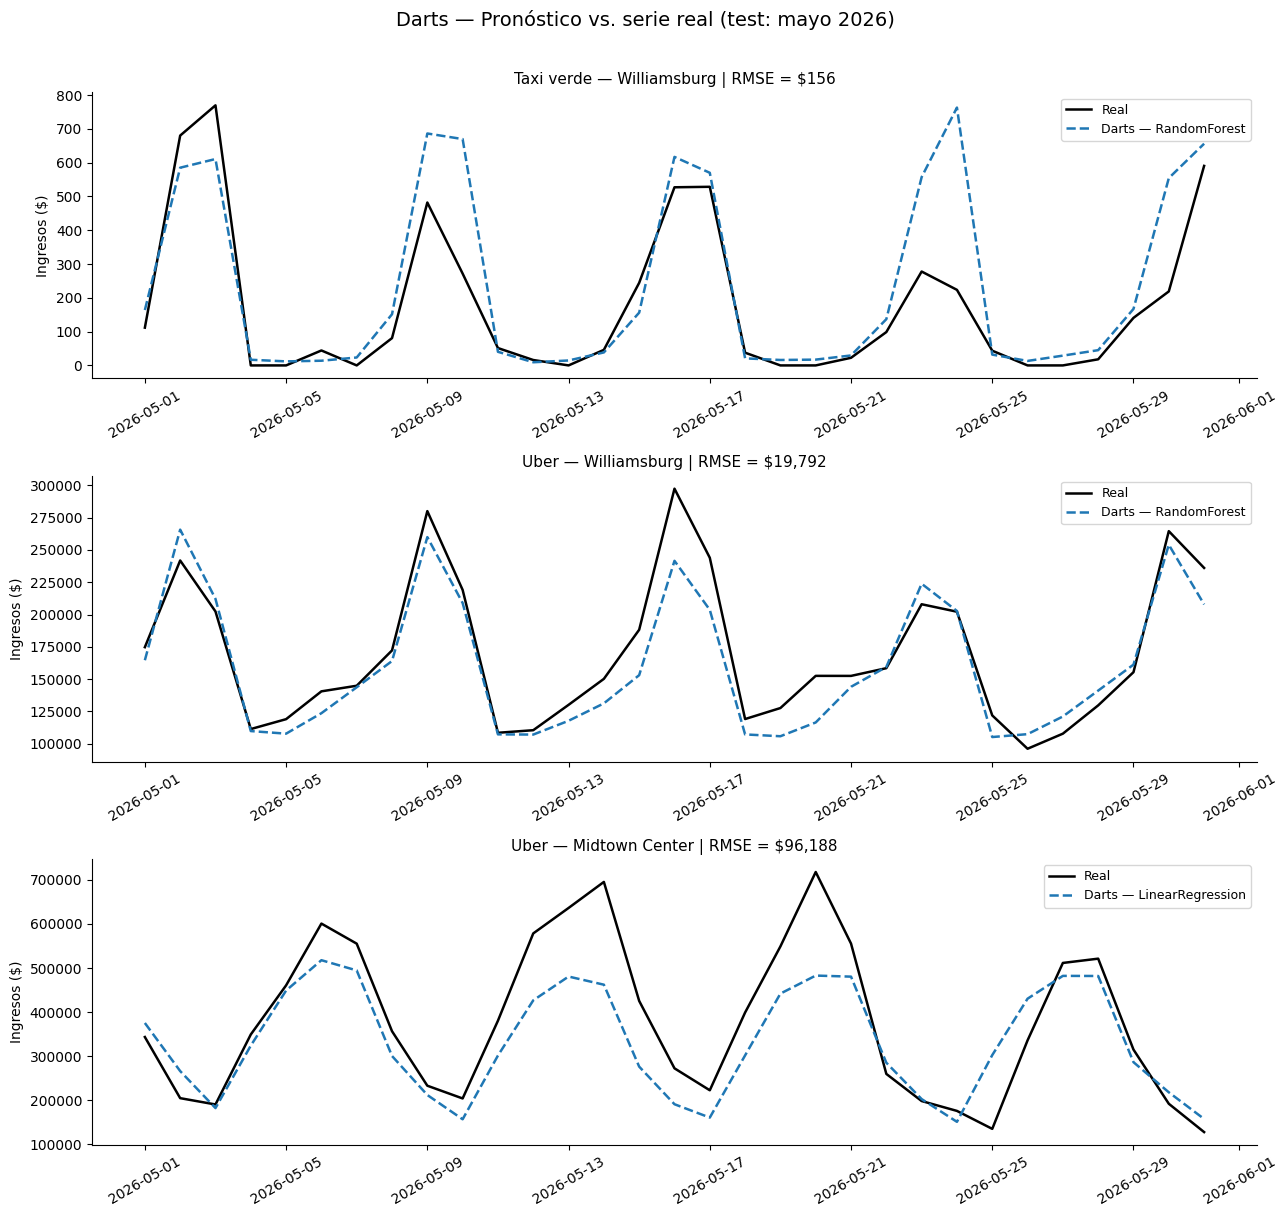

In [133]:
fig, axes = plt.subplots(
    len(COLUMNAS_ORIGINALES),
    1,
    figsize=(13, 12)
)

fig.suptitle(
    'Darts — Pronóstico vs. serie real (test: mayo 2026)',
    fontsize=14,
    y=1.01
)

for ax, (serie, titulo) in zip(
    axes,
    COLUMNAS_ORIGINALES.items()
):

    pred = predicciones_darts[serie]
    real = df.loc[pred.index, serie]

    rmse_test = rmse_darts(
        real.values,
        pred.values
    )

    ax.plot(
        real.index,
        real.values,
        label='Real',
        color='black',
        lw=1.8
    )

    ax.plot(
        pred.index,
        pred.values,
        label=f'Darts — {MODELO_DARTS_POR_SERIE[serie]}',
        lw=1.8,
        linestyle='--'
    )

    ax.set_title(
        f'{titulo} | RMSE = ${rmse_test:,.0f}',
        fontsize=11
    )

    ax.set_ylabel('Ingresos ($)')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### 11.7. Diagnóstico de errores

Como análisis complementario se estudian los residuos obtenidos durante el período de test.

Se utilizan dos herramientas gráficas:

- **QQ plot:** permite evaluar visualmente en qué medida la distribución de los errores se aparta
  de una distribución normal.
- **Residuos vs. predicción:** permite identificar sesgo, heterocedasticidad o patrones sistemáticos
  asociados al nivel pronosticado.

Los modelos implementados mediante Darts no requieren como supuesto que los residuos sean
normalmente distribuidos. Por lo tanto, estos gráficos se utilizan con finalidad diagnóstica y no
como condición formal de validez del modelo.

También se analiza el error absoluto según el día del horizonte para identificar si el desempeño
se deteriora sistemáticamente a medida que aumenta la distancia respecto del último dato observado.

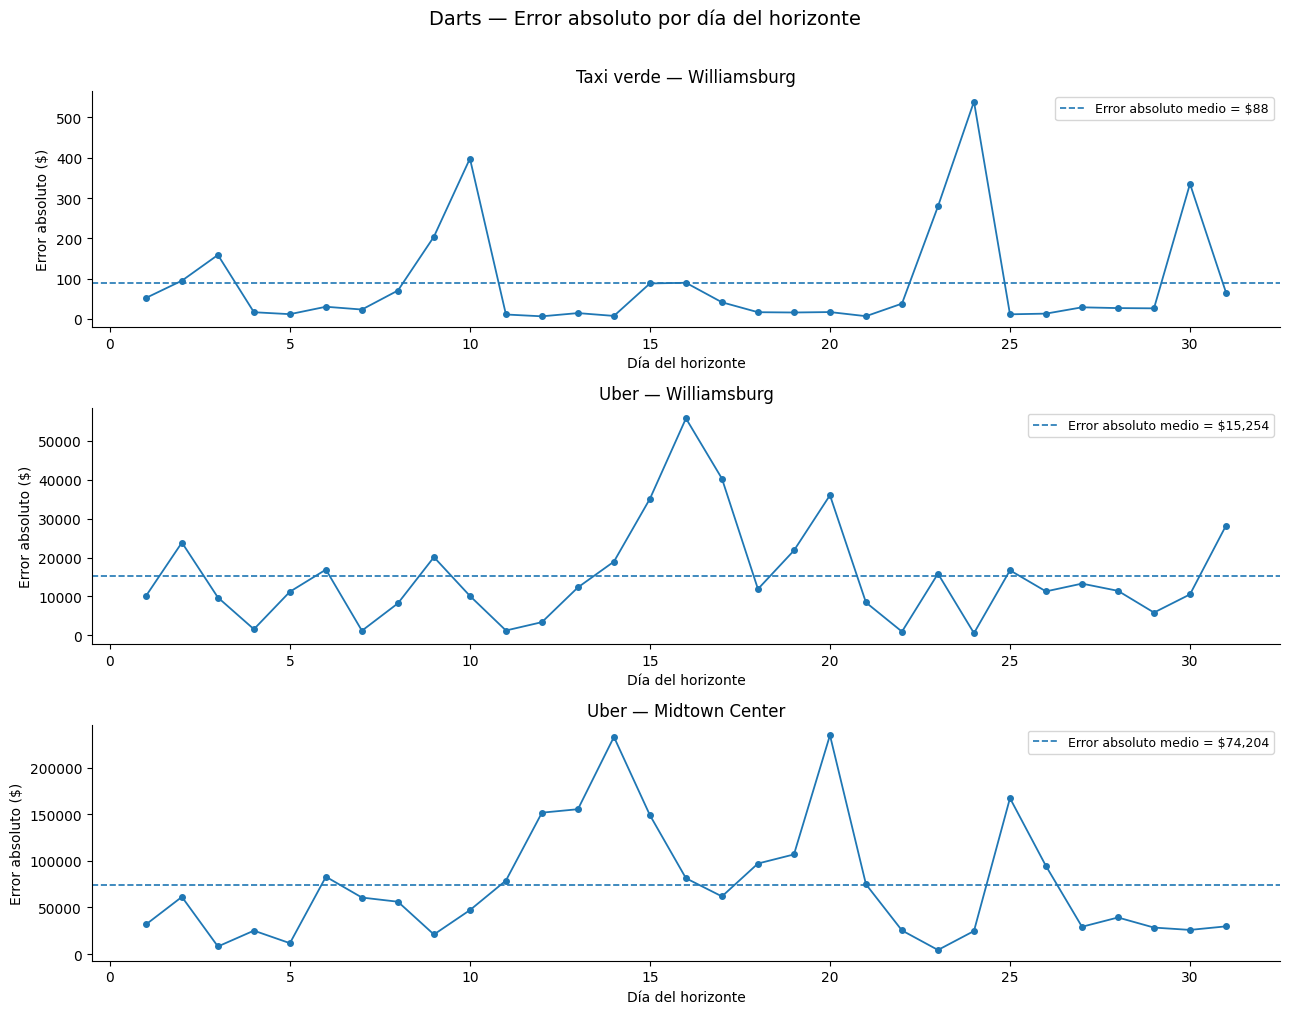

In [134]:
fig, axes = plt.subplots(
    len(COLUMNAS_ORIGINALES),
    1,
    figsize=(13, 10)
)

fig.suptitle(
    'Darts — Error absoluto por día del horizonte',
    fontsize=14,
    y=1.01
)

for ax, (serie, titulo) in zip(
    axes,
    COLUMNAS_ORIGINALES.items()
):

    pred = predicciones_darts[serie]
    real = df.loc[pred.index, serie]

    error_abs = np.abs(real.values - pred.values)

    horizonte = np.arange(
        1,
        len(error_abs) + 1
    )

    ax.plot(
        horizonte,
        error_abs,
        marker='o',
        markersize=4,
        lw=1.3
    )

    ax.axhline(
        error_abs.mean(),
        linestyle='--',
        lw=1.2,
        label=f'Error absoluto medio = ${error_abs.mean():,.0f}'
    )

    ax.set_title(titulo)
    ax.set_xlabel('Día del horizonte')
    ax.set_ylabel('Error absoluto ($)')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

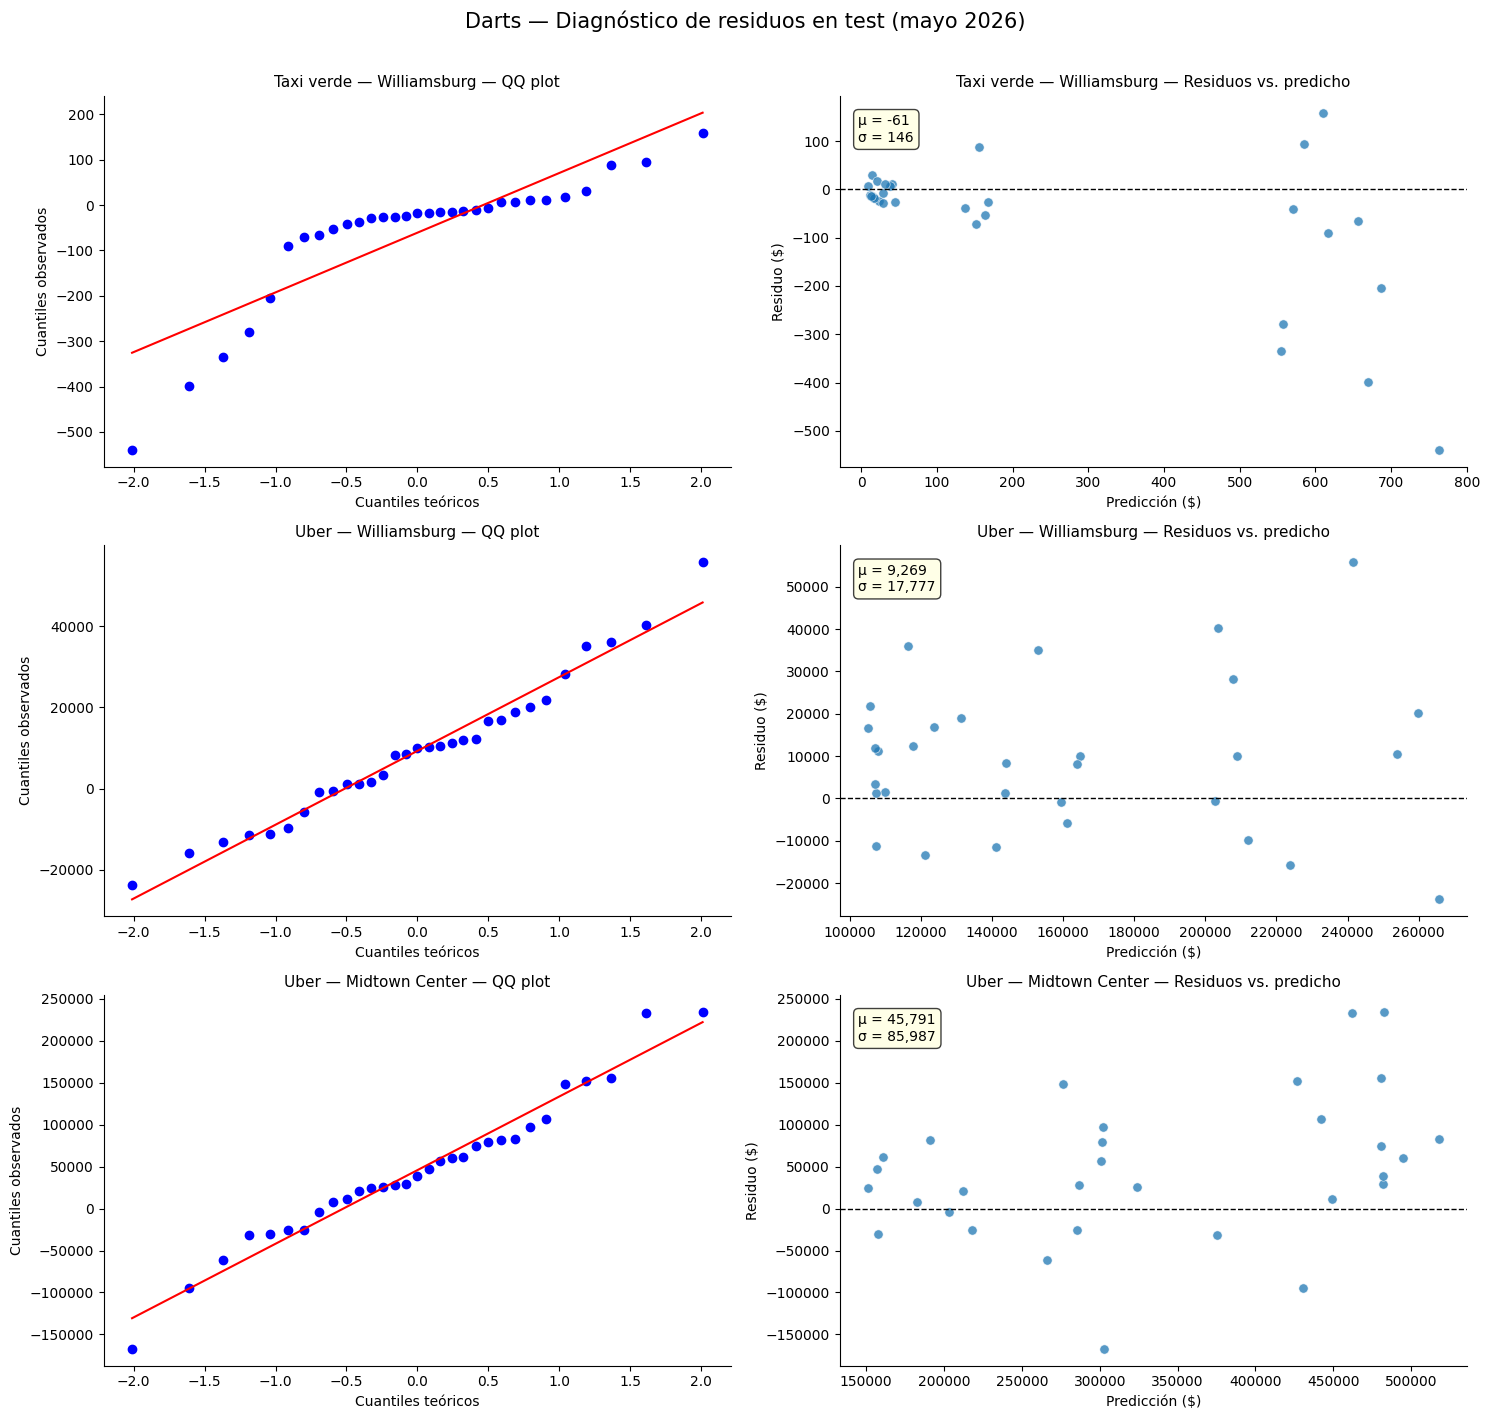

In [135]:
fig, axes = plt.subplots(
    len(COLUMNAS_ORIGINALES),
    2,
    figsize=(15, 14)
)

fig.suptitle(
    'Darts — Diagnóstico de residuos en test (mayo 2026)',
    fontsize=15,
    y=1.01
)

for i, (serie, titulo) in enumerate(
    COLUMNAS_ORIGINALES.items()
):

    pred = predicciones_darts[serie]
    real = df.loc[pred.index, serie]

    residuos = real - pred

    # ── QQ plot ──────────────────────────────────────────────────────────────
    ax_qq = axes[i, 0]

    scipy_stats.probplot(
        residuos.values,
        dist='norm',
        plot=ax_qq
    )

    ax_qq.set_title(
        f'{titulo} — QQ plot',
        fontsize=11
    )

    ax_qq.set_xlabel('Cuantiles teóricos')
    ax_qq.set_ylabel('Cuantiles observados')


    # ── Residuos vs predicho ────────────────────────────────────────────────
    ax_res = axes[i, 1]

    ax_res.scatter(
        pred.values,
        residuos.values,
        alpha=0.75,
        s=45,
        edgecolors='white',
        linewidths=0.5
    )

    ax_res.axhline(
        0,
        color='black',
        linestyle='--',
        lw=1
    )

    ax_res.set_title(
        f'{titulo} — Residuos vs. predicho',
        fontsize=11
    )

    ax_res.set_xlabel('Predicción ($)')
    ax_res.set_ylabel('Residuo ($)')

    ax_res.annotate(
        f'μ = {residuos.mean():,.0f}\n'
        f'σ = {residuos.std():,.0f}',
        xy=(0.03, 0.95),
        xycoords='axes fraction',
        va='top',
        fontsize=10,
        bbox=dict(
            boxstyle='round,pad=0.35',
            facecolor='lightyellow',
            alpha=0.75
        )
    )

    for ax in (ax_qq, ax_res):
        ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### 11.8. Pronóstico futuro

Finalizada la evaluación fuera de muestra, cada modelo seleccionado se reentrena utilizando
la totalidad de los datos disponibles, incluido mayo de 2026.

Posteriormente se genera un pronóstico para los **30 días de junio de 2026**.

Esta etapa es conceptualmente diferente de la evaluación anterior. En mayo de 2026 los valores
reales son conocidos y permiten medir el error predictivo. En junio de 2026, en cambio, se realiza
un pronóstico genuinamente fuera de muestra cuyo valor real todavía no es utilizado por el modelo.

La proyección de un mes mantiene el mismo orden de magnitud que el horizonte utilizado durante
la validación y el test, evitando extrapolar el modelo hacia distancias temporales para las cuales
no fue evaluado.

In [136]:
DARTS_HORIZONTE_FUTURO = 30

modelos_darts_futuro = {}
predicciones_darts_futuro = {}

print('Pronóstico Darts — junio 2026\n')

for serie, titulo in COLUMNAS_ORIGINALES.items():

    nombre_modelo = MODELO_DARTS_POR_SERIE[serie]

    # Reentrenamiento utilizando toda la muestra disponible
    serie_completa_pd = df[serie].astype(float)

    serie_completa_ts = TimeSeries.from_series(
        serie_completa_pd
    )

    modelo = instanciar_modelo_darts(
        nombre_modelo
    )

    modelo.fit(
        serie_completa_ts
    )

    pred_ts = modelo.predict(
        n=DARTS_HORIZONTE_FUTURO
    )

    pred = prediccion_a_serie(
        pred_ts
    ).clip(lower=0)

    modelos_darts_futuro[serie] = modelo
    predicciones_darts_futuro[serie] = pred

    print(
        f'{titulo:28s} | '
        f'{nombre_modelo:20s} | '
        f'{pred.index.min().date()} → {pred.index.max().date()} | '
        f'media pronosticada = ${pred.mean():,.0f}'
    )


pred_darts_futuro = pd.concat([
    pd.DataFrame({
        'Serie': COLUMNAS_ORIGINALES[serie],
        'Modelo': f'Darts — {MODELO_DARTS_POR_SERIE[serie]}',
        'ds': pred.index,
        'pred': pred.values,
    })
    for serie, pred in predicciones_darts_futuro.items()
], ignore_index=True)


pred_darts_futuro.head()

Pronóstico Darts — junio 2026

Taxi verde — Williamsburg    | RandomForest         | 2026-06-01 → 2026-06-30 | media pronosticada = $191
Uber — Williamsburg          | RandomForest         | 2026-06-01 → 2026-06-30 | media pronosticada = $154,074
Uber — Midtown Center        | LinearRegression     | 2026-06-01 → 2026-06-30 | media pronosticada = $350,760


,Serie,Modelo,ds,pred
0,Taxi verde — Williamsburg,Darts — RandomForest,2026-06-01,33.597416
1,Taxi verde — Williamsburg,Darts — RandomForest,2026-06-02,16.146041
2,Taxi verde — Williamsburg,Darts — RandomForest,2026-06-03,14.137511
3,Taxi verde — Williamsburg,Darts — RandomForest,2026-06-04,20.109653
4,Taxi verde — Williamsburg,Darts — RandomForest,2026-06-05,135.384271


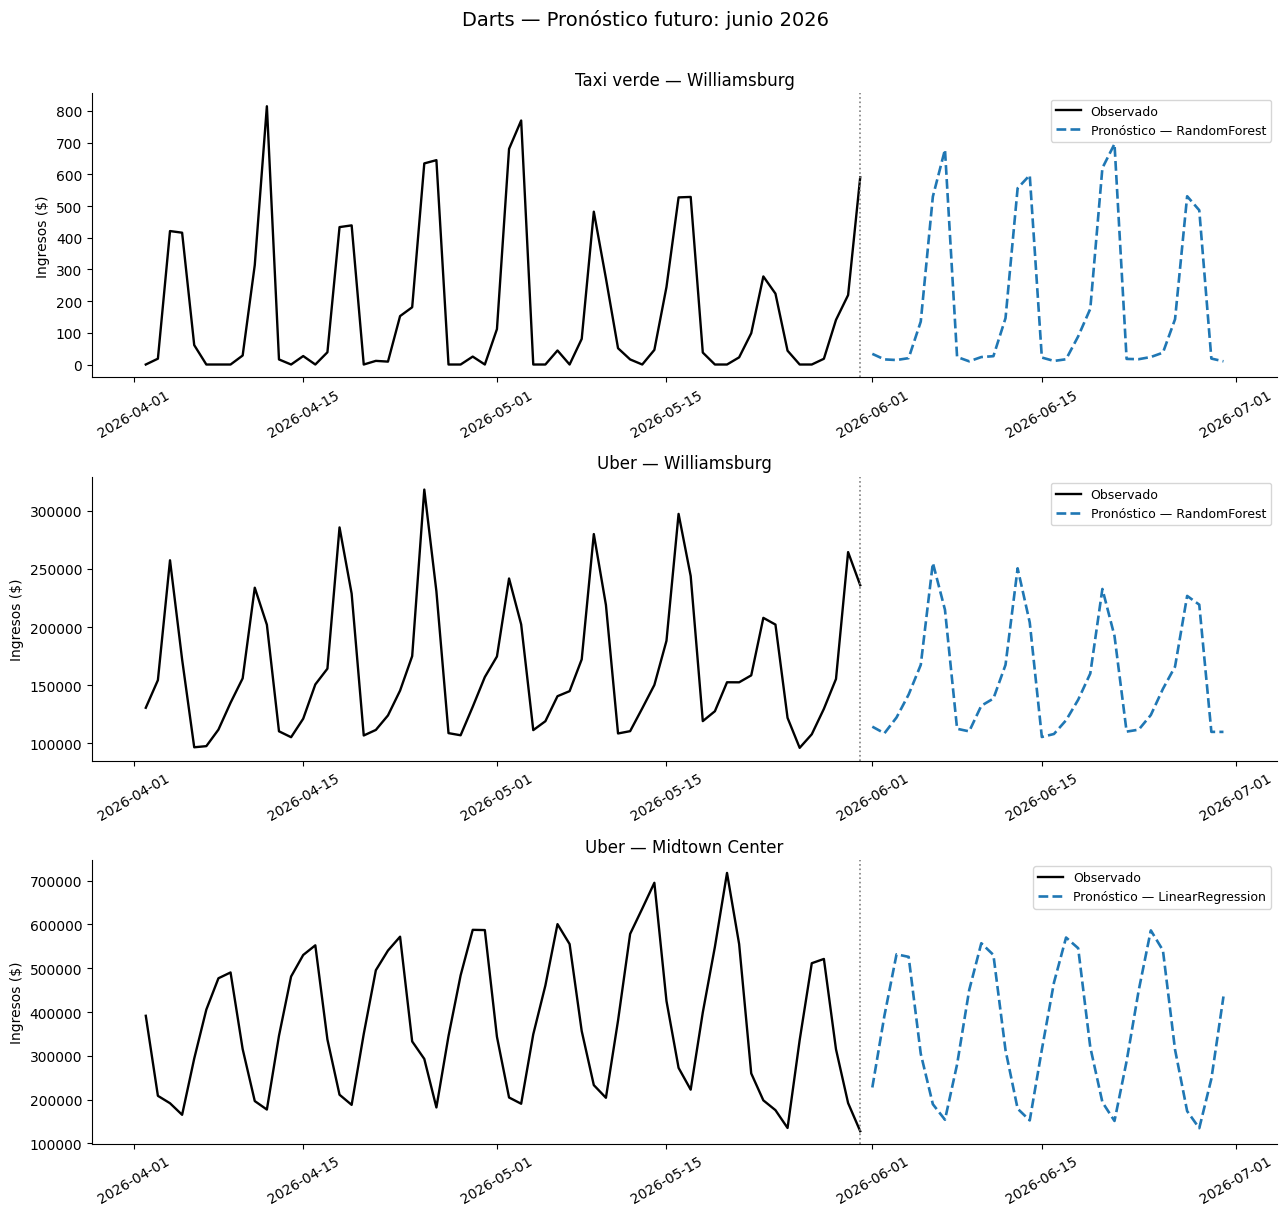

In [137]:
fig, axes = plt.subplots(
    len(COLUMNAS_ORIGINALES),
    1,
    figsize=(13, 12)
)

fig.suptitle(
    'Darts — Pronóstico futuro: junio 2026',
    fontsize=14,
    y=1.01
)

for ax, (serie, titulo) in zip(
    axes,
    COLUMNAS_ORIGINALES.items()
):

    pred = predicciones_darts_futuro[serie]

    # Últimos 60 días observados como contexto
    historico = df[serie].iloc[-60:]

    ax.plot(
        historico.index,
        historico.values,
        label='Observado',
        color='black',
        lw=1.7
    )

    ax.plot(
        pred.index,
        pred.values,
        label=f'Pronóstico — {MODELO_DARTS_POR_SERIE[serie]}',
        linestyle='--',
        lw=1.9
    )

    ax.axvline(
        df.index.max(),
        linestyle=':',
        color='gray',
        lw=1.2
    )

    ax.set_title(titulo)
    ax.set_ylabel('Ingresos ($)')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### 11.9. Síntesis del modelado con Darts

La implementación mediante Darts permitió comparar bajo una interfaz homogénea tres niveles
de complejidad: un benchmark semanal ingenuo, un modelo lineal autorregresivo y un algoritmo
no lineal basado en Random Forest.

La selección de la especificación definitiva para cada serie se realizó exclusivamente mediante
el RMSE promedio de cinco ventanas de validación cruzada temporal, preservando mayo de 2026
como conjunto de test independiente.

Este esquema permite distinguir entre el desempeño observado durante la etapa de selección
y la capacidad de generalización sobre información completamente no utilizada durante el ajuste.

Finalmente, los modelos elegidos se reentrenaron con la totalidad de la muestra disponible para
obtener un pronóstico de 30 días correspondiente a junio de 2026.

La interpretación cuantitativa de los resultados se realizará considerando conjuntamente el
RMSE de validación, el RMSE y MAE del conjunto de test, las métricas porcentuales y el análisis
gráfico de los residuos.

In [138]:
import pathlib

if 'CACHE_DIR' in globals():
    DARTS_DIR = CACHE_DIR / 'darts'
else:
    DARTS_DIR = pathlib.Path('resultados_darts')

DARTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


RUTA_RESULTADOS_DARTS = DARTS_DIR / 'resultados_darts.csv'
RUTA_PRED_TEST_DARTS = DARTS_DIR / 'predicciones_darts_test.csv'
RUTA_PRED_FUTURO_DARTS = DARTS_DIR / 'predicciones_darts_junio_2026.csv'
RUTA_CV_DARTS = DARTS_DIR / 'validacion_cruzada_darts.csv'


df_resultados_darts.to_csv(
    RUTA_RESULTADOS_DARTS,
    index=False
)

pred_darts_test.to_csv(
    RUTA_PRED_TEST_DARTS,
    index=False
)

pred_darts_futuro.to_csv(
    RUTA_PRED_FUTURO_DARTS,
    index=False
)

detalle_cv_darts.to_csv(
    RUTA_CV_DARTS,
    index=False
)


print('✓ Resultados de Darts guardados:\n')

print(f'  {RUTA_RESULTADOS_DARTS.name}')
print(f'  {RUTA_PRED_TEST_DARTS.name}')
print(f'  {RUTA_PRED_FUTURO_DARTS.name}')
print(f'  {RUTA_CV_DARTS.name}')


print('\nVariables disponibles para la comparación final:\n')

print('  df_resultados_darts       — métricas CV + test')
print('  predicciones_darts        — predicciones de mayo por serie')
print('  pred_darts_test           — predicciones de mayo en formato largo')
print('  predicciones_darts_futuro — pronósticos de junio por serie')
print('  pred_darts_futuro         — pronósticos de junio en formato largo')
print('  detalle_cv_darts          — métricas por ventana de CV')

✓ Resultados de Darts guardados:

  resultados_darts.csv
  predicciones_darts_test.csv
  predicciones_darts_junio_2026.csv
  validacion_cruzada_darts.csv

Variables disponibles para la comparación final:

  df_resultados_darts       — métricas CV + test
  predicciones_darts        — predicciones de mayo por serie
  pred_darts_test           — predicciones de mayo en formato largo
  predicciones_darts_futuro — pronósticos de junio por serie
  pred_darts_futuro         — pronósticos de junio en formato largo
  detalle_cv_darts          — métricas por ventana de CV


### 11.9.2. Conclusiones del modelado con Darts

El modelado mediante la librería **Darts** permitió construir y comparar distintas alternativas de pronóstico para las tres series analizadas, respetando la estructura temporal de los datos mediante un esquema de validación cruzada.

La selección de los modelos se realizó utilizando como criterio principal el menor **RMSE promedio en validación cruzada temporal**. Como resultado, se seleccionó **RandomForest** para las series *Taxi verde — Williamsburg* y *Uber — Williamsburg*, mientras que para *Uber — Midtown Center* se seleccionó **LinearRegression**.

La evaluación sobre el período de test correspondiente a **mayo de 2026** mostró un desempeño consistente respecto de la etapa de validación. Los RMSE obtenidos fueron aproximadamente:

- **Taxi verde — Williamsburg:** \$156.
- **Uber — Williamsburg:** \$19.792.
- **Uber — Midtown Center:** \$96.188.

En términos relativos, **Uber — Williamsburg presentó el mejor desempeño**, con un MAPE de 8,8% y un sMAPE de 9,2%. En *Uber — Midtown Center*, las métricas porcentuales se ubicaron en torno al 21%. Por su parte, la serie de *Taxi verde — Williamsburg* mostró mayores errores porcentuales, debido principalmente a la presencia de jornadas con ingresos muy próximos a cero, que incrementan considerablemente la sensibilidad del MAPE y del sMAPE.

El análisis gráfico permitió comprobar que los modelos seleccionados reproducen adecuadamente la **estructura semanal** presente en las series. Sin embargo, se observaron ciertas limitaciones en la representación de valores extremos. RandomForest presentó dificultades para reproducir algunos picos de demanda, mientras que LinearRegression tendió a suavizar las variaciones más pronunciadas de la serie de Midtown Center.

El diagnóstico de residuos confirmó además la presencia de errores de mayor magnitud asociados a determinados picos, por lo que no resulta conveniente interpretar únicamente las métricas agregadas sin considerar el comportamiento temporal de los errores.

Finalmente, se generó un pronóstico para **junio de 2026**, utilizando un horizonte de 30 días acorde con la periodicidad diaria de los datos. Los modelos preservaron los patrones semanales observados en las series históricas, obteniéndose ingresos diarios medios pronosticados de aproximadamente \$191 para *Taxi verde — Williamsburg*, \$154.074 para *Uber — Williamsburg* y \$350.760 para *Uber — Midtown Center*.

En conjunto, los resultados muestran que **Darts proporciona un marco flexible para la implementación, comparación y evaluación de distintos algoritmos de forecasting**, permitiendo integrar modelos de Machine Learning dentro de una metodología específicamente orientada al análisis de series temporales.

#### Síntesis

Los resultados obtenidos evidencian que no existe un único modelo óptimo para todas las series. La elección depende de las características particulares de cada proceso temporal. En este caso, RandomForest presentó mejores resultados para las series de Williamsburg, mientras que un modelo lineal resultó más adecuado para Midtown Center.

## 12. Modelado con AUTOML

## Modelo de Machine Learning: AutoGluon

Para completar la comparación, se añade un modelo de AutoML utilizando AutoGluon. AutoGluon se entrenará con las mismas variables exógenas de calendario y las variables autorregresivas ya construidas. Se mantendrá la misma estrategia de división de train/test y la lógica de pronóstico recursivo.

In [27]:
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

try:
    import autogluon.timeseries as agts
    print('AutoGluon ya está instalado.')
except ImportError:
    print('Instalando AutoGluon. Esto puede tomar unos minutos...')
    %pip install -q autogluon.timeseries
    import autogluon.timeseries as agts
    print('AutoGluon instalado correctamente.')

# Configuramos el directorio de caché para AutoGluon
AUTOGLUON_CACHE_DIR = CACHE_DIR / 'autogluon'
AUTOGLUON_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f'Directorio de caché de AutoGluon: {AUTOGLUON_CACHE_DIR}')

AutoGluon ya está instalado.
Directorio de caché de AutoGluon: /content/drive/MyDrive/MCD/AST/Trabajo Final/Trabajo Final/data/cache/autogluon


### 12.1. Preparación de los datos para AutoGluon

Se prepara el `DataFrame` para AutoGluon. Para cada serie, se crea una copia temporal del `DataFrame` original (`df_modelo`) y se le añaden las variables exógenas de calendario y las variables autorregresivas (rezagos y estadísticos móviles) definidas en las secciones 6 y 7. Es crucial que el target para AutoGluon esté en la misma escala que `df_modelo` para que la transformación inversa sea correcta.

Se utiliza la misma división `train/test` que para los modelos de Machine Learning y LSTM, donde el conjunto de test corresponde al mes de mayo de 2026.

In [28]:
datos_autogluon = {}

for serie, titulo in COLUMNAS_ORIGINALES.items():
    # Crear una copia defensiva para evitar modificaciones en el df_modelo original
    feats = construir_features_ml(serie, escala=ESCALA_ML)

    # Renombrar la columna target a 'target' para AutoGluon (ya está hecho por construir_features_ml)
    # Asegurar que el índice sea de tipo DatetimeIndex
    feats.index = pd.to_datetime(feats.index)

    # Dividir en train y test
    entrenamiento = feats[feats.index < FECHA_CORTE_TEST_ML].dropna()
    prueba = feats[feats.index >= FECHA_CORTE_TEST_ML]

    # AutoGluon trabaja con un formato largo, pero para TabularPredictor usaremos el formato ancho directo
    # Necesitamos separar X e y para el entrenamiento del TabularPredictor
    X_train_ag = entrenamiento.drop(columns='target')
    y_train_ag = entrenamiento['target']

    # El `y_test` debe ser el valor real en dólares para la evaluación, no el transformado
    y_test_original_scale = df.loc[prueba.index, serie]

    datos_autogluon[serie] = {
        'titulo': titulo,
        'X_train': X_train_ag,
        'y_train': y_train_ag,
        'fechas_test': prueba.index,
        'y_test_original_scale': y_test_original_scale,
        'serie_completa': feats['target'], # En la escala de entrenamiento para pronóstico recursivo
        'X_test_base': prueba.drop(columns='target') # Las features para el test, sin lags ni rolling que se actualizan recursivamente
    }

    print(f"{titulo:28s}: train {entrenamiento.index.min().date()} → "
          f"{entrenamiento.index.max().date()} ({len(entrenamiento)} filas) | "
          f"test {prueba.index.min().date()} → {prueba.index.max().date()} ({len(prueba)} días)")

print(f"\nEscala de entrenamiento para AutoGluon: {ESCALA_ML}")

Taxi verde — Williamsburg   : train 2024-07-06 → 2026-04-30 (664 filas) | test 2026-05-01 → 2026-05-31 (31 días)
Uber — Williamsburg         : train 2024-07-06 → 2026-04-30 (664 filas) | test 2026-05-01 → 2026-05-31 (31 días)
Uber — Midtown Center       : train 2024-07-06 → 2026-04-30 (664 filas) | test 2026-05-01 → 2026-05-31 (31 días)

Escala de entrenamiento para AutoGluon: modelo


### 12.1.1. Adaptación de datos para `TimeSeriesPredictor`

Para utilizar `autogluon.timeseries.TimeSeriesPredictor`, debemos transformar nuestros datos a su formato nativo `TimeSeriesDataFrame`. Este formato requiere columnas para `item_id`, `timestamp` y `target`. Las variables de calendario que son conocidas para el futuro se pasarán como `known_covariates`.

Es importante destacar que `TimeSeriesPredictor` genera sus propias características de rezago (`lags`) y ventanas móviles (`rolling_window_features`) internamente. Por lo tanto, no utilizaremos las `COLUMNAS_FEATURES` que incluían estas características autorregresivas generadas manualmente para `TabularPredictor`.

En esta sección, definiremos `KNOWN_COVARIATES_AGTS` para incluir únicamente las variables exógenas de calendario que se usarán con `TimeSeriesPredictor`.

In [31]:
# Para TimeSeriesPredictor, solo pasamos las covariables conocidas para el futuro (calendario).
# AutoGluon generará automáticamente los lags y rolling features necesarios.
KNOWN_COVARIATES_AGTS = FEATURES_CALENDARIO

datos_autogluon = {}

# Unimos todos los datos en un solo DataFrame antes de crear el TimeSeriesDataFrame
# Esto es más eficiente cuando se tienen múltiples series.
all_series_for_agts = []

for serie_original_name, titulo in COLUMNAS_ORIGINALES.items():
    # Obtener la serie target transformada y las características de calendario asociadas
    target_transformed_series = df_modelo[columna_modelo(serie_original_name)]

    # Crear un DataFrame temporal para esta serie individual
    temp_df_item = pd.DataFrame({
        'timestamp': target_transformed_series.index,
        'target': target_transformed_series.values,
        'item_id': serie_original_name
    })

    # Unir las covariables conocidas (características de calendario)
    temp_df_item = temp_df_item.set_index('timestamp').join(exog_calendario[KNOWN_COVARIATES_AGTS]).reset_index()

    all_series_for_agts.append(temp_df_item)


In [34]:
# Concatenar todos los DataFrames individuales y convertirlos a TimeSeriesDataFrame
df_agts_full = agts.TimeSeriesDataFrame(pd.concat(all_series_for_agts, ignore_index=True))
df_agts_full


target  dayofmonth  dayofweek  \
item_id                 timestamp                                       
taxi_verde_williamsburg 2024-06-01  291.400000           1          5   
                        2024-06-02  480.020000           2          6   
                        2024-06-03    0.000000           3          0   
                        2024-06-04   72.300000           4          1   
                        2024-06-05   88.960000           5          2   
...                                        ...         ...        ...   
uber_midtown            2026-05-27   13.145057          27          2   
                        2026-05-28   13.163861          28          3   
                        2026-05-29   12.660415          29          4   
                        2026-05-30   12.166872          30          5   
                        2026-05-31   11.760578          31          6   

                                    weekofyear  month  quarter  year  holiday  
item_id                 timestamp                                              
taxi_verde_williamsburg 2024-06-01          22      6        2  2024        0  
                        2024-06-02          22      6        2  2024        0  
                        2024-06-03          23      6        2  2024        0  
                        2024-06-04          23      6        2  2024        0  
                        2024-06-05          23      6        2  2024        0  
...                                        ...    ...      ...   ...      ...  
uber_midtown            2026-05-27          22      5        2  2026        0  
                        2026-05-28          22      5        2  2026        0  
                        2026-05-29          22      5        2  2026        0  
                        2026-05-30          22      5        2  2026        0  
                        2026-05-31          22      5        2  2026        0  

[2190 rows x 8 columns]

In [35]:
# Dividir el TimeSeriesDataFrame completo en train y test
train_data_ts = df_agts_full[df_agts_full['timestamp'] < FECHA_CORTE_TEST_ML]
test_data_ts = df_agts_full[df_agts_full['timestamp'] >= FECHA_CORTE_TEST_ML]


for serie_original_name, titulo in COLUMNAS_ORIGINALES.items():
    # Extraer los datos específicos de test para esta serie en escala original
    y_test_original_scale = df.loc[test_data_ts[test_data_ts['item_id'] == serie_original_name]['timestamp'], serie_original_name]

    datos_autogluon[serie_original_name] = {
        'titulo': titulo,
        'train_df_agts': train_data_ts[train_data_ts['item_id'] == serie_original_name], # Datos de train para esta serie
        'test_df_agts': test_data_ts[test_data_ts['item_id'] == serie_original_name], # Datos de test (incluye covariables futuras)
        'y_test_original_scale': y_test_original_scale, # Target real en dólares para evaluación
        'item_id': serie_original_name
    }

print("Datos preparados para AutoGluon TimeSeriesPredictor:")
print(f"  Train data shape: {train_data_ts.shape}")
print(f"  Test data shape: {test_data_ts.shape}")
print(f"  Columnas: {list(df_agts_full.columns)}")
print(f"  Covariables conocidas: {KNOWN_COVARIATES_AGTS}")

df_agts_full.head()

KeyError: 'timestamp'

### 12.2. Pronóstico recursivo con AutoGluon

Al igual que con LightGBM y XGBoost, AutoGluon se entrenará con rezagos de la propia serie como *features*. Esto implica que el pronóstico para los 31 días del horizonte debe ser **recursivo**: la predicción de un día se utiliza para construir los rezagos del día siguiente. La función `pronosticar_recursivo_autogluon` adapta la lógica ya definida para AutoGluon.

In [20]:
def pronosticar_recursivo_autogluon(predictor, serie_historica, fechas_futuras,
                                   columnas_features=COLUMNAS_FEATURES, escala=ESCALA_ML):
    """Pronóstico iterativo para AutoGluon: cada predicción alimenta los rezagos del siguiente día."""

    serie = serie_historica.copy()
    predicciones = []

    for fecha in fechas_futuras:
        # Se reserva el lugar del día a predecir
        serie.loc[fecha] = np.nan

        # Recalcular las features autorregresivas (lags y rolling stats) para esta fecha
        # usando la serie extendida con las predicciones previas
        autorregresivas = agregar_features_autorregresivas(serie).loc[[fecha]]
        fila = exog_calendario.loc[[fecha], FEATURES_CALENDARIO].join(autorregresivas)

        # Asegurarse de que las columnas de entrada coincidan con las de entrenamiento
        fila = fila[columnas_features]

        # Convertir a formato de AutoGluon si es necesario (ej. si espera un TSFrame)
        # En este caso, TabularPredictor puede tomar un DataFrame de pandas
        pred = predictor.predict(fila)

        pred_value = float(pred.iloc[0]) # AutoGluon devuelve una Serie o DataFrame de 1 fila
        serie.loc[fecha] = pred_value       # La predicción alimenta los rezagos futuros
        predicciones.append(pred_value)

    return pd.Series(predicciones, index=fechas_futuras, name='pred')


### 12.2.1. Nota sobre la función `pronosticar_recursivo_autogluon`

La función `pronosticar_recursivo_autogluon` definida previamente está diseñada para su uso con `autogluon.tabular.TabularPredictor`, donde la generación de rezagos y la predicción recursiva se manejan manualmente paso a paso.

Sin embargo, `autogluon.timeseries.TimeSeriesPredictor` opera de manera diferente. Esta clase está optimizada para series temporales y maneja la recursividad, la generación de rezagos y otras características automáticamente. Por lo tanto, **esta función no será utilizada** en la implementación con `TimeSeriesPredictor`.

### 12.3. Entrenamiento y evaluación del modelo AutoGluon

Se entrenará un `TabularPredictor` de AutoGluon para cada una de las tres series. Se utilizará la configuración por defecto de AutoGluon, que automáticamente prueba varios modelos (LightGBM, XGBoost, CatBoost, etc.) y los combina en un ensemble. Las predicciones se destransformarán a la escala original (dólares) y se truncarán en cero para calcular las métricas de error (RMSE, MAE, MAPE).

In [25]:
from autogluon.tabular import TabularPredictor

modelo_autogluon_final = {}
predicciones_autogluon = {}
resultados_test_autogluon = []

print('Entrenando modelos AutoGluon y pronosticando mayo 2026 ...\n')

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape_safe(y_true, y_pred, eps=1.0):
    """MAPE excluyendo observaciones con |y_true| < eps (evita div/0 con ceros).

    Misma definición que en la sección de LSTM, para que las métricas sean comparables.
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask = np.abs(y_true) >= eps
    if mask.sum() == 0:
        return np.nan
    return 100.0 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))


for serie, datos in datos_autogluon.items():
    print(f"Procesando serie: {datos['titulo']}")

    predictor = TabularPredictor(label='target', path=str(AUTOGLUON_CACHE_DIR / serie),)
    predictor.fit(pd.concat([datos['X_train'], datos['y_train']], axis=1), presets='best_quality', time_limit=300)

    modelo_autogluon_final[serie] = predictor

    # Realizar el pronóstico recursivo
    pred_ag = pronosticar_recursivo_autogluon(
        predictor,
        datos['serie_completa'].loc[:datos['y_train'].index.max()],
        datos['fechas_test'],
        columnas_features=COLUMNAS_FEATURES,
        escala=ESCALA_ML
    )

    # Destransformar las predicciones a la escala original (dólares) y truncar en cero
    pred_dolares_ag = pd.Series(
        np.clip(destransformar_ml(serie, pred_ag.values), 0, None),
        index=datos['fechas_test']
    )

    predicciones_autogluon[serie] = pred_dolares_ag

    # Calcular métricas de test
    y_true_ag = datos['y_test_original_scale'].values
    y_pred_ag = pred_dolares_ag.values

    rmse_ag = rmse(y_true_ag, y_pred_ag)
    mae_ag = mean_absolute_error(y_true_ag, y_pred_ag)
    mape_ag = mape_safe(y_true_ag, y_pred_ag)

    resultados_test_autogluon.append({
        'Serie': datos['titulo'],
        'Modelo': 'AutoGluon',
        'RMSE': round(rmse_ag, 2),
        'MAE': round(mae_ag, 2),
        'MAPE%': round(mape_ag, 2),
    })

    print(f"  {datos['titulo']:28s} AutoGluon: {len(pred_dolares_ag)} días pronosticados | "
          f"media ${pred_dolares_ag.mean():,.0f} | RMSE = ${rmse_ag:,.0f}")

df_resultados_autogluon = pd.DataFrame(resultados_test_autogluon)

print(f"\n✓ Modelos AutoGluon entrenados y evaluados para {len(SERIES)} series.")

# Mostrar tabla de resultados
display(
    GT(df_resultados_autogluon, rowname_col='Modelo', groupname_col='Serie')
    .tab_header(
        title='Tabla AutoGluon. Evaluación en test — AutoGluon',
        subtitle=f'Test: mayo 2026 ({HORIZONTE_TEST} días) | RMSE y MAE en dólares'
    )
    .fmt_number(columns=['RMSE', 'MAE'], decimals=0, use_seps=True)
    .fmt_number(columns=['MAPE%'], decimals=1)
    .cols_label(**{
        'RMSE': md('RMSE<br>test'),
        'MAE': md('MAE<br>test'),
        'MAPE%': md('MAPE<br>(%)'),
    })
    .tab_options(table_font_size='13px', table_font_names='Arial')
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.6.3
Python Version:     3.13.15
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       9.79 GB / 12.67 GB (77.3%)
Disk Space Avail:   0.26 GB / 15.00 GB (1.7%)
	We recommend a minimum available disk space of 10 GB, and large datasets may require more.
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disab

Entrenando modelos AutoGluon y pronosticando mayo 2026 ...

Procesando serie: Taxi verde — Williamsburg


Beginning AutoGluon training ... Time limit = 75s
AutoGluon will save models to "/content/drive/MyDrive/MCD/AST/Trabajo Final/Trabajo Final/data/cache/autogluon/taxi_verde_williamsburg/ds_sub_fit/sub_fit_ho"
Train Data Rows:    590
Train Data Columns: 23
Label Column:       target
Problem Type:       regression
Preprocessing data...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    10033.35 MB
	Train Data (Original)  Memory Usage: 0.09 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 1 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGene

KeyboardInterrupt: 

In [ ]:
# Importamos TimeSeriesPredictor desde autogluon.timeseries
from autogluon.timeseries import TimeSeriesPredictor

# Las funciones rmse y mape_safe ya están definidas globalmente en el notebook
# (ej. en las secciones de ML o LSTM), por lo que no es necesario redefinirlas aquí.
# Si no estuvieran definidas globalmente, deberían descomentarse.
# def rmse(y_true, y_pred):
#     return float(np.sqrt(mean_squared_error(y_true, y_pred)))
#
# def mape_safe(y_true, y_pred, eps=1.0):
#     ...

modelo_autogluon_final_ts = {}
predicciones_autogluon_ts = {}
resultados_test_autogluon_ts = []

print('Entrenando modelos AutoGluon TimeSeriesPredictor y pronosticando mayo 2026 ...\n')

for serie_name, datos in datos_autogluon.items():
    print(f"Procesando serie: {datos['titulo']}")

    # Inicializar TimeSeriesPredictor
    predictor_ts = TimeSeriesPredictor(
        prediction_length=HORIZONTE_TEST,
        target='target',
        freq='D', # La frecuencia de nuestra serie es diaria
        path=str(AUTOGLUON_CACHE_DIR / serie_name),
        known_covariates_names=KNOWN_COVARIATES_AGTS,
        eval_metric='RMSE' # Métrica para la evaluación interna de AutoGluon
    )

    # Entrenar el modelo
    predictor_ts.fit(
        train_data=datos['train_df_agts'],
        presets='best_quality',
        time_limit=300
    )

    modelo_autogluon_final_ts[serie_name] = predictor_ts

    # Realizar el pronóstico
    # Se necesita pasar el historial (train_data_ts) para que el predictor pueda generar las features
    # y las futuras covariables conocidas (de test_df_agts) para el horizonte de predicción.
    predictions_tsdf = predictor_ts.predict(
        past_ts=train_data_ts, # Pasar los datos de entrenamiento para generar features
        future_known_covariates=test_data_ts # Pasar las covariables futuras para el horizonte
    )

    # Extraer las predicciones para la serie actual
    pred_ag_ts = predictions_tsdf[predictions_tsdf['item_id'] == serie_name]['mean']

    # Convertir a pandas Series y destransformar a la escala original (dólares)
    pred_dolares_ag_ts = pd.Series(
        np.clip(destransformar(serie_name, pred_ag_ts.values), 0, None),
        index=datos['test_df_agts']['timestamp']
    )

    predicciones_autogluon_ts[serie_name] = pred_dolares_ag_ts

    # Calcular métricas de test
    y_true_ag_ts = datos['y_test_original_scale'].values
    y_pred_ag_ts = pred_dolares_ag_ts.values

    rmse_ag_ts = rmse(y_true_ag_ts, y_pred_ag_ts)
    mae_ag_ts = mean_absolute_error(y_true_ag_ts, y_pred_ag_ts)
    mape_ag_ts = mape_safe(y_true_ag_ts, y_pred_ag_ts)

    resultados_test_autogluon_ts.append({
        'Serie': datos['titulo'],
        'Modelo': 'AutoGluon TS',
        'RMSE': round(rmse_ag_ts, 2),
        'MAE': round(mae_ag_ts, 2),
        'MAPE%': round(mape_ag_ts, 2),
    })

    print(f"  {datos['titulo']:28s} AutoGluon TS: {len(pred_dolares_ag_ts)} días pronosticados | "
          f"media ${pred_dolares_ag_ts.mean():,.0f} | RMSE = ${rmse_ag_ts:,.0f}")

df_resultados_autogluon_ts = pd.DataFrame(resultados_test_autogluon_ts)

print(f"\n✓ Modelos AutoGluon TimeSeriesPredictor entrenados y evaluados para {len(COLUMNAS_ORIGINALES)} series.")

# Mostrar tabla de resultados
display(
    GT(df_resultados_autogluon_ts, rowname_col='Modelo', groupname_col='Serie')
    .tab_header(
        title='Tabla AutoGluon. Evaluación en test — AutoGluon TimeSeriesPredictor',
        subtitle=f'Test: mayo 2026 ({HORIZONTE_TEST} días) | RMSE y MAE en dólares'
    )
    .fmt_number(columns=['RMSE', 'MAE'], decimals=0, use_seps=True)
    .fmt_number(columns=['MAPE%'], decimals=1)
    .cols_label(**{
        'RMSE': md('RMSE<br>test'),
        'MAE': md('MAE<br>test'),
        'MAPE%': md('MAPE<br>(%)'),
    })
    .tab_options(table_font_size='13px', table_font_names='Arial')
)

### 12.4. Pronóstico vs. serie real

Se grafican las predicciones de AutoGluon contra la serie real para el período de test (mayo de 2026).

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12))
fig.suptitle('AutoGluon — Pronóstico recursivo vs. serie real (test: mayo 2026)',
             fontsize=13, y=1.01)

ESTILOS_AG = {'AutoGluon': ('#9b59b6', '--')}

for ax, (serie, datos) in zip(axes, datos_autogluon.items()):
    real = datos['y_test_original_scale']
    ax.plot(real.index, real.values, label='Real', color='black', lw=1.8)

    pred = predicciones_autogluon[serie]
    color, estilo = ESTILOS_AG['AutoGluon']
    ax.plot(pred.index, pred.values, label='AutoGluon', color=color, lw=1.8, linestyle=estilo)

    rmse_disp = np.sqrt(mean_squared_error(real.values, pred.values))

    ax.set_title(f'{datos["titulo"]}  |  AutoGluon: RMSE = ${rmse_disp:,.0f}', fontsize=10)
    ax.set_ylabel('Ingresos ($)')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 12.4. Pronóstico vs. serie real (`TimeSeriesPredictor`)

Se grafican las predicciones de AutoGluon (`TimeSeriesPredictor`) contra la serie real para el período de test (mayo de 2026).

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12))
fig.suptitle('AutoGluon TimeSeriesPredictor — Pronóstico vs. serie real (test: mayo 2026)',
             fontsize=13, y=1.01)

ESTILOS_AGTS = {'AutoGluon TS': ('#9b59b6', '--')}

for ax, (serie, datos) in zip(axes, datos_autogluon.items()):
    real = datos['y_test_original_scale']
    ax.plot(real.index, real.values, label='Real', color='black', lw=1.8)

    pred = predicciones_autogluon_ts[serie]
    color, estilo = ESTILOS_AGTS['AutoGluon TS']
    ax.plot(pred.index, pred.values, label='AutoGluon TS', color=color, lw=1.8, linestyle=estilo)

    rmse_disp = np.sqrt(mean_squared_error(real.values, pred.values))

    ax.set_title(f'{datos["titulo"]}  |  AutoGluon TS: RMSE = ${rmse_disp:,.0f}', fontsize=10)
    ax.set_ylabel('Ingresos ($)')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 12.5. Diagnóstico de residuos

Se analiza la distribución de los residuos y la relación entre residuos y predicciones para el modelo de AutoGluon en el conjunto de test.

In [ ]:
fig, axes = plt.subplots(len(datos_autogluon), 2, figsize=(15, 14))
axes = np.atleast_2d(axes)
fig.suptitle('AutoGluon — Diagnóstico de residuos en test (mayo 2026)', fontsize=15, y=1.01)

for i, (serie, datos) in enumerate(datos_autogluon.items()):
    titulo = datos['titulo']
    pred = predicciones_autogluon[serie]
    real = datos['y_test_original_scale']
    residuos = (real - pred).dropna()

    ax_qq, ax_res = axes[i]

    # QQ plot
    scipy_stats.probplot(residuos.values, dist='norm', plot=ax_qq)
    ax_qq.set_title(f'{titulo} — QQ plot', fontsize=11)
    ax_qq.get_lines()[0].set(markersize=5, alpha=0.7, color=ESTILOS_AG['AutoGluon'][0])
    ax_qq.set_xlabel('Cuantiles teóricos')
    ax_qq.set_ylabel('Cuantiles observados')

    # Residuos vs. predicho
    ax_res.scatter(pred.values, residuos.values, alpha=0.75, s=45,
                   color=ESTILOS_AG['AutoGluon'][0], edgecolors='white', linewidths=0.5)
    ax_res.axhline(0, color='black', linestyle='--', lw=1)
    ax_res.set_title(f'{titulo} — Residuos vs. predicho', fontsize=11)
    ax_res.set_xlabel('Predicción ($)')
    ax_res.set_ylabel('Residuo ($)')

    ax_res.annotate(
        f'μ = {residuos.mean():,.0f}\n'f'σ = {residuos.std():,.0f}',
        xy=(0.03, 0.95), xycoords='axes fraction', va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='lightyellow', alpha=0.75)
    )

    for ax in (ax_qq, ax_res):
        ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### 12.5. Diagnóstico de residuos (`TimeSeriesPredictor`)

Se analiza la distribución de los residuos y la relación entre residuos y predicciones para el modelo de AutoGluon (`TimeSeriesPredictor`) en el conjunto de test.

In [ ]:
fig, axes = plt.subplots(len(datos_autogluon), 2, figsize=(15, 14))
axes = np.atleast_2d(axes)
fig.suptitle('AutoGluon TimeSeriesPredictor — Diagnóstico de residuos en test (mayo 2026)', fontsize=15, y=1.01)

for i, (serie, datos) in enumerate(datos_autogluon.items()):
    titulo = datos['titulo']
    pred = predicciones_autogluon_ts[serie]
    real = datos['y_test_original_scale']
    residuos = (real - pred).dropna()

    ax_qq, ax_res = axes[i]

    # QQ plot
    scipy_stats.probplot(residuos.values, dist='norm', plot=ax_qq)
    ax_qq.set_title(f'{titulo} — QQ plot', fontsize=11)
    ax_qq.get_lines()[0].set(markersize=5, alpha=0.7, color=ESTILOS_AGTS['AutoGluon TS'][0])
    ax_qq.set_xlabel('Cuantiles teóricos')
    ax_qq.set_ylabel('Cuantiles observados')

    # Residuos vs. predicho
    ax_res.scatter(pred.values, residuos.values, alpha=0.75, s=45,
                   color=ESTILOS_AGTS['AutoGluon TS'][0], edgecolors='white', linewidths=0.5)
    ax_res.axhline(0, color='black', linestyle='--', lw=1)
    ax_res.set_title(f'{titulo} — Residuos vs. predicho', fontsize=11)
    ax_res.set_xlabel('Predicción ($)')
    ax_res.set_ylabel('Residuo ($)')

    ax_res.annotate(
        f'μ = {residuos.mean():,.0f}\n'f'σ = {residuos.std():,.0f}',
        xy=(0.03, 0.95), xycoords='axes fraction', va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='lightyellow', alpha=0.75)
    )

    for ax in (ax_qq, ax_res):
        ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### 12.6. Guardado de resultados y preparación para la comparación final

Se guardan los resultados de AutoGluon y se preparan para ser incorporados en la tabla comparativa final con el resto de los modelos.

### 12.6. Guardado de resultados y preparación para la comparación final (`TimeSeriesPredictor`)

Se guardan los resultados de AutoGluon (`TimeSeriesPredictor`) y se preparan para ser incorporados en la tabla comparativa final con el resto de los modelos.

In [ ]:
RUTA_RESULTADOS_AUTOGLUON_TS = AUTOGLUON_CACHE_DIR / 'resultados_autogluon_ts.csv'
df_resultados_autogluon_ts.to_csv(RUTA_RESULTADOS_AUTOGLUON_TS, index=False)
print(f'✓ Resultados AutoGluon TimeSeriesPredictor guardados → {RUTA_RESULTADOS_AUTOGLUON_TS.name}')

print('\nVariables disponibles para la sección de comparación:')
print('  df_resultados_autogluon_ts   — métricas RMSE/MAE/MAPE en test')
print('  predicciones_autogluon_ts    — {serie: Serie diaria de mayo 2026, en dólares}')

In [ ]:
RUTA_RESULTADOS_AUTOGLUON = AUTOGLUON_CACHE_DIR / 'resultados_autogluon.csv'
df_resultados_autogluon.to_csv(RUTA_RESULTADOS_AUTOGLUON, index=False)
print(f'✓ Resultados AutoGluon guardados → {RUTA_RESULTADOS_AUTOGLUON.name}')

print('\nVariables disponibles para la sección de comparación:')
print('  df_resultados_autogluon   — métricas RMSE/MAE/MAPE en test')
print('  predicciones_autogluon    — {serie: Serie diaria de mayo 2026, en dólares}')